# 1. Dataset
## 1.1 Create training dataset

In [1]:
# --- 셀 1 (수정본) ------------------------------------------------------------

import os
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# ----------------------------
# 기본 설정
# ----------------------------
root = Path(".")
raw_dir = root / "orgin_dataset"          # 원시 시뮬레이션 결과 폴더
save_dir = root / "prepared_datasets"     # 가공 데이터 저장 폴더
save_dir.mkdir(parents=True, exist_ok=True)

sequence_length = 256                     # 시퀀스 길이 (고정)
dt = 0.1                                  # 샘플 간격(초), 0.1초 가정
window_T = sequence_length * dt           # 25.6초
two_window_T = 2 * window_T               # 51.2초

stride_cls = sequence_length              # classification: 비중첩
stride_pred = 2 * sequence_length         # prediction: 비중첩

# ----------------------------
# 견고한 CSV 로더(헤더 패턴 자동 폴백)
# ----------------------------
def _robust_read(path, expect_cols, use_first_n):
    """
    path를 공백 구분으로 읽되,
    1) header=None, skiprows=1 로 먼저 시도(질문 사양) → 실패 시
    2) header=0 으로 폴백
    이후 'use_first_n'개 열만 슬라이스한 뒤, 해당 열에만 to_numeric/dropna 적용.
    """
    df = None
    # 시도 1: header=None, skiprows=1
    try:
        tmp = pd.read_csv(path, delim_whitespace=True, header=None, skiprows=1, engine="python")
        if tmp.shape[1] < use_first_n:
            raise ValueError("열 개수 부족")
        df = tmp.iloc[:, :use_first_n].copy()
    except Exception:
        # 시도 2: header=0
        tmp = pd.read_csv(path, delim_whitespace=True, header=0, engine="python")
        if tmp.shape[1] < use_first_n:
            # 그래도 부족하면 가능한 한 많이 취함
            use_first_n = min(use_first_n, tmp.shape[1])
        df = tmp.iloc[:, :use_first_n].copy()

    # 지정 열에만 수치 변환 + dropna
    df = df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    if df.empty:
        raise ValueError(f"빈 데이터프레임이 됨(비수치 여분 열 전체 NaN → dropna로 모두 제거). 파일: {path}")
    return df

def read_motion_file(path: Path):
    """
    'name1.out' 운동 데이터
    1열: t, 2~7열: surge..yaw (총 7열만 사용)
    """
    df = _robust_read(str(path), expect_cols=7, use_first_n=7)
    # 열 이름 부여
    df.columns = ["t", "surge","sway","heave","roll","pitch","yaw"]
    t = df["t"].to_numpy(dtype=float)
    dof = df[["surge","sway","heave","roll","pitch","yaw"]].to_numpy(dtype=float)
    return t, dof

def read_wave_file(path: Path):
    """
    'Wave_name1.out' 파랑 데이터
    1열: t, 2열: ξ (총 2열만 사용)
    """
    df = _robust_read(str(path), expect_cols=2, use_first_n=2)
    df.columns = ["t", "xi"]   # 내부 표기는 'xi'로 쓰되, 그리스 문자 표시는 시각화에서 반영 가능
    t = df["t"].to_numpy(dtype=float)
    xi = df["xi"].to_numpy(dtype=float)
    return t, xi

def make_uniform_time_series(t, x, t_start=None, t_end=None, dt=0.1):
    """
    불규칙한 t/x를 균일 격자에 보간.
    x: (N, C) 또는 (N,)
    """
    if t.size == 0 or (x.size == 0):
        return np.array([]), np.array([])
    if t_start is None:
        t_start = float(t.min())
    if t_end is None:
        t_end = float(t.max())
    if not np.isfinite(t_start) or not np.isfinite(t_end) or (t_end <= t_start):
        return np.array([]), np.array([])
    # 격자
    t_u = np.arange(t_start, t_end + 1e-12, dt)
    if t_u.size == 0:
        return np.array([]), np.array([])
    # 보간
    if x.ndim == 1:
        x_u = np.interp(t_u, t, x)
    else:
        x_u = np.vstack([np.interp(t_u, t, x[:, i]) for i in range(x.shape[1])]).T
    return t_u, x_u

# ----------------------------
# 파일 페어링 및 라벨링
# ----------------------------
motion_files = sorted([Path(p) for p in glob.glob(str(raw_dir / "*.out")) if not Path(p).name.startswith("Wave_")])
base_names, pairs = [], []
for mfile in motion_files:
    base = mfile.stem
    wfile = mfile.with_name(f"Wave_{base}.out")
    if wfile.exists():
        pairs.append((base, mfile, wfile))
        base_names.append(base)

labels_map = {base: i for i, base in enumerate(sorted(set(base_names)))}
with open(save_dir / "labels_map.json", "w", encoding="utf-8") as f:
    json.dump(labels_map, f, ensure_ascii=False, indent=2)

# ----------------------------
# 데이터셋 생성
# ----------------------------
X_cls_list, y_cls_list = [], []
X_pred_list, Y_pred_list = [], []

for base, mpath, wpath in pairs:
    # 읽기
    t_m, dof = read_motion_file(mpath)     # (Nm,), (Nm,6)
    t_w, xi  = read_wave_file(wpath)       # (Nw,), (Nw,)

    # 비어있지 않더라도 길이 체크
    if t_m.size < (2*sequence_length) or t_w.size < (2*sequence_length):
        # 너무 짧으면 건너뜀
        print(f"[경고] {base}: 길이가 짧아 건너뜀 (motion={t_m.size}, wave={t_w.size})")
        continue

    # 공통 시간 범위
    t_start = max(float(t_m.min()), float(t_w.min()))
    t_end   = min(float(t_m.max()), float(t_w.max()))
    if not np.isfinite(t_start) or not np.isfinite(t_end) or t_end <= t_start:
        print(f"[경고] {base}: 유효하지 않은 시간 범위 (t_start={t_start}, t_end={t_end})")
        continue

    # 균일 시간격자 보간
    t_u, dof_u = make_uniform_time_series(t_m, dof, t_start=t_start, t_end=t_end, dt=dt)
    _,   xi_u  = make_uniform_time_series(t_w, xi,  t_start=t_start, t_end=t_end, dt=dt)
    if t_u.size == 0 or xi_u.size == 0:
        print(f"[경고] {base}: 보간 결과가 비어 건너뜀")
        continue

    Nu = t_u.shape[0]

    # ------------------------
    # Classification 윈도우 (비중첩)
    # ------------------------
    n_cls_windows = (Nu - sequence_length) // stride_cls + 1
    for k in range(n_cls_windows):
        s = k * stride_cls
        e = s + sequence_length
        if e > Nu:
            break
        X_cls_list.append(dof_u[s:e, :].astype(np.float32))
        y_cls_list.append(labels_map[base])

    # ------------------------
    # Prediction 윈도우 (비중첩, 2*seq)
    # 입력: 앞 절반=운동(6), 뒤 절반=파랑(ξ)
    # 타깃: 뒤 절반의 운동(6)
    # ------------------------
    n_pred_windows = (Nu - 2*sequence_length) // stride_pred + 1
    for k in range(n_pred_windows):
        s0 = k * stride_pred
        s1 = s0 + sequence_length
        s2 = s0 + 2*sequence_length
        if s2 > Nu:
            break

        X_in = np.zeros((2*sequence_length, 7), dtype=np.float32)
        X_in[0:sequence_length, 0:6] = dof_u[s0:s1, :]
        X_in[sequence_length:2*sequence_length, 6] = xi_u[s1:s2]

        Y_out = dof_u[s1:s2, :].astype(np.float32)

        X_pred_list.append(X_in)
        Y_pred_list.append(Y_out)

# ----------------------------
# 텐서 저장
# ----------------------------
if len(X_cls_list) == 0 or len(X_pred_list) == 0:
    print("생성된 샘플이 없습니다. 원시 파일 구조와 길이/시간 범위를 확인하세요.")
else:
    X_cls = torch.from_numpy(np.stack(X_cls_list, axis=0))   # (N_cls, 256, 6)
    y_cls = torch.tensor(y_cls_list, dtype=torch.long)       # (N_cls,)
    X_pred = torch.from_numpy(np.stack(X_pred_list, axis=0)) # (N_pred, 512, 7)
    Y_pred = torch.from_numpy(np.stack(Y_pred_list, axis=0)) # (N_pred, 256, 6)

    torch.save(X_cls,  save_dir / "classification_X.pt")
    torch.save(y_cls,  save_dir / "classification_y.pt")
    torch.save(X_pred, save_dir / "prediction_X.pt")
    torch.save(Y_pred, save_dir / "prediction_y.pt")

    meta = {
        "sequence_length": sequence_length,
        "dt": dt,
        "stride_cls": stride_cls,
        "stride_pred": stride_pred,
        "channels_classification": ["surge","sway","heave","roll","pitch","yaw"],
        "channels_prediction_input": ["surge","sway","heave","roll","pitch","yaw","xi"],
        "channels_prediction_target": ["surge","sway","heave","roll","pitch","yaw"]
    }
    with open(save_dir / "dataset_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"classification_X.pt shape: {tuple(X_cls.shape)}")
    print(f"classification_y.pt shape: {tuple(y_cls.shape)}")
    print(f"prediction_X.pt    shape: {tuple(X_pred.shape)}")
    print(f"prediction_y.pt    shape: {tuple(Y_pred.shape)}")
    print("레이블 매핑(labels_map.json) 저장 완료")

/tmp/ipykernel_40440/839840242.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tmp = pd.read_csv(path, delim_whitespace=True, header=None, skiprows=1, engine="python")
/tmp/ipykernel_40440/839840242.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tmp = pd.read_csv(path, delim_whitespace=True, header=None, skiprows=1, engine="python")
/tmp/ipykernel_40440/839840242.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tmp = pd.read_csv(path, delim_whitespace=True, header=None, skiprows=1, engine="python")
/tmp/ipykernel_40440/839840242.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tmp =

classification_X.pt shape: (3510, 256, 6)
classification_y.pt shape: (3510,)
prediction_X.pt    shape: (1755, 512, 7)
prediction_y.pt    shape: (1755, 256, 6)
레이블 매핑(labels_map.json) 저장 완료


## 1.2. Check Time-CNN datasets

분류용 학습 샘플 개수: 3510개, 시퀀스 길이: 256, 채널 수: 6


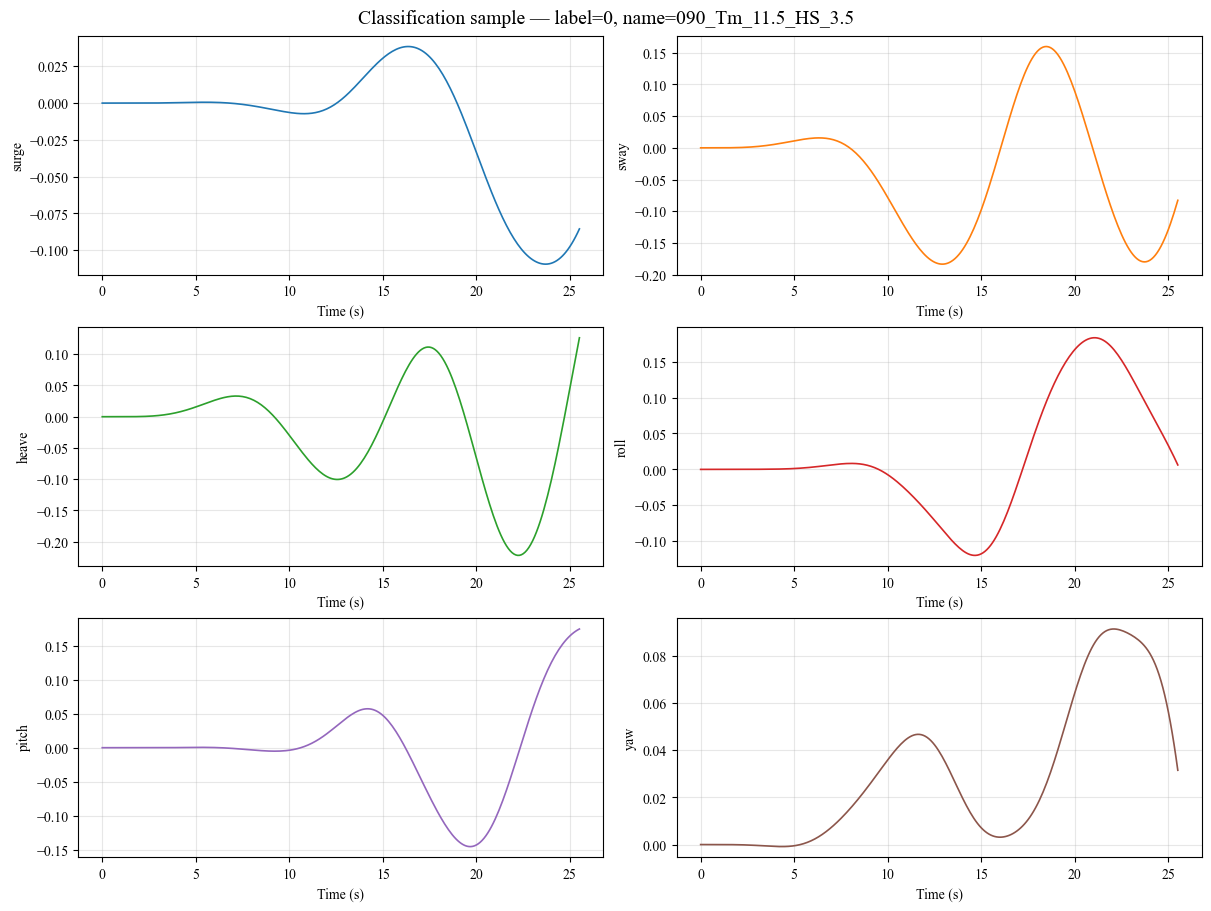

In [ ]:
import json
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# 폰트 설정: Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

save_dir = Path("prepared_datasets")
meta_path = save_dir / "dataset_meta.json"
map_path  = save_dir / "labels_map.json"

# y 파일명 호환 처리(오탈자 대비: classification_Y.pt 표기 수용)
y_lower = save_dir / "classification_y.pt"
y_upper = save_dir / "classification_Y.pt"
y_path = y_lower if y_lower.exists() else (y_upper if y_upper.exists() else None)

if not (save_dir / "classification_X.pt").exists() or y_path is None:
    raise FileNotFoundError("classification_X.pt 또는 classification_y.pt(또는 classification_Y.pt)를 찾을 수 없습니다.")

# 로드
X_cls = torch.load(save_dir / "classification_X.pt")
y_cls = torch.load(y_path)

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)
with open(map_path, "r", encoding="utf-8") as f:
    labels_map = json.load(f)

# 역매핑: 라벨 -> 원래 베이스 이름
inv_map = {v: k for k, v in labels_map.items()}

N, seq_len, C = X_cls.shape
print(f"분류용 학습 샘플 개수: {N}개, 시퀀스 길이: {seq_len}, 채널 수: {C}")

# 시각화할 인덱스 선택(예: 0번)
idx = 0 if N > 0 else None
if idx is None:
    raise RuntimeError("시각화할 샘플이 없습니다.")

x = X_cls[idx].numpy()  # (seq, 6)
label_val = int(y_cls[idx])
base_name = inv_map.get(label_val, f"label_{label_val}")

# 시간축(초)
dt = float(meta.get("dt", 0.1))
t = np.arange(seq_len) * dt

# 컬러 팔레트(6개 서로 다른 색)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
names = meta.get("channels_classification", ["surge","sway","heave","roll","pitch","yaw"])

fig, axes = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for i in range(6):
    axes[i].plot(t, x[:, i], color=colors[i], linewidth=1.2)
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel(names[i])
    axes[i].grid(True, alpha=0.3)

title_text = f"Classification sample — label={label_val}, name={base_name}"
fig.suptitle(title_text, fontsize=14)
plt.show()

## 1.3. Check RNN datasets

예측용 학습 샘플 개수: 1755개, 입력 길이: 512, 출력 길이: 256


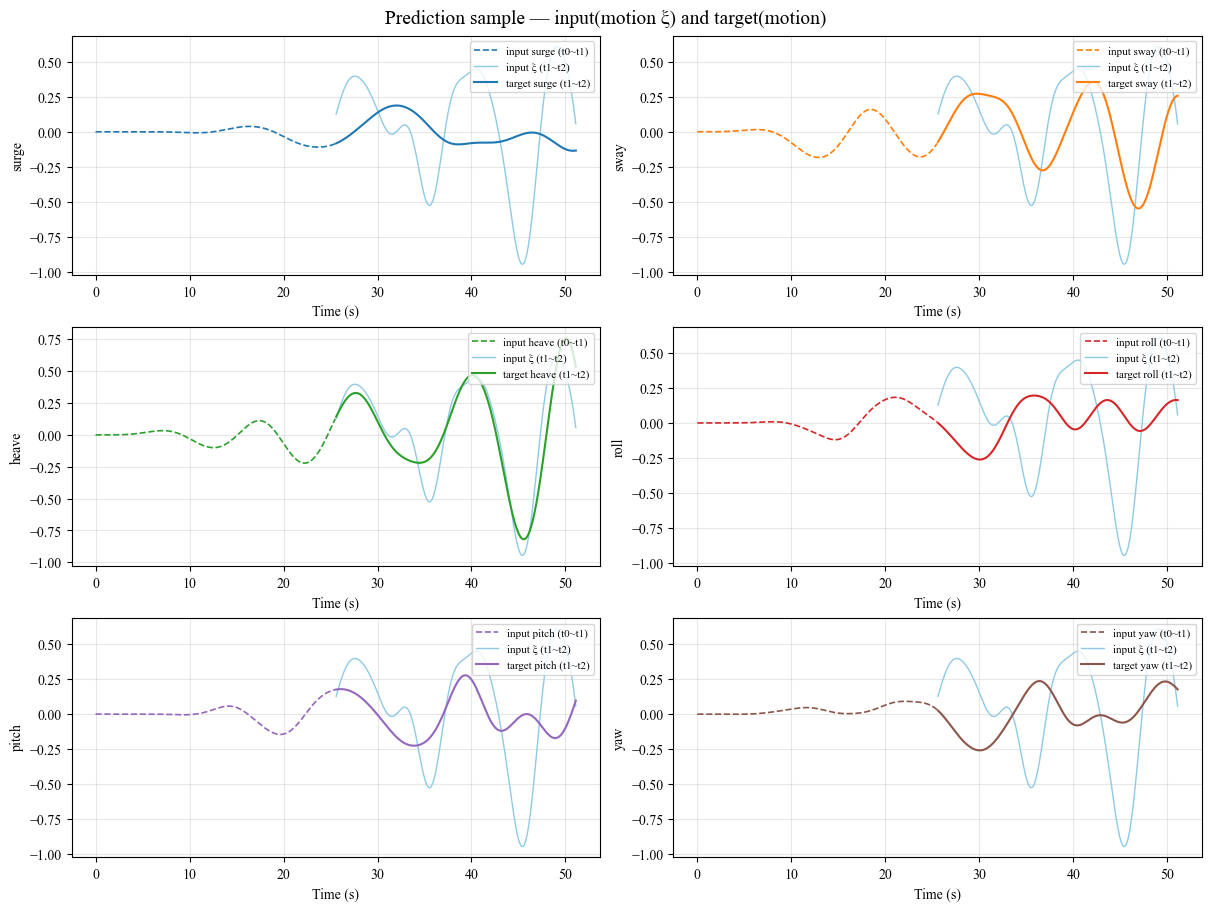

In [3]:
# 셀 3

import json
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

# 폰트 설정: Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

save_dir = Path("prepared_datasets")
meta_path = save_dir / "dataset_meta.json"

X_pred = torch.load(save_dir / "prediction_X.pt")   # (N, 2*seq, 7) [0..5: 운동, 6: ξ]
Y_pred = torch.load(save_dir / "prediction_y.pt")   # (N, seq, 6)

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

N, L2, Cin = X_pred.shape
seq_len = meta.get("sequence_length", 256)
dt = float(meta.get("dt", 0.1))
names_dof = meta.get("channels_prediction_target", ["surge","sway","heave","roll","pitch","yaw"])

print(f"예측용 학습 샘플 개수: {N}개, 입력 길이: {L2}, 출력 길이: {Y_pred.shape[1]}")

# 시각화할 인덱스 선택(예: 0번)
idx = 0 if N > 0 else None
if idx is None:
    raise RuntimeError("시각화할 샘플이 없습니다.")

X = X_pred[idx].numpy()    # (2*seq, 7)
Y = Y_pred[idx].numpy()    # (seq, 6)

# 시간축
t1 = np.arange(seq_len) * dt                         # 0.0 ~ 25.5...
t2 = np.arange(seq_len) * dt + seq_len*dt           # 25.6 ~ 51.1...

# 컬러 팔레트(6개 서로 다른 색) — 셀2와 동일
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

# 플롯
fig, axes = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for i in range(6):
    # 운동 입력(첫 절반): 점선
    axes[i].plot(t1, X[0:seq_len, i], linestyle="--", linewidth=1.2, color=colors[i], label=f"input {names_dof[i]} (t0~t1)")
    # 파랑 입력(둘째 절반): 옅은 파란색 실선
    axes[i].plot(t2, X[seq_len:2*seq_len, 6], linestyle="-", linewidth=1.0, color="#8ecae6", label="input ξ (t1~t2)")
    # 타깃 운동(둘째 절반): 실선
    axes[i].plot(t2, Y[:, i], linestyle="-", linewidth=1.5, color=colors[i], label=f"target {names_dof[i]} (t1~t2)")

    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel(names_dof[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc="upper right", fontsize=8, frameon=True)

fig.suptitle("Prediction sample — input(motion ξ) and target(motion)", fontsize=14)
plt.show()

# 2. Training

## 2.1. Scaling

classification_X 만 스케일링을 합니다. 왜냐하면 운동 시계열 정보를 이용해 파랑 조건 레이블을 학습하기 때문에, 파랑 정보는 별도로 스케일링을 할 필요가 없습니다. 

classification과 prediction 데이터셋 모두에 대해 Min-Max scaling을 적용하고, 각각의 스케일러를 scaler 폴더에 저장하는 전체 코드입니다.
  - classification: motion_scaler.pkl
  - prediction: motion_scaler_pred.pkl, wave_scaler_pred.pkl

으로 분리하여 저장합니다.

In [16]:
# 셀 A: 데이터 스케일링 (classification + prediction, DOF별 scaler 적용)

import torch
import numpy as np
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# 경로 설정
data_dir = Path("prepared_datasets")
scaler_dir = Path("scaler")
scaler_dir.mkdir(exist_ok=True)


def scale_classification(X_path, y_path, scaler_dir):
    """
    classification_X.pt, classification_y.pt 불러와서
    입력(X: 운동 6자유도)을 DOF별 Min-Max scaling 후 다시 저장.
    """
    X = torch.load(X_path)   # (N, seq, 6)
    y = torch.load(y_path)   # (N,)

    N, seq, C = X.shape
    X_np = X.numpy()  # (N, seq, 6)

    scalers = {}
    X_scaled = np.zeros_like(X_np, dtype=np.float32)

    for i, dof in enumerate(["surge","sway","heave","roll","pitch","yaw"]):
        scaler = MinMaxScaler()
        data_flat = X_np[:, :, i].reshape(-1, 1)   # (N*seq, 1)
        scaled_flat = scaler.fit_transform(data_flat)
        X_scaled[:, :, i] = scaled_flat.reshape(N, seq)
        scalers[dof] = scaler
        joblib.dump(scaler, scaler_dir / f"classification_scaler_{dof}.pkl")

    # 저장
    torch.save(torch.from_numpy(X_scaled), X_path)
    torch.save(y, y_path)

    print(f"[Classification] DOF별 scaler 저장 완료 (scaler/classification_scaler_*.pkl)")


def scale_prediction(X_path, y_path, scaler_dir):
    """
    prediction_X.pt, prediction_y.pt 불러와서
    - 운동 데이터(6자유도): DOF별 Min-Max scaling
    - 파랑 데이터(ξ): Min-Max scaling (별도 스케일러)
    """
    X = torch.load(X_path)   # (N, 512, 7) = [past_motion(256,6); future_wave(256,1)]
    Y = torch.load(y_path)   # (N, 256, 6) = future motion

    N, seq_in, C_in = X.shape   # (N, 512, 7)
    N, seq_out, C_out = Y.shape # (N, 256, 6)

    X_np = X.numpy()
    Y_np = Y.numpy()

    scalers_motion = {}
    X_scaled = np.zeros_like(X_np, dtype=np.float32)
    Y_scaled = np.zeros_like(Y_np, dtype=np.float32)

    # --- Motion DOF별 스케일링 ---
    for i, dof in enumerate(["surge","sway","heave","roll","pitch","yaw"]):
        scaler = MinMaxScaler()
        # past_motion + future_motion 전체를 fit 대상으로 사용
        data_flat = np.concatenate([
            X_np[:, :256, i].reshape(-1, 1),
            Y_np[:, :, i].reshape(-1, 1)
        ], axis=0)
        scaler.fit(data_flat)

        # transform 적용
        X_scaled[:, :256, i] = scaler.transform(X_np[:, :256, i].reshape(-1, 1)).reshape(N, 256)
        Y_scaled[:, :, i]   = scaler.transform(Y_np[:, :, i].reshape(-1, 1)).reshape(N, 256)

        scalers_motion[dof] = scaler
        joblib.dump(scaler, scaler_dir / f"prediction_scaler_{dof}.pkl")

    # --- Wave 스케일링 ---
    wave_scaler = MinMaxScaler()
    wave_flat = X_np[:, 256:, 6].reshape(-1, 1)
    wave_scaler.fit(wave_flat)
    X_scaled[:, 256:, 6] = wave_scaler.transform(wave_flat).reshape(N, 256)

    joblib.dump(wave_scaler, scaler_dir / "prediction_scaler_wave.pkl")

    # 저장
    torch.save(torch.from_numpy(X_scaled), X_path)
    torch.save(torch.from_numpy(Y_scaled), y_path)

    print(f"[Prediction] DOF별 scaler 및 wave scaler 저장 완료")


# 실행 예시
scale_classification(
    data_dir / "classification_X.pt",
    data_dir / "classification_y.pt",
    scaler_dir
)

scale_prediction(
    data_dir / "prediction_X.pt",
    data_dir / "prediction_y.pt",
    scaler_dir
)

[Classification] DOF별 scaler 저장 완료 (scaler/classification_scaler_*.pkl)
[Prediction] DOF별 scaler 및 wave scaler 저장 완료


## 2.2. Time-CNN Model

In [17]:
# 셀 B: Time-CNN 학습 (stride 조정 + epoch 100 + early stopping + GPU(1) 사용)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
from pathlib import Path
import json

# 경로
data_dir = Path("prepared_datasets")
model_dir = Path("saved_models")
model_dir.mkdir(exist_ok=True)

# GPU 설정 (GPU:1 사용)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 데이터 불러오기
X = torch.load(data_dir / "classification_X.pt")   # (N, seq, 6)
y = torch.load(data_dir / "classification_y.pt")   # (N,)
N, seq_len, C = X.shape
num_classes = len(torch.unique(y))

# stride는 dataset 생성 과정에서 조정된 값이 반영됨
meta_path = data_dir / "dataset_meta.json"
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

stride_used = meta.get("stride_cls", 64)  # 기본값 64

# Dataset 분할 (train/val)
dataset = TensorDataset(X, y)
val_ratio = 0.2
n_val = int(len(dataset) * val_ratio)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

# Time-CNN 모델 정의
class TimeCNN(nn.Module):
    def __init__(self, input_channels=6, num_classes=10):
        super(TimeCNN, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):  # x: (batch, seq, channels)
        x = x.permute(0, 2, 1)  # (B, C, seq)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)  # (B, 128)
        x = self.dropout(x)
        out = self.fc(x)
        return out

# 초기화
model = TimeCNN(input_channels=C, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Early Stopping 설정
epochs = 100
patience = 10
best_val_loss = np.inf
patience_counter = 0

model_name = f"timecnn_v1_stride{stride_used}_ep{epochs}.pth"
model_path = model_dir / model_name

# 학습 루프
for epoch in range(1, epochs+1):
    # Train
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()
            pred = outputs.argmax(dim=1)
            correct += (pred == yb).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / len(val_ds)

    print(f"Epoch {epoch:03d}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping 체크
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        print(f"  → 모델 개선됨, 저장: {model_path}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping 발동!")
            break

print("학습 종료")

사용 디바이스: cuda:1
Epoch 001/100 | Train Loss: 1.5664 | Val Loss: 1.3002 | Val Acc: 0.6097
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 002/100 | Train Loss: 0.9845 | Val Loss: 0.8305 | Val Acc: 0.6496
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 003/100 | Train Loss: 0.8440 | Val Loss: 0.7112 | Val Acc: 0.7222
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 004/100 | Train Loss: 0.7489 | Val Loss: 0.6235 | Val Acc: 0.7507
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 005/100 | Train Loss: 0.6736 | Val Loss: 0.6102 | Val Acc: 0.7293
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 006/100 | Train Loss: 0.6473 | Val Loss: 0.5933 | Val Acc: 0.7450
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 007/100 | Train Loss: 0.6089 | Val Loss: 0.5576 | Val Acc: 0.7806
  → 모델 개선됨, 저장: saved_models/timecnn_v1_stride256_ep100.pth
Epoch 008/100 | Train Loss: 0.5769 | Val Loss: 0.5288 | Val 

## 2.3. Load model and prediction

사용 디바이스: cuda:1
모델 불러오기 완료: saved_models/timecnn_v1_stride256_ep100.pth
10개 중 맞춘 개수: 10/10


/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE 

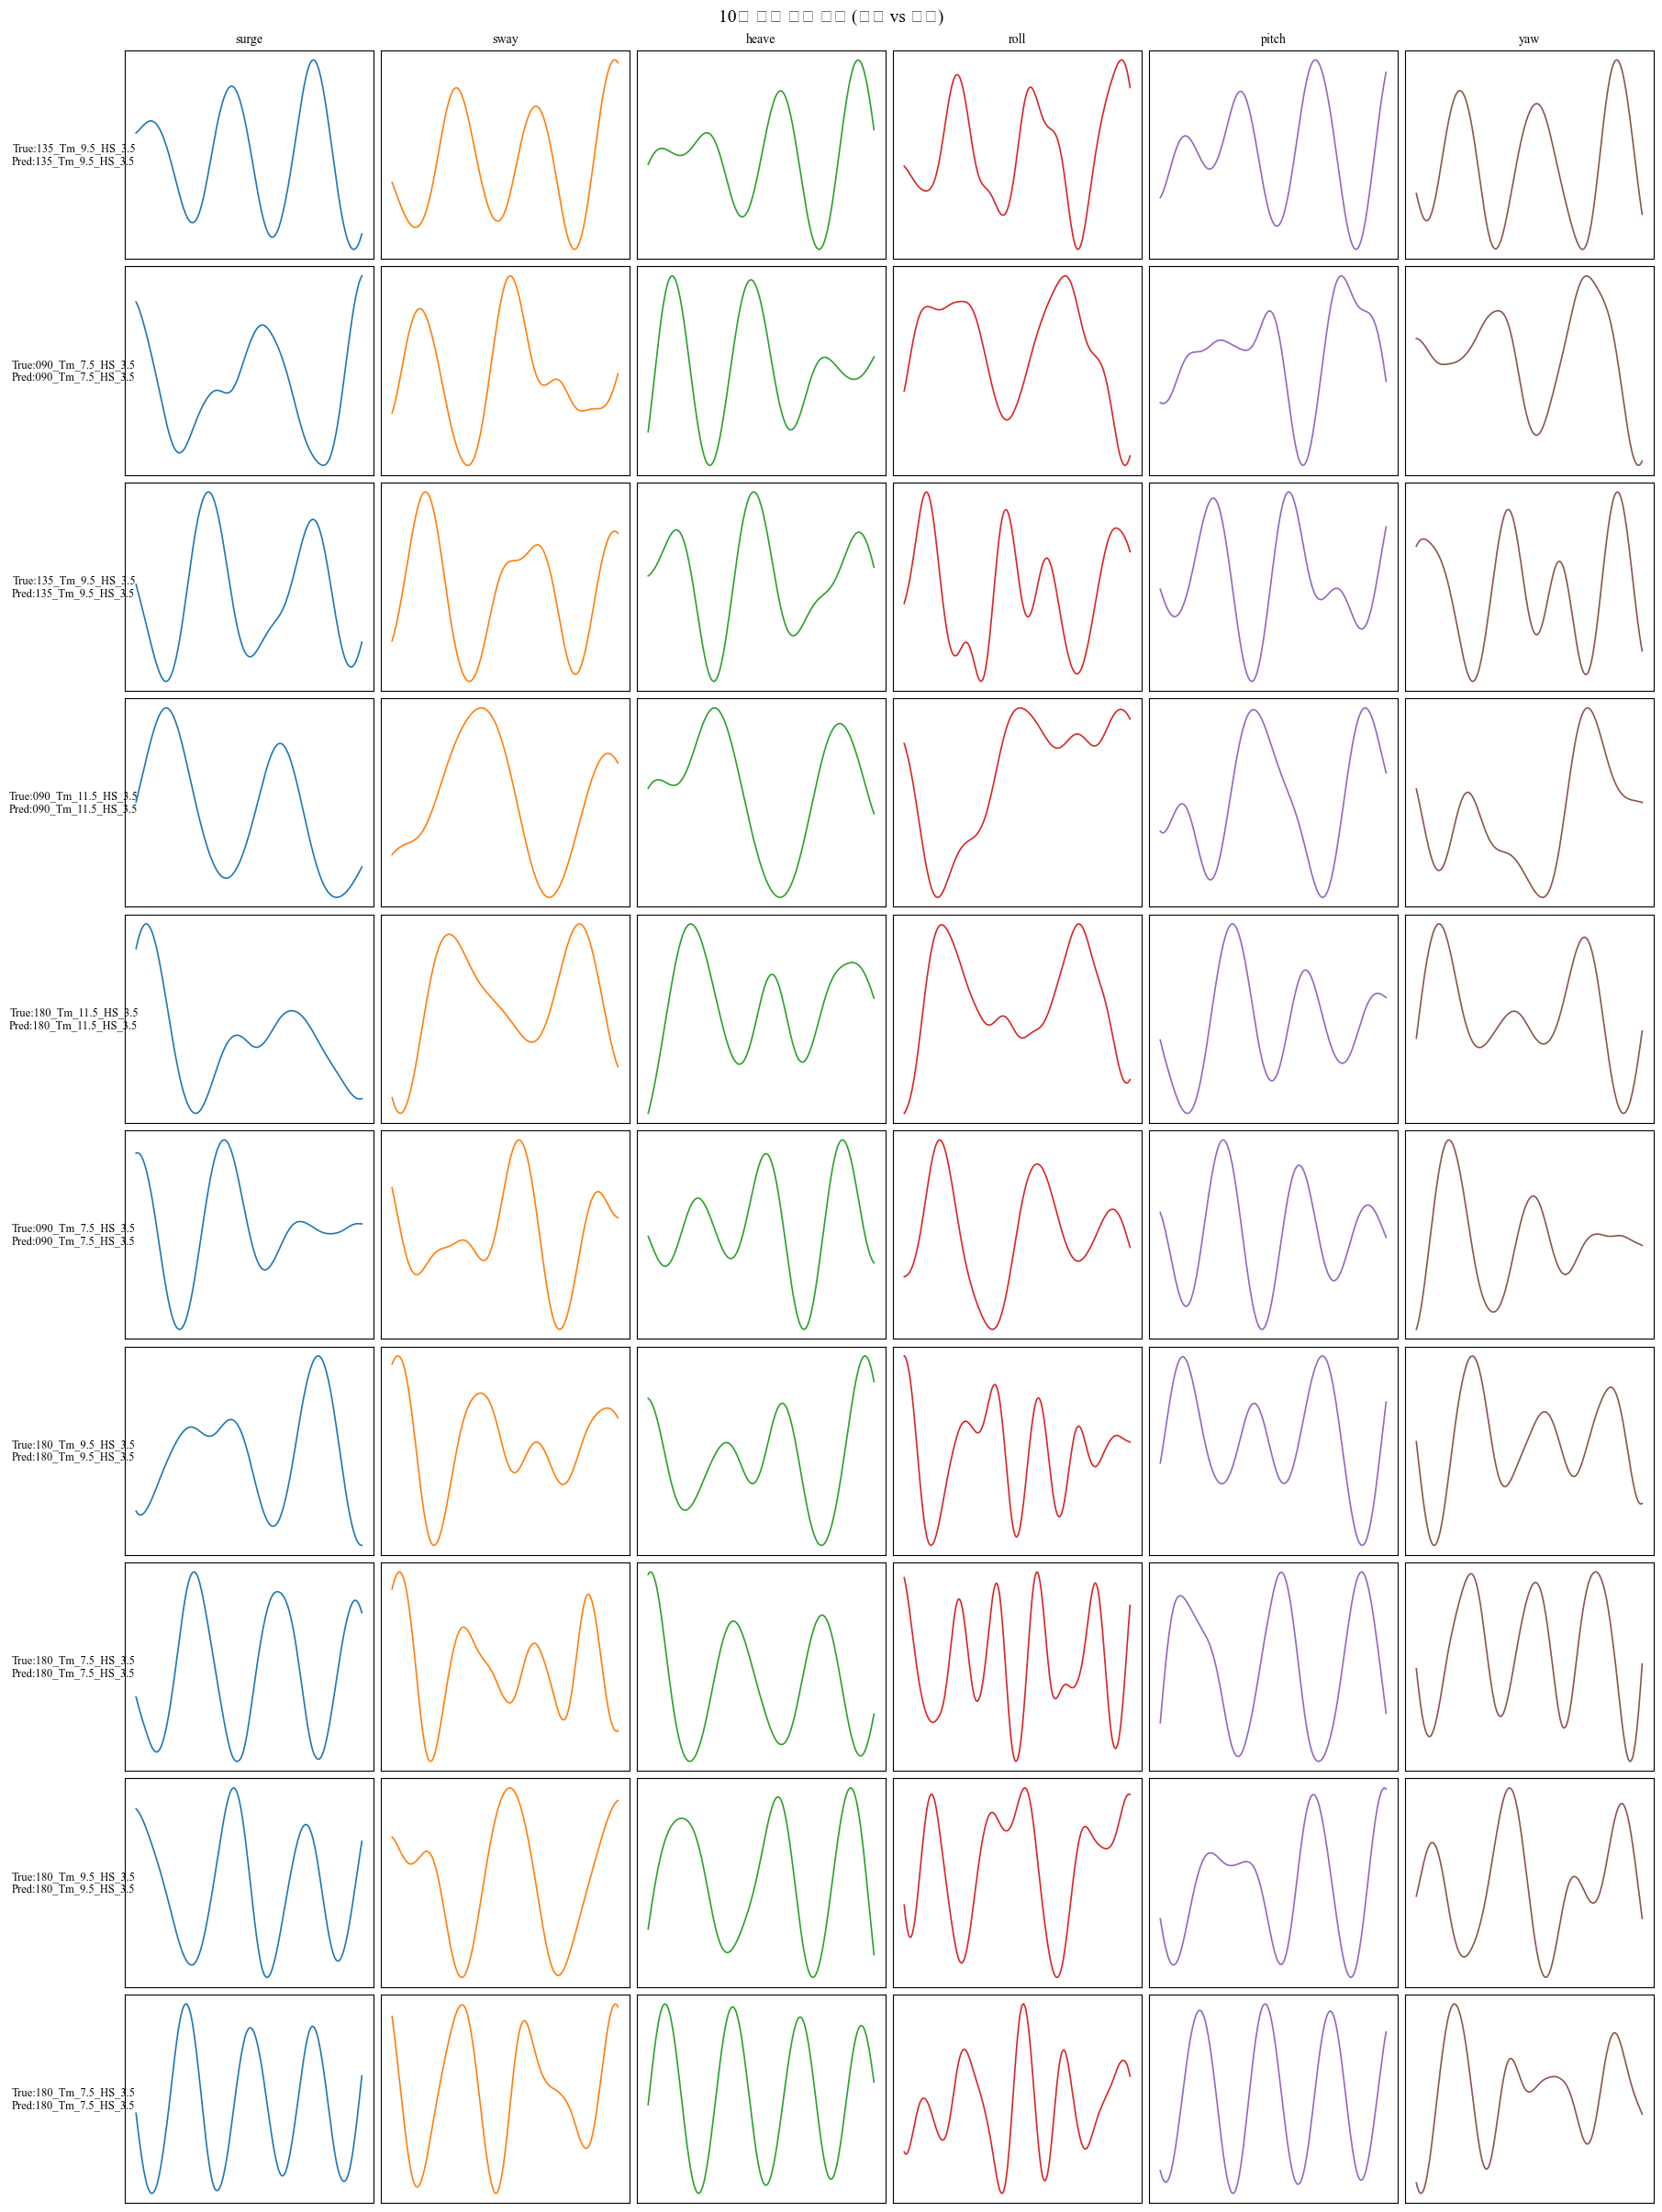

In [18]:
# 셀 D: 저장된 모델 불러오기 & 임의 10개 샘플 예측 및 시각화

import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import json
from pathlib import Path

# Times New Roman 폰트
plt.rcParams["font.family"] = "Times New Roman"

# 경로
data_dir = Path("prepared_datasets")
model_dir = Path("saved_models")
scaler_dir = Path("scaler")

# dataset_meta.json 불러오기
with open(data_dir / "dataset_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

# 라벨 매핑 로드
with open(data_dir / "labels_map.json", "r", encoding="utf-8") as f:
    labels_map = json.load(f)
inv_map = {v: k for k, v in labels_map.items()}

# 데이터 불러오기
X = torch.load(data_dir / "classification_X.pt")   # (N, seq, 6)
y = torch.load(data_dir / "classification_y.pt")   # (N,)
N, seq_len, C = X.shape
num_classes = len(torch.unique(y))
dt = float(meta.get("dt", 0.1))

# 모델 정의 (학습 시와 동일해야 함)
class TimeCNN(torch.nn.Module):
    def __init__(self, input_channels=6, num_classes=10):
        super(TimeCNN, self).__init__()
        self.conv1 = torch.nn.Conv1d(input_channels, 64, kernel_size=5, padding=2)
        self.bn1 = torch.nn.BatchNorm1d(64)
        self.conv2 = torch.nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = torch.nn.BatchNorm1d(128)
        self.pool = torch.nn.AdaptiveMaxPool1d(1)
        self.dropout = torch.nn.Dropout(0.3)
        self.fc = torch.nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, C, seq)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)  # (B, 128)
        x = self.dropout(x)
        out = self.fc(x)
        return out

# GPU 설정 (GPU:1 사용)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 저장된 모델 불러오기
model_name = f"timecnn_v1_stride{meta.get('stride_cls', 64)}_ep100.pth"
model_path = model_dir / model_name

model = TimeCNN(input_channels=C, num_classes=num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"모델 불러오기 완료: {model_path}")

# 무작위 샘플 10개 선택
sample_indices = random.sample(range(N), 10)

correct = 0
pred_labels, true_labels = [], []

for idx in sample_indices:
    sample = X[idx].unsqueeze(0).to(device)   # (1, seq, 6)
    true_label = int(y[idx].item())
    with torch.no_grad():
        outputs = model(sample)
        pred_label = torch.argmax(outputs, dim=1).item()
    pred_labels.append(pred_label)
    true_labels.append(true_label)
    if pred_label == true_label:
        correct += 1

print(f"10개 중 맞춘 개수: {correct}/10")

# 시각화
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
names = meta.get("channels_classification", ["surge","sway","heave","roll","pitch","yaw"])
t = np.arange(seq_len) * dt

fig, axes = plt.subplots(10, 6, figsize=(18, 24), constrained_layout=True)

for row, idx in enumerate(sample_indices):
    x = X[idx].numpy()
    for i in range(6):
        ax = axes[row, i]
        ax.plot(t, x[:, i], color=colors[i], linewidth=1.2)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(names[i], fontsize=10)
    true_name = inv_map.get(true_labels[row], f"label_{true_labels[row]}")
    pred_name = inv_map.get(pred_labels[row], f"label_{pred_labels[row]}")
    axes[row, 0].set_ylabel(f"True:{true_name}\nPred:{pred_name}",
                            fontsize=9, rotation=0, labelpad=40, va="center")

plt.suptitle("10개 샘플 예측 결과 (정답 vs 예측)", fontsize=14)
plt.show()

## 2.4. Bi-LSTM model

In [29]:
# 셀 E: Bi-LSTM Seq2Seq (autoregressive with future wave) 학습 및 저장

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
from pathlib import Path

# -----------------------------
# 경로 및 장치 설정
# -----------------------------
data_dir = Path("prepared_datasets")
model_dir = Path("saved_models")
model_dir.mkdir(exist_ok=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -----------------------------
# 데이터 불러오기
# -----------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N, 512, 7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N, 256, 6)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print("데이터셋 크기:", X.shape, Y.shape)

# future wave 추출 (입력 뒤쪽 256 step, 7번째 채널)
future_wave = X[:, 256:, 6].unsqueeze(-1)   # (N, 256, 1)

# Dataset/Dataloader
dataset = TensorDataset(X, future_wave, Y)
val_ratio = 0.2
n_val = int(len(dataset) * val_ratio)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# -----------------------------
# Bi-LSTM Seq2Seq 정의
# -----------------------------
class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=256, output_dim=6, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        # decoder 입력: motion(6) + wave(1)
        self.decoder = nn.LSTM(output_dim+1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.5):
        # x: (B, 512, 7), future_wave: (B, 256, 1), target: (B, 256, 6)
        _, (hidden, cell) = self.encoder(x)

        # 양방향 hidden/cell 합치기
        h_fwd = hidden[0:hidden.size(0):2]
        h_bwd = hidden[1:hidden.size(0):2]
        h_cat = torch.cat((h_fwd, h_bwd), dim=2)
        c_fwd = cell[0:cell.size(0):2]
        c_bwd = cell[1:cell.size(0):2]
        c_cat = torch.cat((c_fwd, c_bwd), dim=2)

        h, c = h_cat, c_cat

        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features).to(x.device)
        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]   # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)  # (B,1,6)
            outputs.append(pred)

            # teacher forcing
            if (target is not None) and (torch.rand(1).item() < teacher_forcing_ratio):
                decoder_input_motion = target[:, t:t+1, :]
            else:
                decoder_input_motion = pred

        return torch.cat(outputs, dim=1)  # (B, target_len, 6)

# -----------------------------
# 모델 초기화
# -----------------------------
model = BiLSTMSeq2Seq(input_dim=input_dim, hidden_dim=256, output_dim=output_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 학습 설정
# -----------------------------
epochs = 100
patience = 10
best_val_loss = np.inf
patience_counter = 0

model_name = f"bilstm_waveaware_v1_ep{epochs}.pth"
model_path = model_dir / model_name

# -----------------------------
# 학습 루프
# -----------------------------
for epoch in range(1, epochs+1):
    # Train
    model.train()
    total_loss = 0
    for xb, wf, yb in train_loader:
        xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb, wf, target=yb, target_len=seq_out, teacher_forcing_ratio=0.5)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, wf, yb in val_loader:
            xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
            outputs = model(xb, wf, target=None, target_len=seq_out, teacher_forcing_ratio=0.0)
            loss = criterion(outputs, yb)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch:03d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        print(f"  → 모델 개선됨, 저장: {model_path}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping 발동!")
            break

print("학습 종료")

사용 디바이스: cuda:1
데이터셋 크기: torch.Size([1755, 512, 7]) torch.Size([1755, 256, 6])
Epoch 001/100 | Train Loss: 0.188050 | Val Loss: 0.008054
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v1_ep100.pth
Epoch 002/100 | Train Loss: 0.007690 | Val Loss: 0.007231
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v1_ep100.pth


KeyboardInterrupt: 

위의 코드에서 학습이 불가함. 
1. 문제 정의 자체가 매우 어렵습니다
	•	입력: (025.6s) 6DOF 운동 + (25.651.2s) 파랑
	•	출력: (25.6~51.2s) 6DOF 운동

즉 모델은 앞선 운동 → 파랑 → 이후 운동이라는 강한 비선형 동역학 관계를 학습해야 합니다.
단순 Bi-LSTM 구조에선 이걸 캐치하기 어렵습니다.

⸻

2. 개선이 필요한 주요 지점

(A) 입력 구조

현재 decoder는 wave를 단순히 “시간별 추가 피처”로만 받고 있습니다.
→ wave와 motion 사이의 동역학적 coupling을 더 잘 반영하려면,
	•	encoder에서 wave도 함께 인코딩하거나
	•	motion encoder와 wave encoder를 따로 두고 feature fusion 후 decoder에 전달하는 방식이 필요합니다.

(B) Loss 함수
	•	지금은 MSELoss를 그대로 쓰고 있는데, DOF별 분포 차이가 크면 특정 DOF에만 끌려갑니다.
	•	L1Loss 또는 DOF별 가중치를 둔 weighted loss를 시도해보는 게 필요합니다.

(C) 학습률과 최적화
	•	Adam(lr=1e-3)은 LSTM에서 흔히 너무 큽니다.
	•	lr=1e-4 ~ 5e-5 정도로 낮추고, gradient clipping (torch.nn.utils.clip_grad_norm_)을 적용하면 안정화됩니다.

(D) Teacher forcing 전략
	•	현재는 고정 0.5입니다.
	•	실제로는 epoch마다 줄여가야 합니다. (예: epoch 0.5 → 0.2 → 0)
	•	그렇지 않으면 validation (teacher forcing 없음)과 train gap이 심합니다.

(E) 모델 용량
	•	hidden_dim=256, layer=2도 사실 부족할 수 있습니다.
	•	hidden_dim=512 이상, layer=3~4로 늘려야 dynamics mapping이 가능할 수 있습니다.
	•	dropout도 0.3~0.5로 조정하는 게 유리합니다.

즉, 학습이 전혀 안 되는 이유는 구조 오류가 아니라 데이터 난이도에 비해 모델/학습 세팅이 너무 단순하기 때문입니다.
제가 권장드리는 최소 변경은:

criterion = nn.L1Loss()   # MSE 대신 L1
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # 학습률 줄임
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 그라디언트 클리핑 추가
teacher_forcing_ratio = max(0.0, 0.5 * (0.95 ** epoch))

In [30]:
# 셀 E: 개선된 Bi-LSTM Seq2Seq (autoregressive with future wave) 학습 및 저장

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
from pathlib import Path

# -----------------------------
# 경로 및 장치 설정
# -----------------------------
data_dir = Path("prepared_datasets")
model_dir = Path("saved_models")
model_dir.mkdir(exist_ok=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -----------------------------
# 데이터 불러오기
# -----------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N, 512, 7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N, 256, 6)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print("데이터셋 크기:", X.shape, Y.shape)

# future wave 추출 (입력 뒤쪽 256 step, 7번째 채널)
future_wave = X[:, 256:, 6].unsqueeze(-1)   # (N, 256, 1)

# Dataset/Dataloader
dataset = TensorDataset(X, future_wave, Y)
val_ratio = 0.2
n_val = int(len(dataset) * val_ratio)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# -----------------------------
# Bi-LSTM Seq2Seq 정의
# -----------------------------
class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=512, output_dim=6, num_layers=3, dropout=0.3):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        # decoder 입력: motion(6) + wave(1)
        self.decoder = nn.LSTM(output_dim+1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.5):
        # x: (B, 512, 7), future_wave: (B, 256, 1), target: (B, 256, 6)
        _, (hidden, cell) = self.encoder(x)

        # 양방향 hidden/cell 합치기
        h_fwd = hidden[0:hidden.size(0):2]
        h_bwd = hidden[1:hidden.size(0):2]
        h_cat = torch.cat((h_fwd, h_bwd), dim=2)
        c_fwd = cell[0:cell.size(0):2]
        c_bwd = cell[1:cell.size(0):2]
        c_cat = torch.cat((c_fwd, c_bwd), dim=2)

        h, c = h_cat, c_cat

        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features).to(x.device)
        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]   # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)  # (B,1,6)
            outputs.append(pred)

            # teacher forcing
            if (target is not None) and (torch.rand(1).item() < teacher_forcing_ratio):
                decoder_input_motion = target[:, t:t+1, :]
            else:
                decoder_input_motion = pred

        return torch.cat(outputs, dim=1)  # (B, target_len, 6)

# -----------------------------
# 모델 초기화
# -----------------------------
model = BiLSTMSeq2Seq(input_dim=input_dim, hidden_dim=512, output_dim=output_dim).to(device)
criterion = nn.L1Loss()  # MAE
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 학습 설정
# -----------------------------
epochs = 100
patience = 15
best_val_loss = np.inf
patience_counter = 0

model_name = f"bilstm_waveaware_v2_ep{epochs}.pth"
model_path = model_dir / model_name

# -----------------------------
# 학습 루프
# -----------------------------
for epoch in range(1, epochs+1):
    # Teacher forcing 비율 (점차 줄이기)
    teacher_forcing_ratio = max(0.0, 0.5 * (0.95 ** epoch))

    # Train
    model.train()
    total_loss = 0
    for xb, wf, yb in train_loader:
        xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb, wf, target=yb, target_len=seq_out, teacher_forcing_ratio=teacher_forcing_ratio)
        loss = criterion(outputs, yb)
        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, wf, yb in val_loader:
            xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
            outputs = model(xb, wf, target=None, target_len=seq_out, teacher_forcing_ratio=0.0)
            loss = criterion(outputs, yb)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch:03d}/{epochs} | TF={teacher_forcing_ratio:.3f} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        print(f"  → 모델 개선됨, 저장: {model_path}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping 발동!")
            break

print("학습 종료")

사용 디바이스: cuda:1
데이터셋 크기: torch.Size([1755, 512, 7]) torch.Size([1755, 256, 6])
Epoch 001/100 | TF=0.475 | Train Loss: 0.164229 | Val Loss: 0.060444
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 002/100 | TF=0.451 | Train Loss: 0.061105 | Val Loss: 0.059584
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 003/100 | TF=0.429 | Train Loss: 0.060454 | Val Loss: 0.059427
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 004/100 | TF=0.407 | Train Loss: 0.059574 | Val Loss: 0.057778
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 005/100 | TF=0.387 | Train Loss: 0.055564 | Val Loss: 0.054999
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 006/100 | TF=0.368 | Train Loss: 0.051955 | Val Loss: 0.055899
Epoch 007/100 | TF=0.349 | Train Loss: 0.047146 | Val Loss: 0.052062
  → 모델 개선됨, 저장: saved_models/bilstm_waveaware_v2_ep100.pth
Epoch 008/100 | TF=0.332 | Train Loss: 0.045142 | Val Loss: 0.054771
Epoch 009/100 |

KeyboardInterrupt: 

## 2.5. Bi-LSTM results

모델 불러오기 완료: saved_models/bilstm_waveaware_v2_ep100.pth


/tmp/ipykernel_44075/12473398.py:115: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44075/12473398.py:115: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


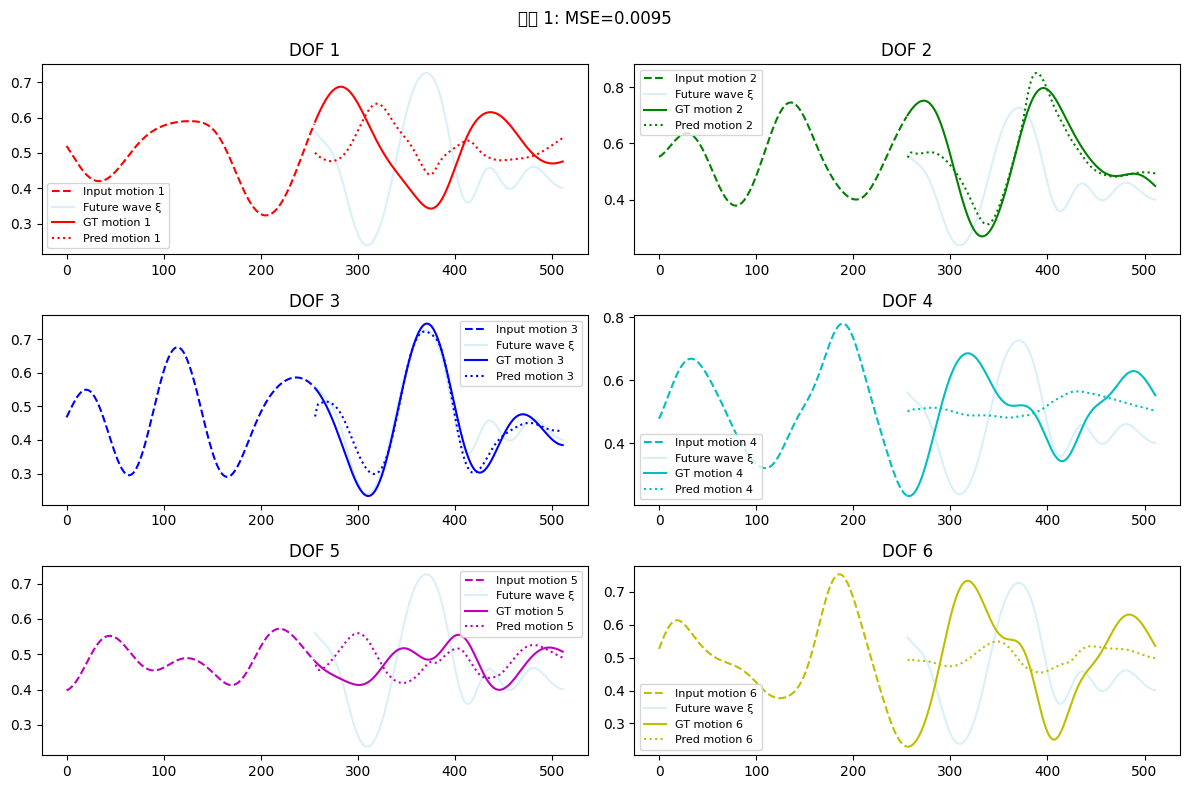

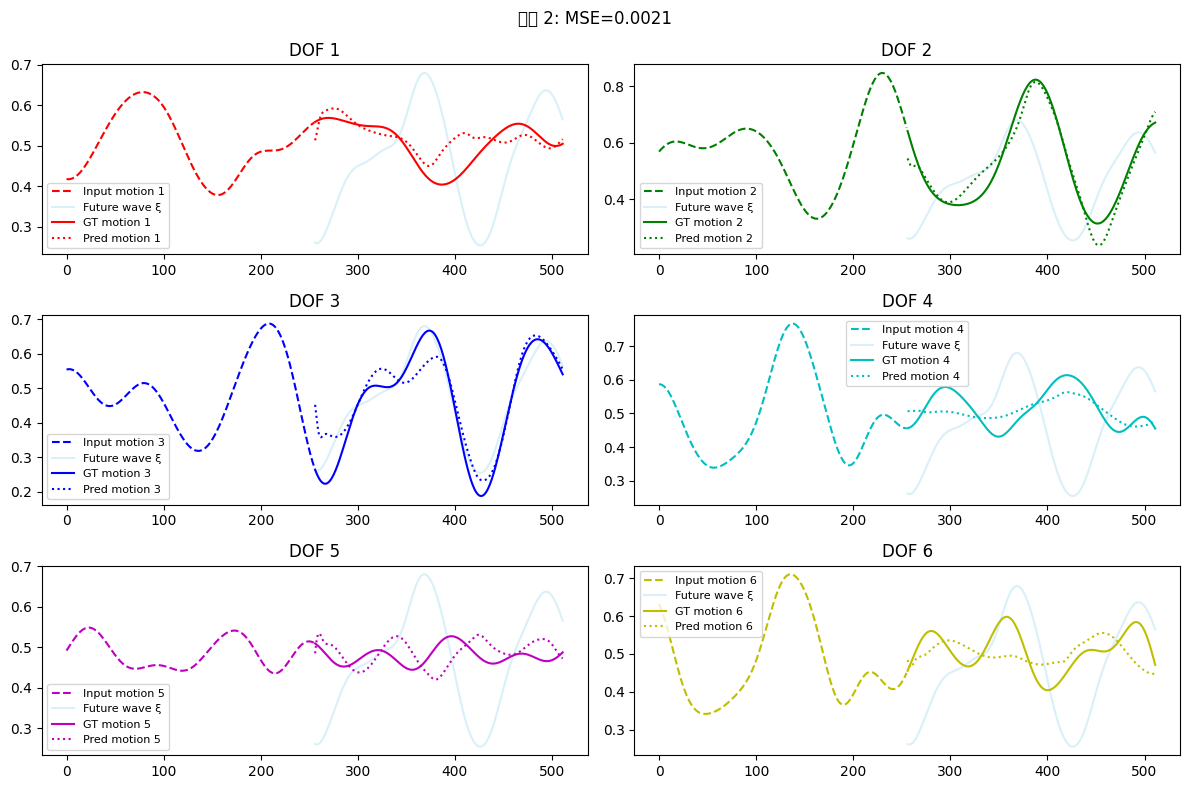

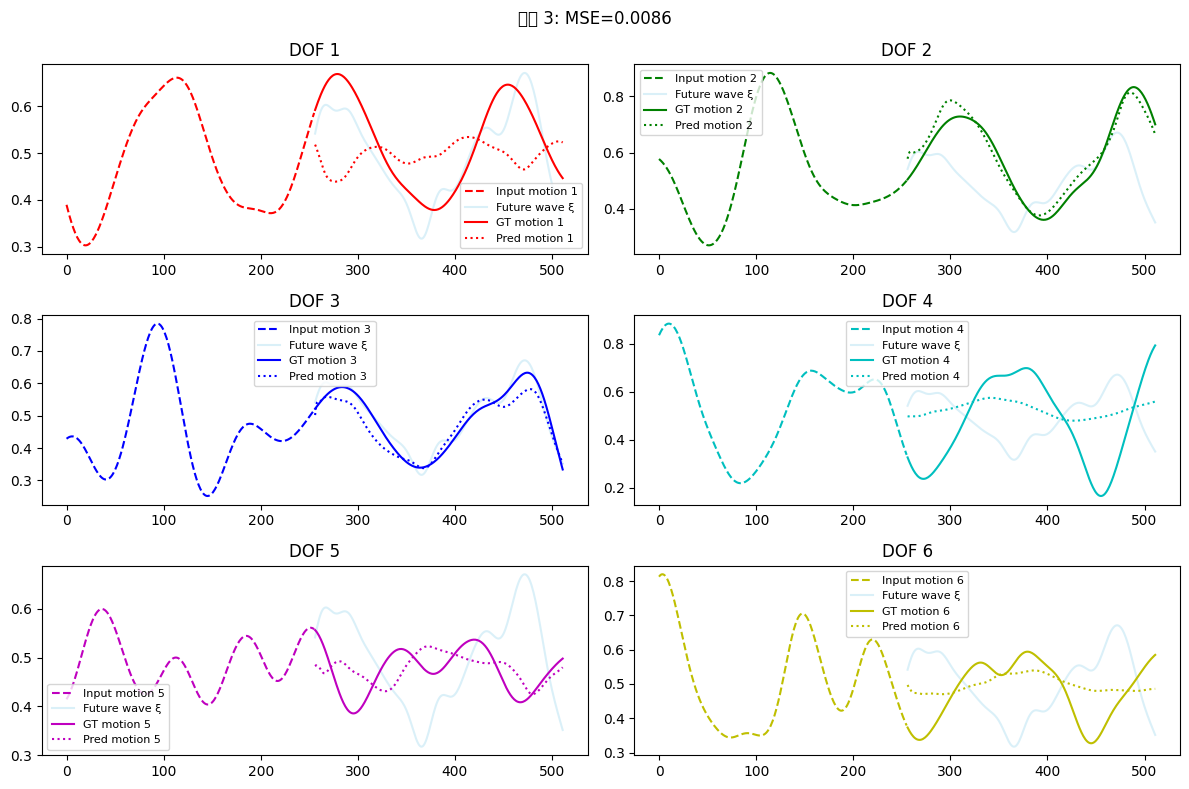

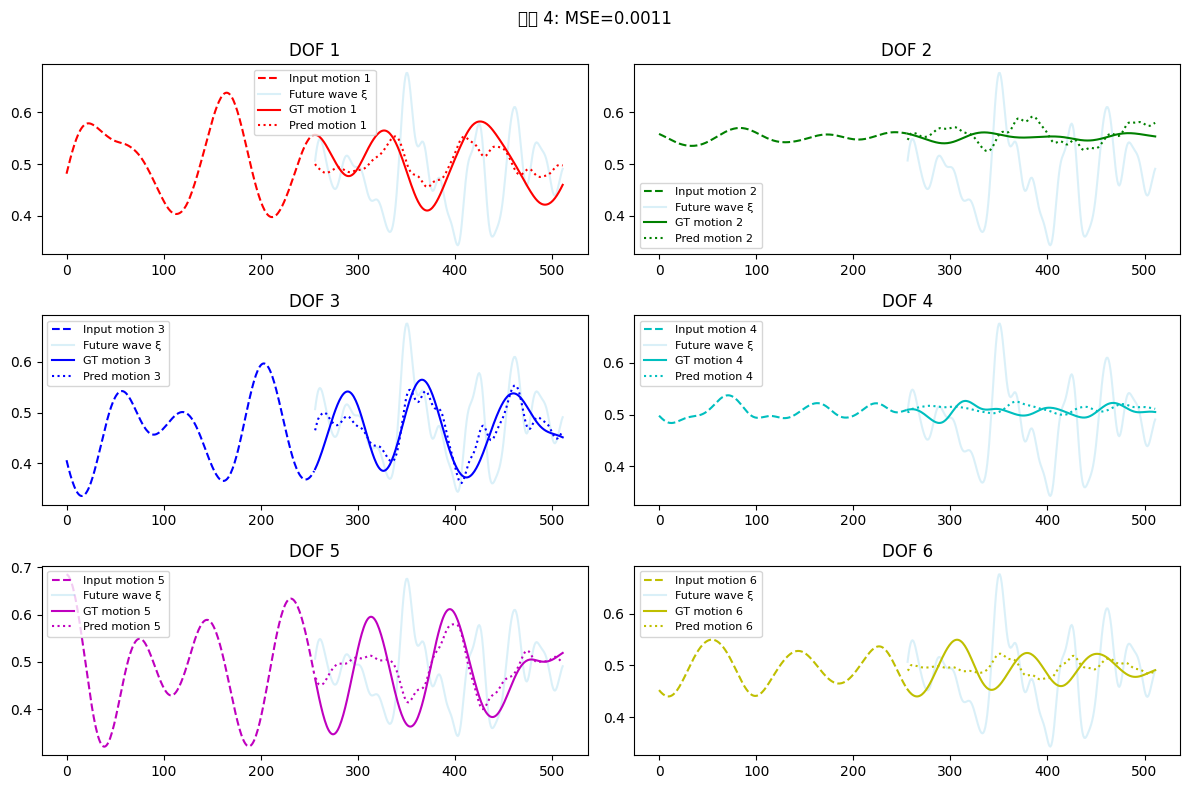

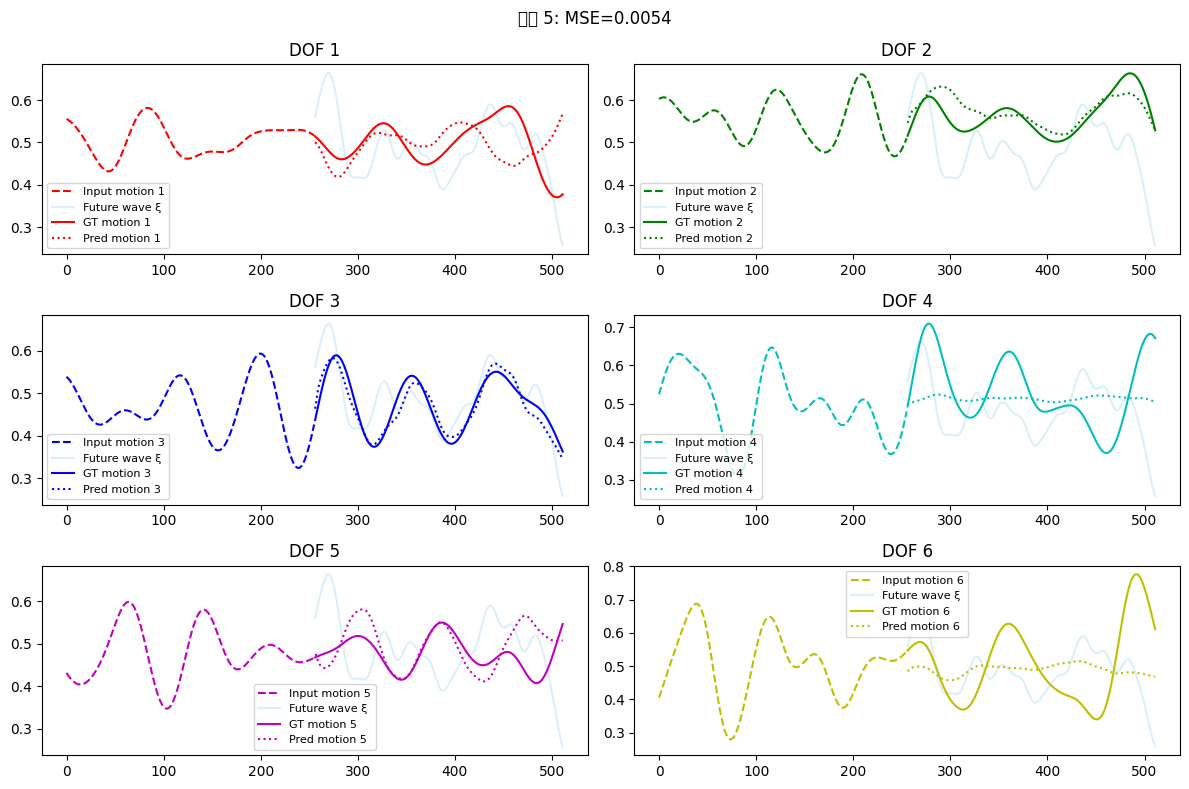

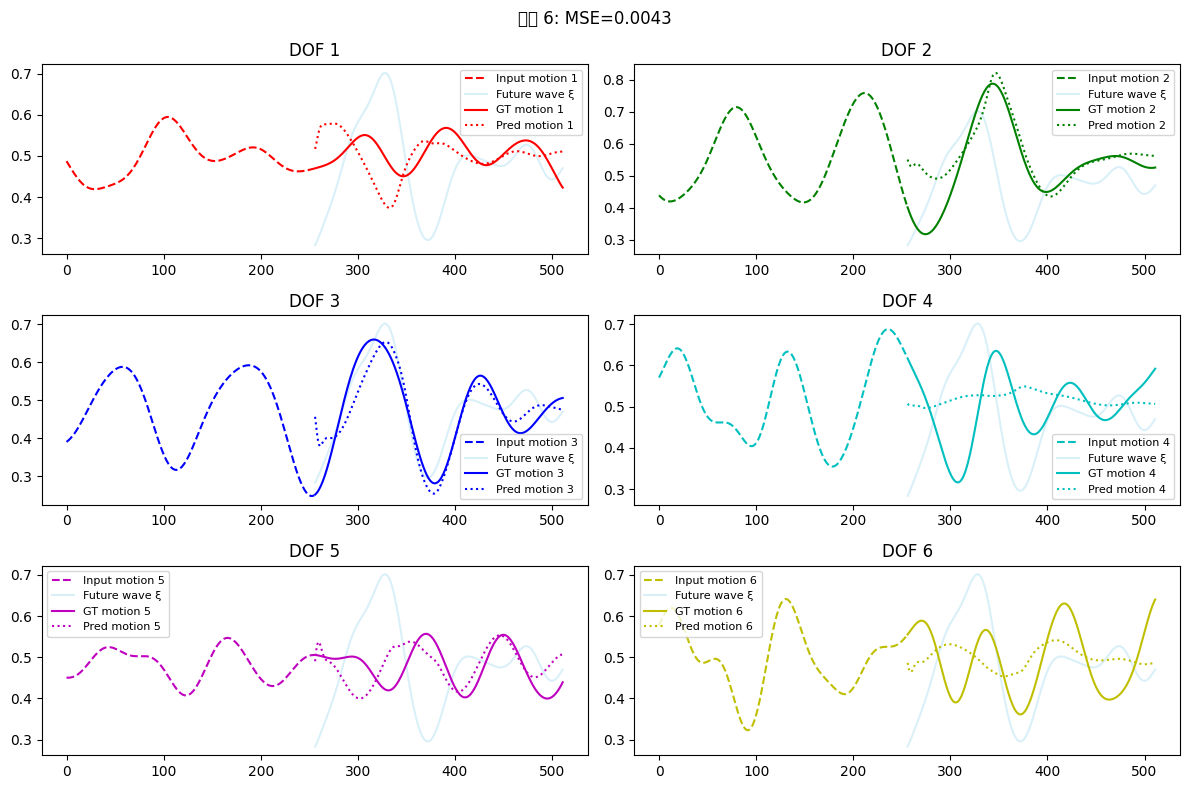

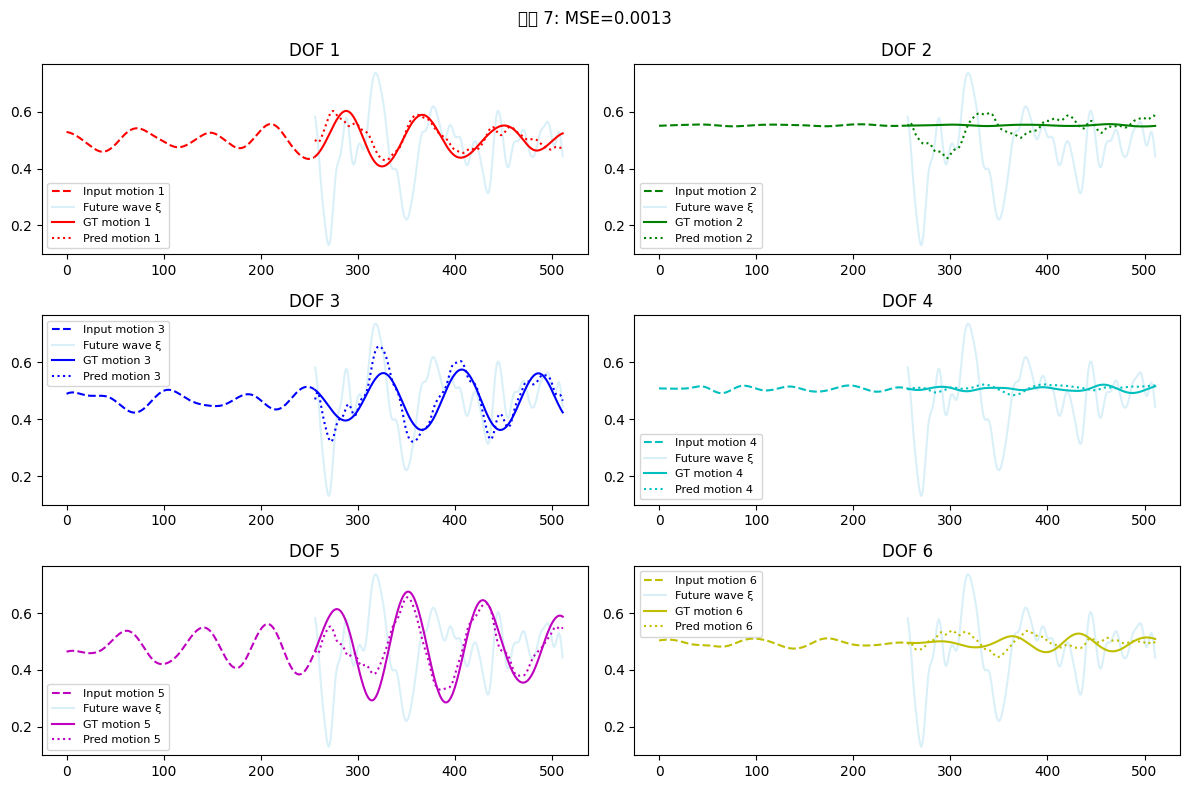

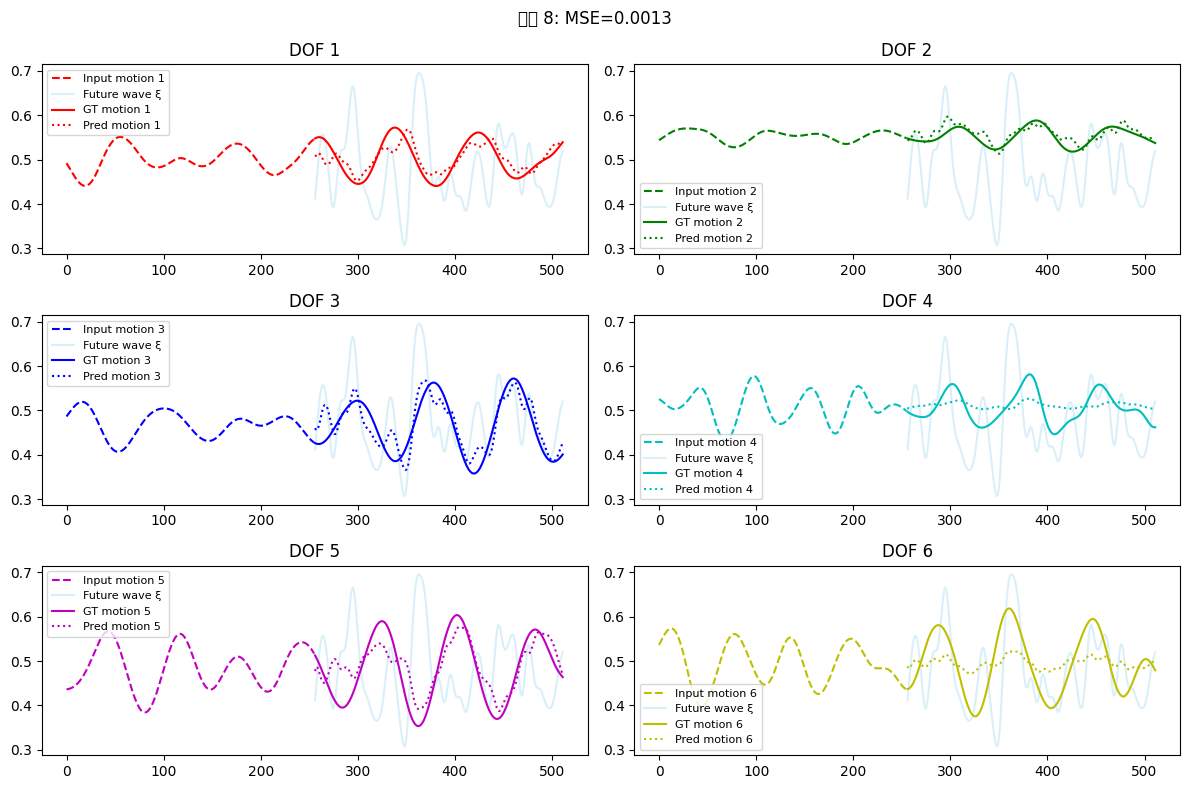

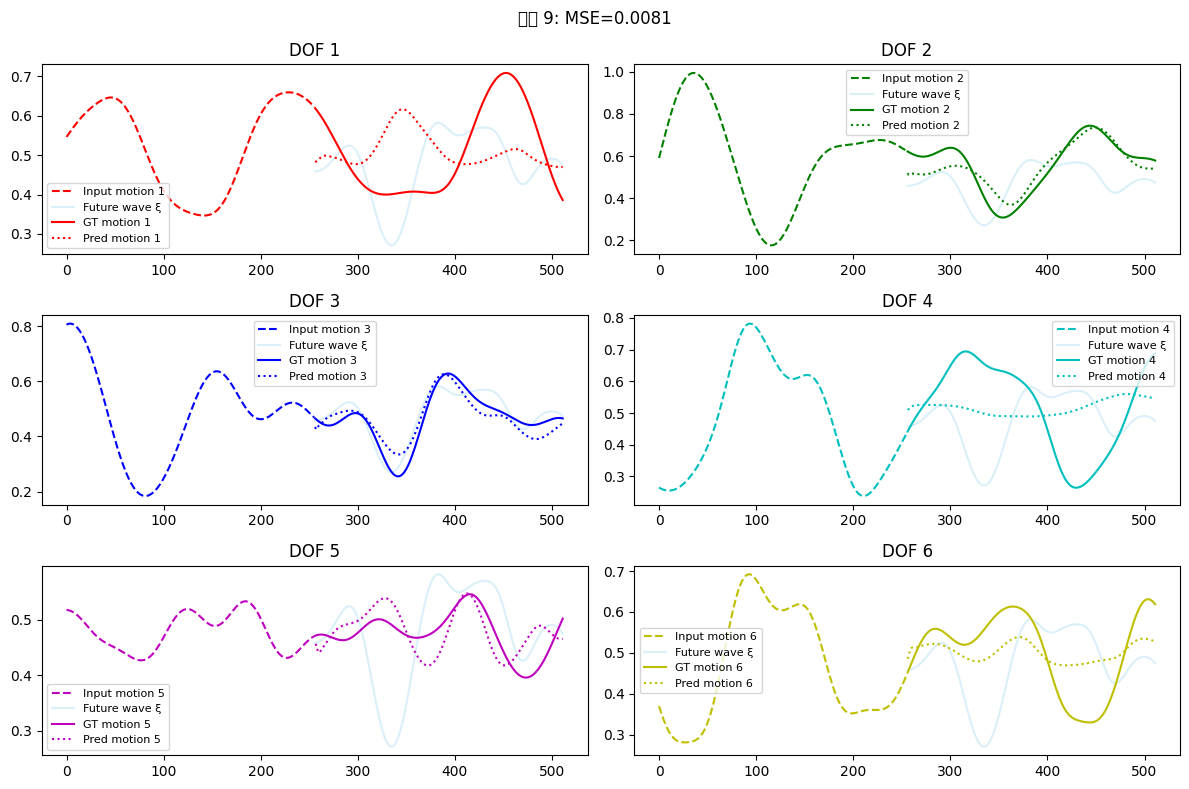

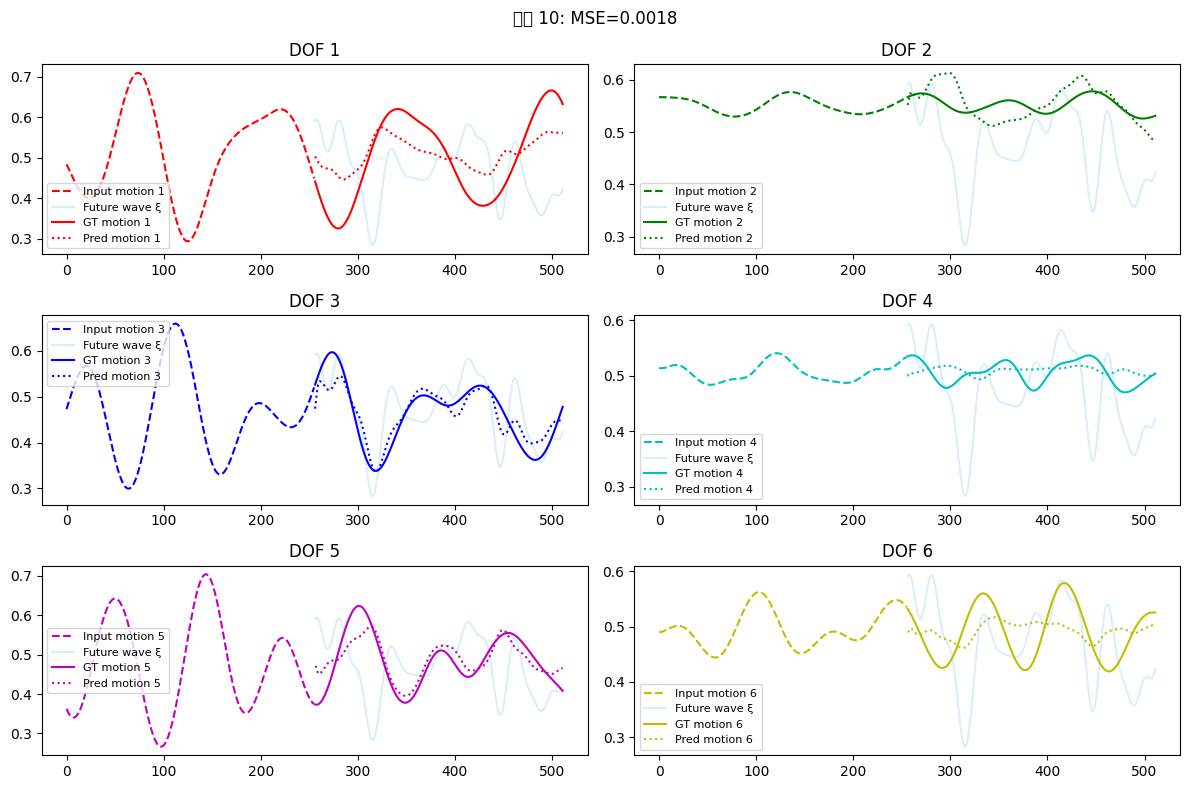

10개 샘플 중 맞춘 개수: 10/10


In [1]:
# 셀 F: 저장된 Bi-LSTM 불러오기 & 임의 10개 샘플 테스트 및 시각화 (wave 모든 subplot에 표시)

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import random

# GPU
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# BiLSTM 모델 구조 (학습 때와 동일)
class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=512, output_dim=6, num_layers=3, dropout=0.3):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        # decoder 입력: motion(6) + wave(1)
        self.decoder = nn.LSTM(output_dim+1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.0):
        _, (hidden, cell) = self.encoder(x)

        # 양방향 hidden/cell 합치기
        h_fwd = hidden[0:hidden.size(0):2]
        h_bwd = hidden[1:hidden.size(0):2]
        h_cat = torch.cat((h_fwd, h_bwd), dim=2)
        c_fwd = cell[0:cell.size(0):2]
        c_bwd = cell[1:cell.size(0):2]
        c_cat = torch.cat((c_fwd, c_bwd), dim=2)

        h, c = h_cat, c_cat

        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features).to(x.device)
        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]   # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)  # (B,1,6)
            outputs.append(pred)
            decoder_input_motion = pred

        return torch.cat(outputs, dim=1)  # (B, target_len, 6)

# 데이터셋 불러오기
X = torch.load("prepared_datasets/prediction_X.pt")   # (N,512,7)
Y = torch.load("prepared_datasets/prediction_y.pt")   # (N,256,6)
future_wave = X[:, 256:, 6].unsqueeze(-1)             # (N,256,1)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape

# 모델 불러오기
model_path = "saved_models/bilstm_waveaware_v2_ep100.pth"
model = BiLSTMSeq2Seq(input_dim=input_dim, hidden_dim=512, output_dim=output_dim).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"모델 불러오기 완료: {model_path}")

# 임의 샘플 10개 선택
indices = random.sample(range(N), 10)
correct_count = 0
threshold = 0.01  # 정확도 판정 기준

colors = ["r", "g", "b", "c", "m", "y"]

for idx, sample_idx in enumerate(indices):
    sample_X = X[sample_idx].unsqueeze(0).to(device)        # (1,512,7)
    sample_wave = future_wave[sample_idx].unsqueeze(0).to(device)  # (1,256,1)
    gt_Y = Y[sample_idx].unsqueeze(0).to(device)            # (1,256,6)

    with torch.no_grad():
        pred_Y = model(sample_X, sample_wave, target_len=seq_out)

    # 정확도 판정 (MSE 기준)
    mse = torch.mean((gt_Y - pred_Y) ** 2).item()
    if mse < threshold:
        correct_count += 1

    # 시간축
    t_past = np.arange(seq_out)                 # 0~255
    t_future = np.arange(seq_out, 2*seq_out)    # 256~511

    # 시각화
    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    axes = axes.flatten()

    for j in range(output_dim):
        ax = axes[j]

        # past motion
        ax.plot(t_past, sample_X[0, :seq_out, j].cpu().numpy(),
                linestyle="--", color=colors[j], label=f"Input motion {j+1}")

        # future wave (모든 subplot에 흐릿하게 표시)
        ax.plot(t_future, sample_wave[0, :, 0].cpu().numpy(),
                linestyle="-", color="skyblue", alpha=0.3, label="Future wave ξ")

        # target motion
        ax.plot(t_future, gt_Y[0, :, j].cpu().numpy(),
                linestyle="-", color=colors[j], label=f"GT motion {j+1}")

        # predicted motion
        ax.plot(t_future, pred_Y[0, :, j].cpu().numpy(),
                linestyle=":", color=colors[j], label=f"Pred motion {j+1}")

        ax.set_title(f"DOF {j+1}")
        ax.legend(fontsize=8)

    plt.suptitle(f"샘플 {idx+1}: MSE={mse:.4f}")
    plt.tight_layout()
    plt.show()

print(f"10개 샘플 중 맞춘 개수: {correct_count}/10")

## 2.6. Bi-LSTM Optimization

Optuna를 붙여서 Bi-LSTM 하이퍼파라미터를 최적화하는 코드입니다. 
  1.	GPU 0, 1 모두 사용: DataParallel을 적용해서 두 GPU를 동시에 활용합니다.
  2.	Optuna 탐색 기록: 각 trial의 결과(Train/Val Loss, 정확도 등)를 Optuna가 자동으로 DB에 저장합니다.
    - 나중에 study.trials_dataframe()으로 결과를 DataFrame으로 꺼내 비교할 수 있습니다.
	- 또, optuna-dashboard 같은 툴을 쓰면 웹 UI로 성능 비교도 가능합니다.
  3. 실험 기록 별도 저장:
    - 각 trial이 끝날 때마다 결과(예: hidden_dim, num_layers, dropout, val_loss)를 results_optuna.csv에 추가 저장합니다.
    - 가장 좋은 모델은 따로 best_model.pth로 저장합니다.

Nohup을 사용하여 실험합니다. 
  - nohup python -u optuna_experiment_bi-lstm.py > train_bi-lstm.log 2>&1 &
  - tail -f train_bi-lstm.log

In [ ]:
# optuna_experiment_bilstm.py
# Bi-LSTM 기반 Optuna 하이퍼파라미터 탐색 코드 (hidden 전달 방식 개선)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import optuna
import pandas as pd
from pathlib import Path
import time
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0" # 주석처리하면 병렬로 학습
# -------------------------------------------------
# 경로 및 장치 설정
# -------------------------------------------------
data_dir   = Path("prepared_datasets")
model_dir  = Path("saved_models_bi-lstm")
result_dir = Path("optuna_results_bi-lstm")
model_dir.mkdir(exist_ok=True, parents=True)
result_dir.mkdir(exist_ok=True, parents=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -------------------------------------------------
# 데이터 불러오기
# -------------------------------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N, 512, 7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N, 256, 6)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print("데이터셋 크기:", X.shape, Y.shape)

future_wave = X[:, 256:, 6].unsqueeze(-1)      # (N, 256, 1)

dataset   = TensorDataset(X, future_wave, Y)
val_ratio = 0.2
n_val     = int(len(dataset) * val_ratio)
n_train   = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

# -------------------------------------------------
# BiLSTM Seq2Seq 정의 (hidden 전달 방식 개선)
# -------------------------------------------------
class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.decoder = nn.LSTM(
            input_size=output_dim + 1,   # motion(6) + wave(1)
            hidden_size=hidden_dim * 2,  # encoder bi → 2*hidden
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.5):
        # Encoder
        _, (h_n, c_n) = self.encoder(x)

        # bidirectional hidden/cell 결합
        h_fwd = h_n[0::2]
        h_bwd = h_n[1::2]
        c_fwd = c_n[0::2]
        c_bwd = c_n[1::2]

        # (num_layers, B, 2*hidden_dim)
        h_cat = torch.cat((h_fwd, h_bwd), dim=2)
        c_cat = torch.cat((c_fwd, c_bwd), dim=2)

        # decoder 초기 hidden state
        h, c = h_cat, c_cat
        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features, device=x.device)

        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]  # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)                # (B,1,6)
            outputs.append(pred)

            if (target is not None) and (torch.rand(1).item() < teacher_forcing_ratio):
                decoder_input_motion = target[:, t:t+1, :]
            else:
                decoder_input_motion = pred

        return torch.cat(outputs, dim=1)       # (B, target_len, 6)

# -------------------------------------------------
# 학습/검증 루프
# -------------------------------------------------
def train_one_trial(model, optimizer, criterion, epochs=50, teacher_forcing_init=0.5,
                    patience=10, seq_out=256, verbose=False):
    best_val = np.inf
    patience_cnt = 0

    for epoch in range(1, epochs + 1):
        tf_ratio = max(0.0, teacher_forcing_init * (0.95 ** epoch))

        model.train()
        t0 = time.time()
        train_loss = 0.0
        for xb, wf, yb in train_loader:
            xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb, wf, target=yb, target_len=seq_out, teacher_forcing_ratio=tf_ratio)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= max(1, len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, wf, yb in val_loader:
                xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
                out = model(xb, wf, target=None, target_len=seq_out, teacher_forcing_ratio=0.0)
                loss = criterion(out, yb)
                val_loss += loss.item()
        val_loss /= max(1, len(val_loader))
        t1 = time.time()

        if verbose:
            print(f"Epoch {epoch:03d}/{epochs} | TF={tf_ratio:.3f} | "
                  f"Train {train_loss:.6f} | Val {val_loss:.6f} | {t1 - t0:.1f}s")

        if val_loss + 1e-12 < best_val:
            best_val = val_loss
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print("Early stopping 발동")
                break

    return best_val

# -------------------------------------------------
# Optuna Objective
# -------------------------------------------------
def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 1024, log=True)
    num_layers = trial.suggest_int("num_layers", 2, 7)
    dropout    = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.4, 0.5])
    lr         = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    tf_init    = trial.suggest_float("tf_init", 0.3, 0.7)

    net = BiLSTMSeq2Seq(input_dim=input_dim,
                        hidden_dim=hidden_dim,
                        output_dim=output_dim,
                        num_layers=num_layers,
                        dropout=dropout).to(device)
    if torch.cuda.device_count() >= 2:
        net = nn.DataParallel(net, device_ids=[0, 1])

    criterion = nn.L1Loss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    best_val = train_one_trial(
        model=net, optimizer=optimizer, criterion=criterion,
        epochs=50, teacher_forcing_init=tf_init, patience=10,
        seq_out=seq_out, verbose=False
    )

    trial_model_path = model_dir / f"best_model_trial{trial.number}.pth"
    torch.save(net.state_dict(), trial_model_path)

    result_path = result_dir / "results_optuna.csv"
    row = {
        "trial": trial.number,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "tf_init": tf_init,
        "val_loss": best_val,
    }
    df_row = pd.DataFrame([row])
    if result_path.exists():
        df_row.to_csv(result_path, mode="a", header=False, index=False)
    else:
        df_row.to_csv(result_path, index=False)

    return best_val

# -------------------------------------------------
# Optuna 실행
# -------------------------------------------------
if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)

    print("Best trial params:", study.best_trial.params)
    print("Best value:", study.best_value)

    df_all = study.trials_dataframe()
    df_all.to_csv(result_dir / "optuna_summary.csv", index=False)
    print("전체 trial 결과 optuna_summary.csv 저장 완료")

    best_trial_num = study.best_trial.number
    best_trial_path = model_dir / f"best_model_trial{best_trial_num}.pth"
    if not best_trial_path.exists():
        raise FileNotFoundError(f"최적 trial 가중치 파일이 없습니다: {best_trial_path}")

    state = torch.load(best_trial_path, map_location=device)
    torch.save(state, model_dir / "lstm_optuna_best.pth")
    print(f"최적 모델 저장 완료: {model_dir / 'lstm_optuna_best.pth'}")

### 2.6.1 Optimization Summary Plot

===== Top 10 Trials by Validation Loss =====


,trial,hidden_dim,num_layers,dropout,lr,tf_init,val_loss
0,11,512,3,0.3,0.000693,0.414175,0.048433
1,8,512,2,0.4,0.000307,0.353546,0.048609
2,4,512,4,0.2,0.000481,0.457114,0.049371
3,5,512,4,0.5,0.000181,0.550275,0.049511
4,18,512,3,0.3,0.000147,0.341649,0.049544
5,0,128,2,0.4,0.000041,0.642464,0.049612
6,16,256,3,0.5,0.000103,0.366052,0.049825
7,13,512,3,0.3,0.000228,0.360194,0.049944
8,3,128,4,0.1,0.000238,0.433123,0.050231
9,12,512,3,0.4,0.000549,0.379855,0.050338



Best Trial Hyperparameters:
{'trial': 11.0, 'hidden_dim': 512.0, 'num_layers': 3.0, 'dropout': 0.3, 'lr': 0.0006934940475831, 'tf_init': 0.4141750508751738, 'val_loss': 0.0484328733926469}


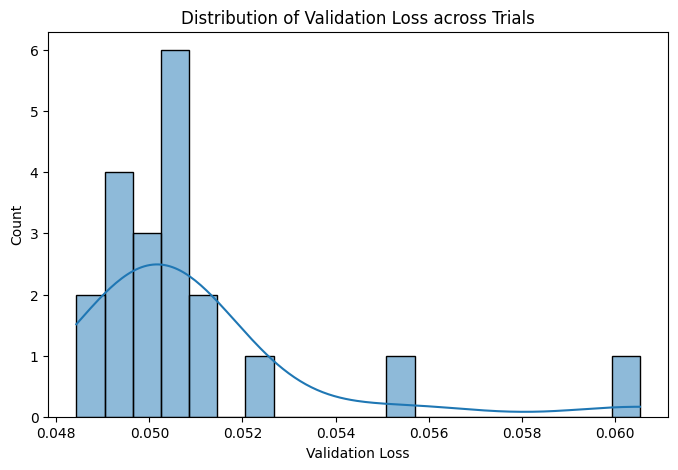

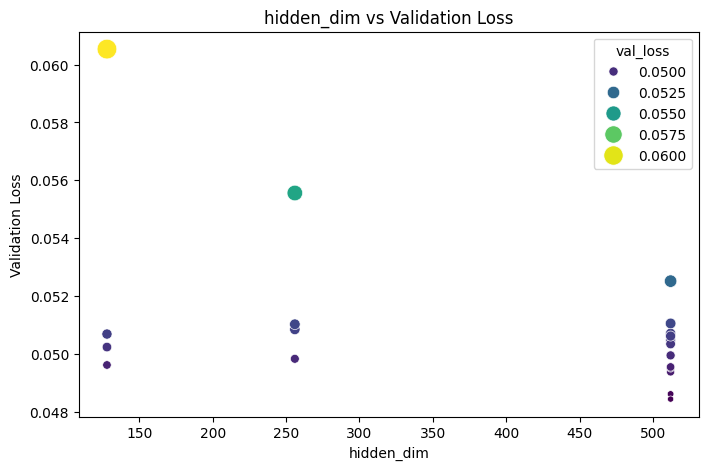

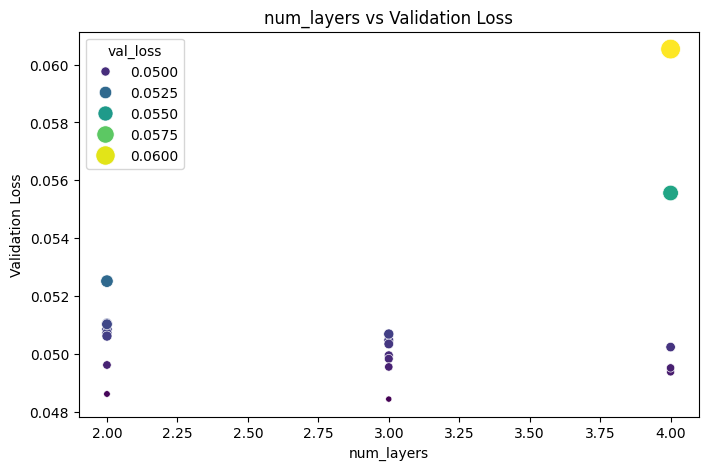

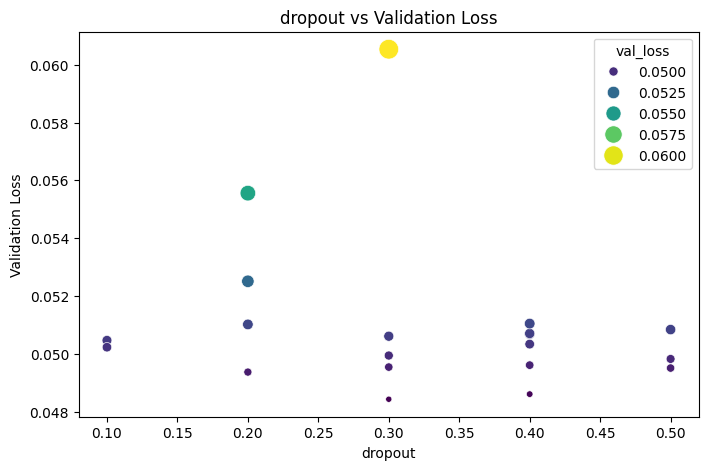

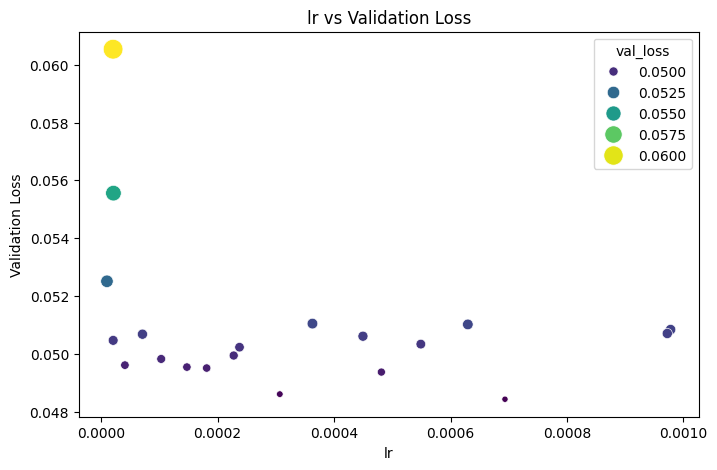

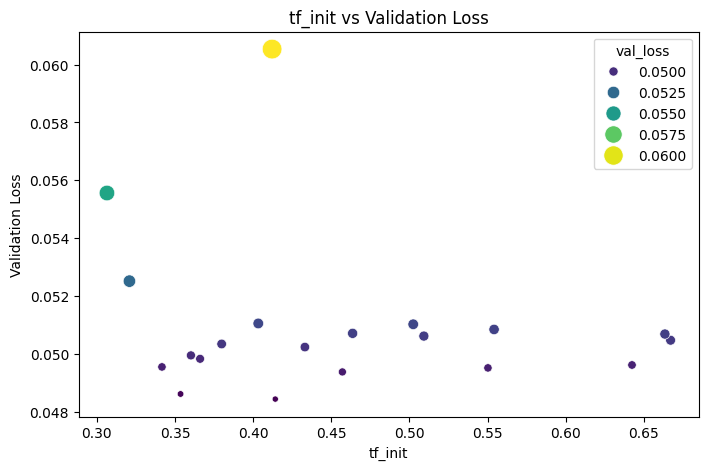

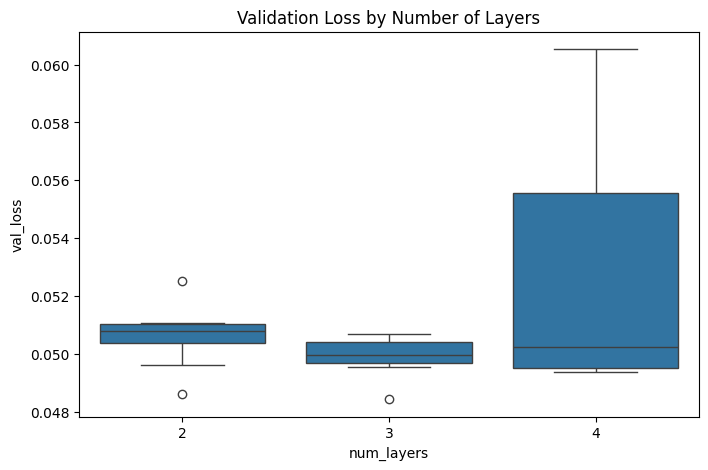

In [14]:
# 셀 G: Optuna 실험 후처리 (결과 분석 및 시각화)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 결과 CSV 불러오기
result_dir = Path("optuna_results_bi-lstm")

model_dir = Path("saved_models_bi-lstm")
file_path = result_dir / "results_optuna.csv"  # Path 객체와 문자열을 / 연산자로 연결
df = pd.read_csv(file_path)


# df = pd.read_csv(model_dir, "/results_optuna.csv")

# val_loss 기준으로 정렬
df_sorted = df.sort_values(by="val_loss", ascending=True).reset_index(drop=True)

# 상위 10개 결과 출력
print("===== Top 10 Trials by Validation Loss =====")
display(df_sorted.head(10))

# 가장 좋은 모델 정보
best_trial = df_sorted.iloc[0]
print("\nBest Trial Hyperparameters:")
print(best_trial.to_dict())

# 성능 분포 시각화
plt.figure(figsize=(8, 5))
sns.histplot(df["val_loss"], bins=20, kde=True)
plt.title("Distribution of Validation Loss across Trials")
plt.xlabel("Validation Loss")
plt.ylabel("Count")
plt.show()

# 하이퍼파라미터 vs 성능 시각화
params_to_plot = ["hidden_dim", "num_layers", "dropout", "lr", "tf_init"]
for param in params_to_plot:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=param, y="val_loss", hue="val_loss", palette="viridis", size="val_loss", sizes=(20,200))
    plt.title(f"{param} vs Validation Loss")
    plt.xlabel(param)
    plt.ylabel("Validation Loss")
    plt.show()

# 하이퍼파라미터 조합별 box plot (예: num_layers 별 val_loss 분포)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="num_layers", y="val_loss")
plt.title("Validation Loss by Number of Layers")
plt.show()

### 2.6.2. Best Model Plot 

Optuna 실험 결과(results_optuna.csv)에서 validation loss가 가장 낮은 trial의 하이퍼파라미터를 자동으로 불러와,
그에 맞는 Bi-LSTM Seq2Seq 모델을 구성하고, 저장된 모델(bilstm_optuna_best.pth)을 불러와 임의의 10개 샘플에 대해 예측 및 시각화를 수행하는 완성

사용 디바이스: cuda:1
최적 하이퍼파라미터 요약:
trial          11.000000
hidden_dim    512.000000
num_layers      3.000000
dropout         0.300000
lr              0.000693
tf_init         0.414175
val_loss        0.048433
Name: 11, dtype: float64
데이터: X=(1755, 512, 7), Y=(1755, 256, 6)
모델 불러오기 완료: saved_models_bi-lstm/best_model_trial11.pth


/tmp/ipykernel_124866/2511086726.py:154: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_124866/2511086726.py:154: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


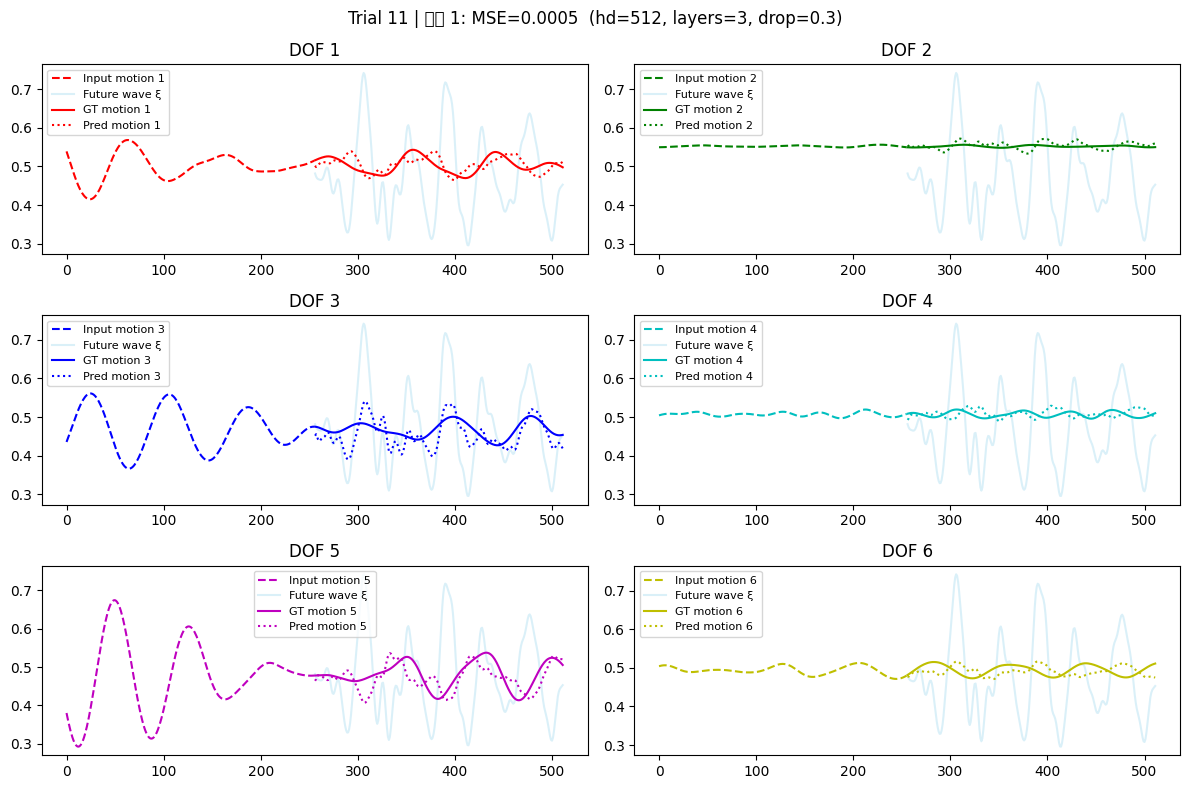

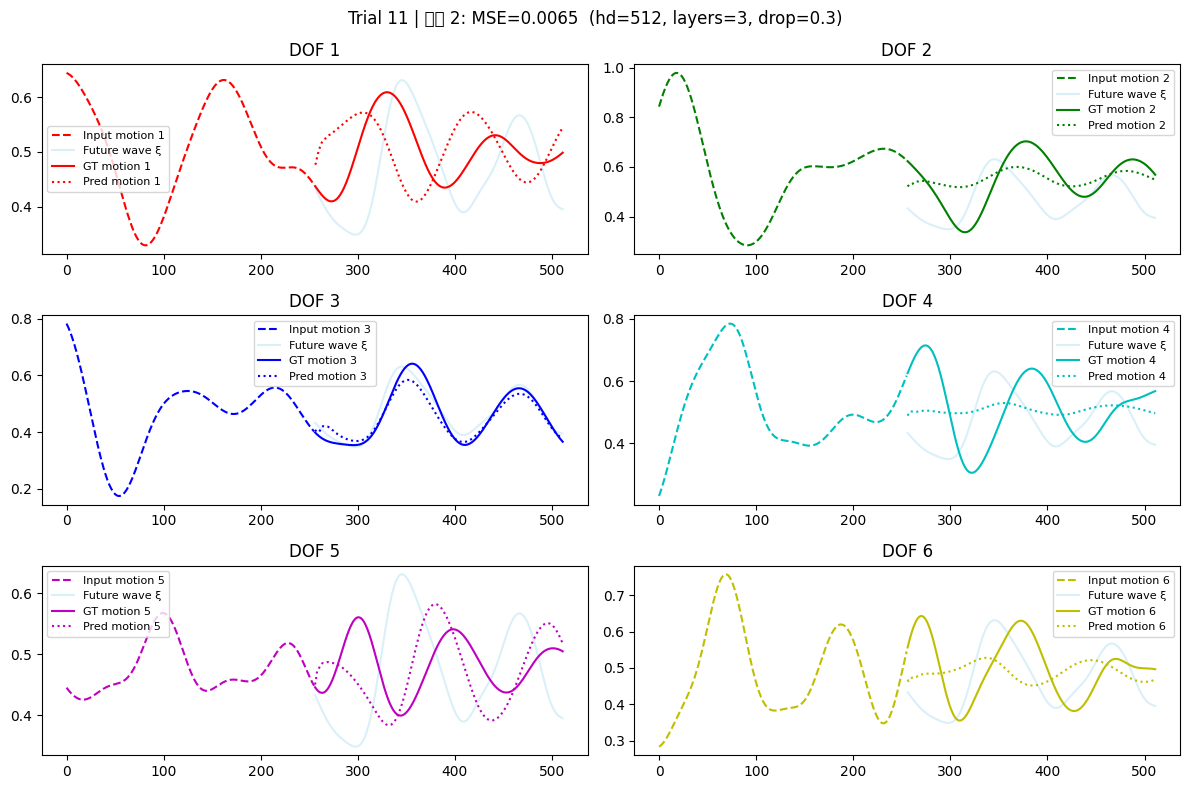

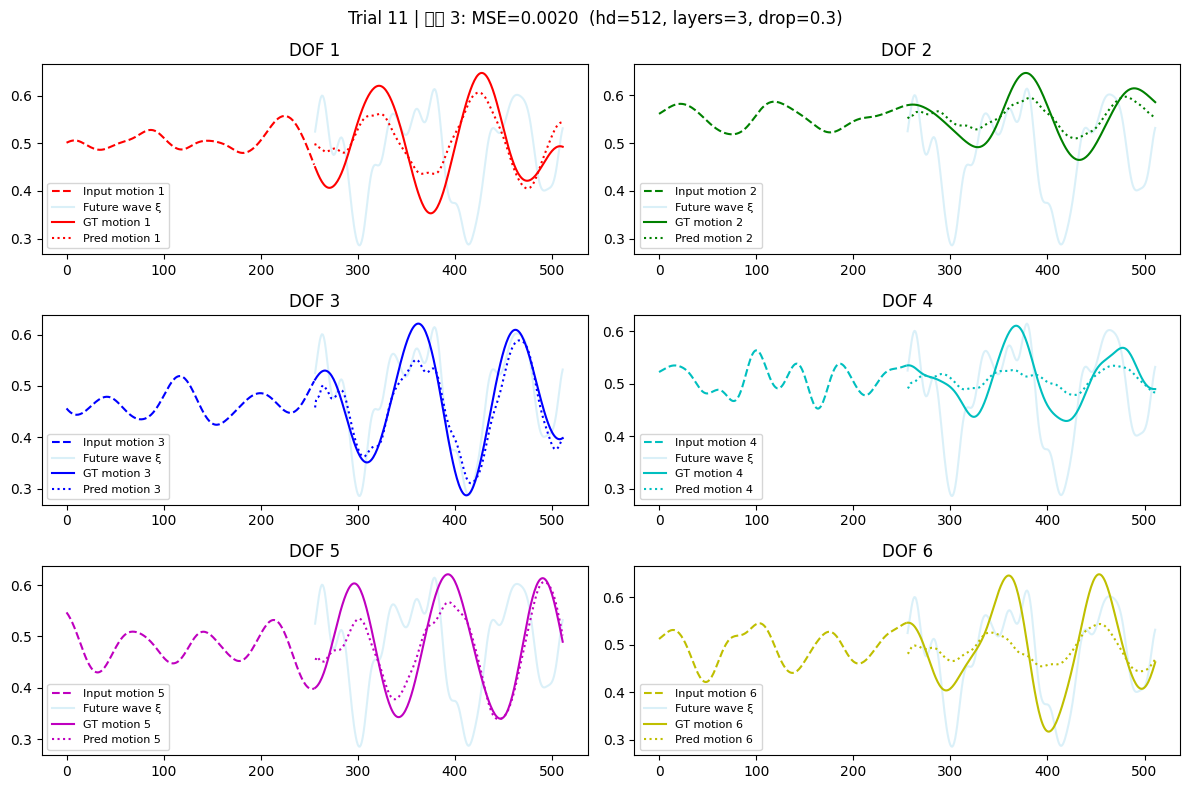

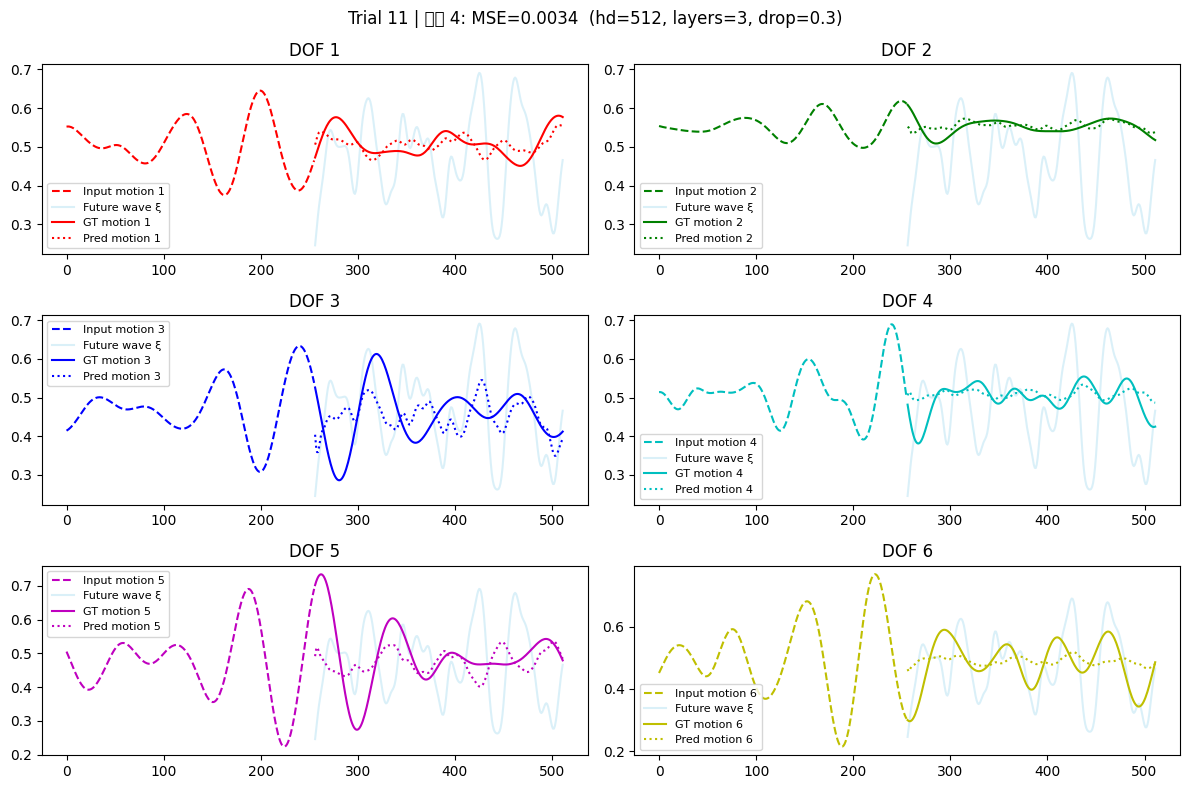

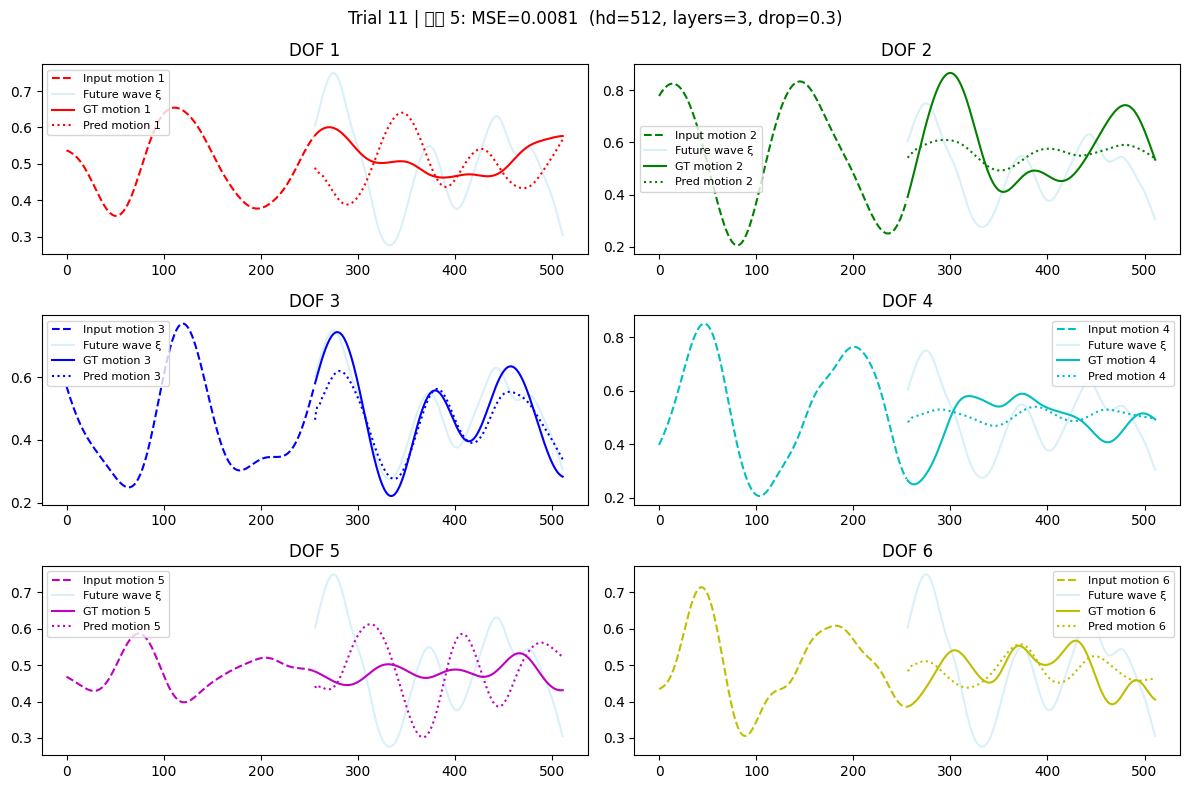

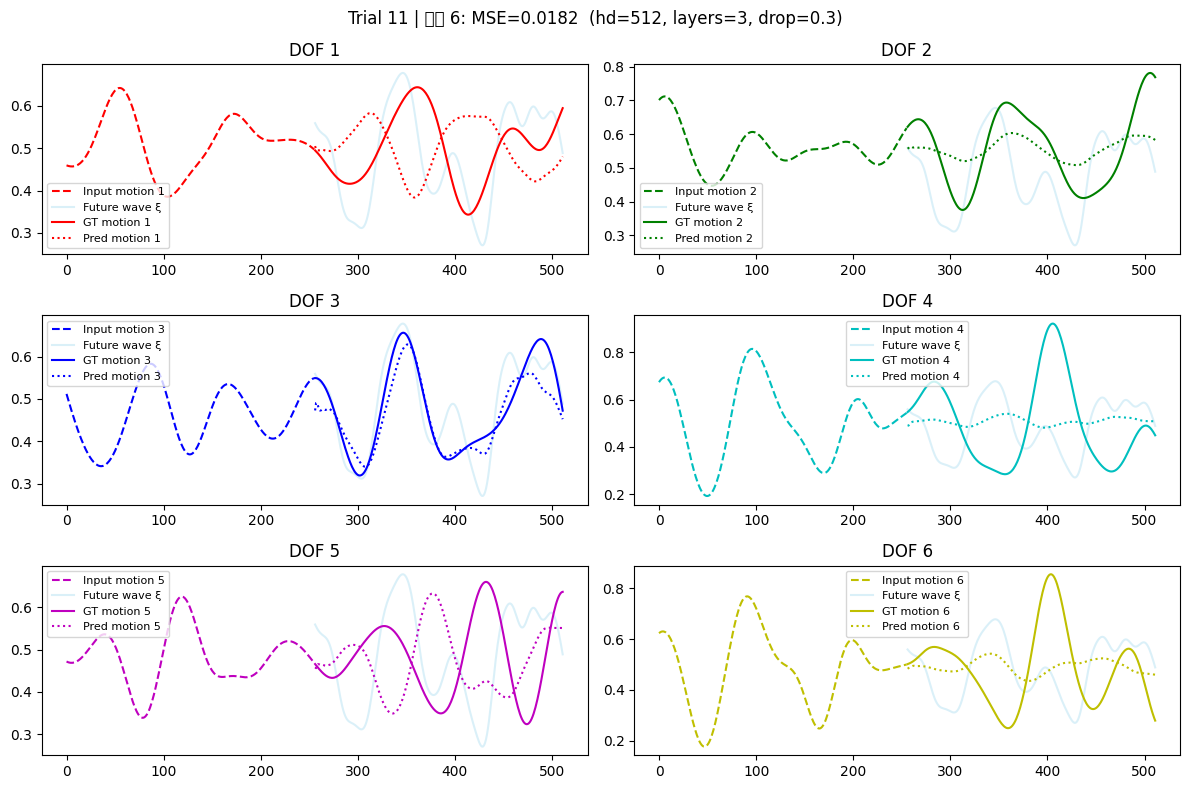

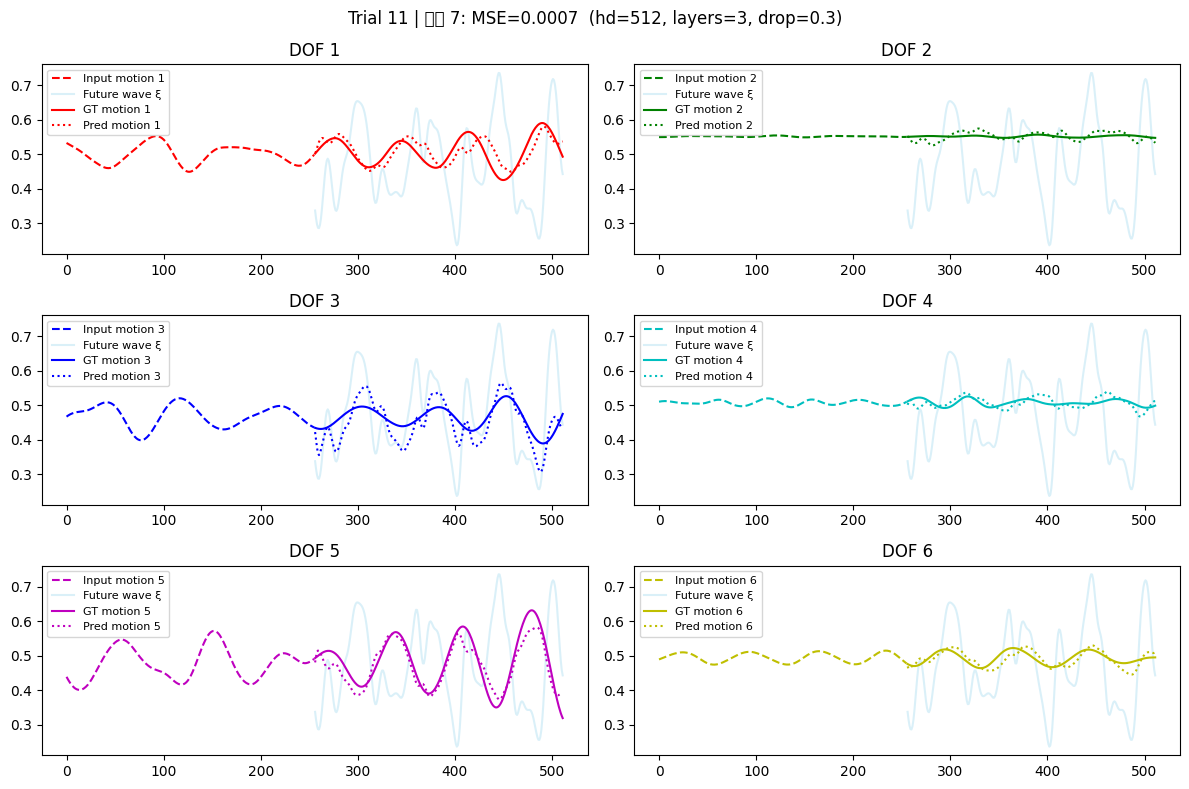

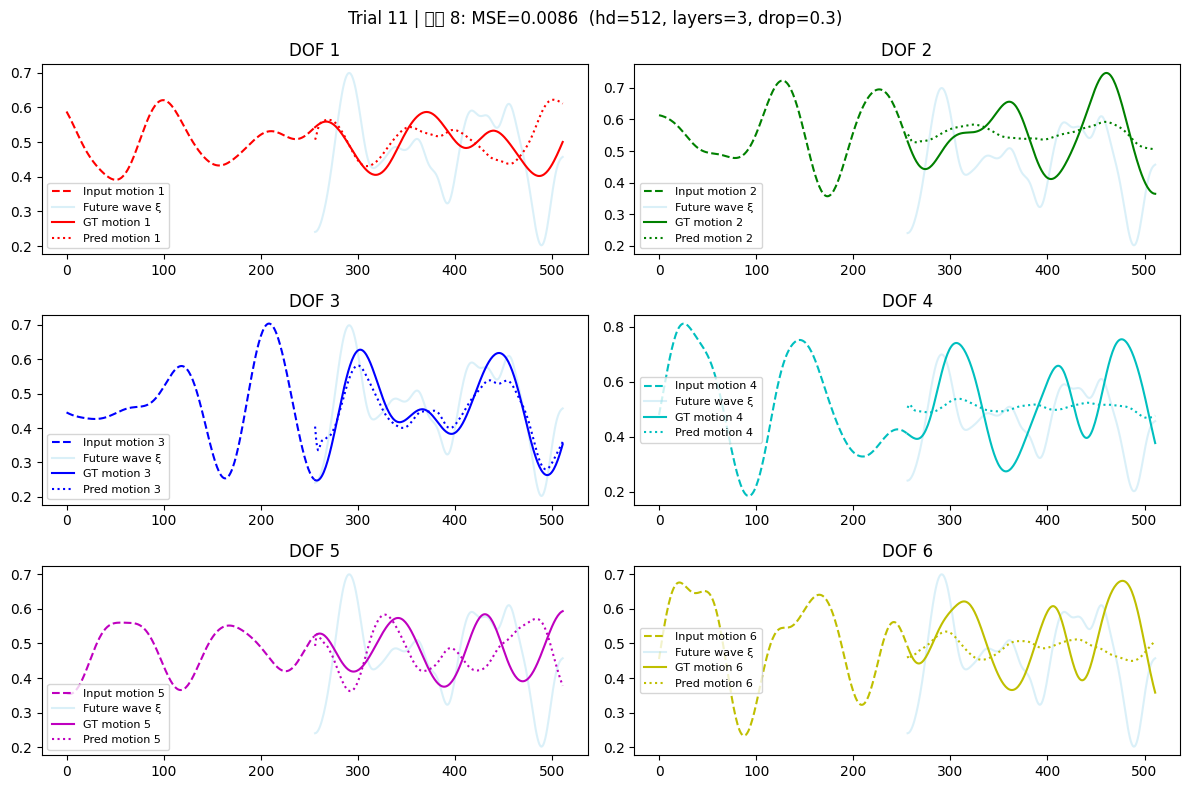

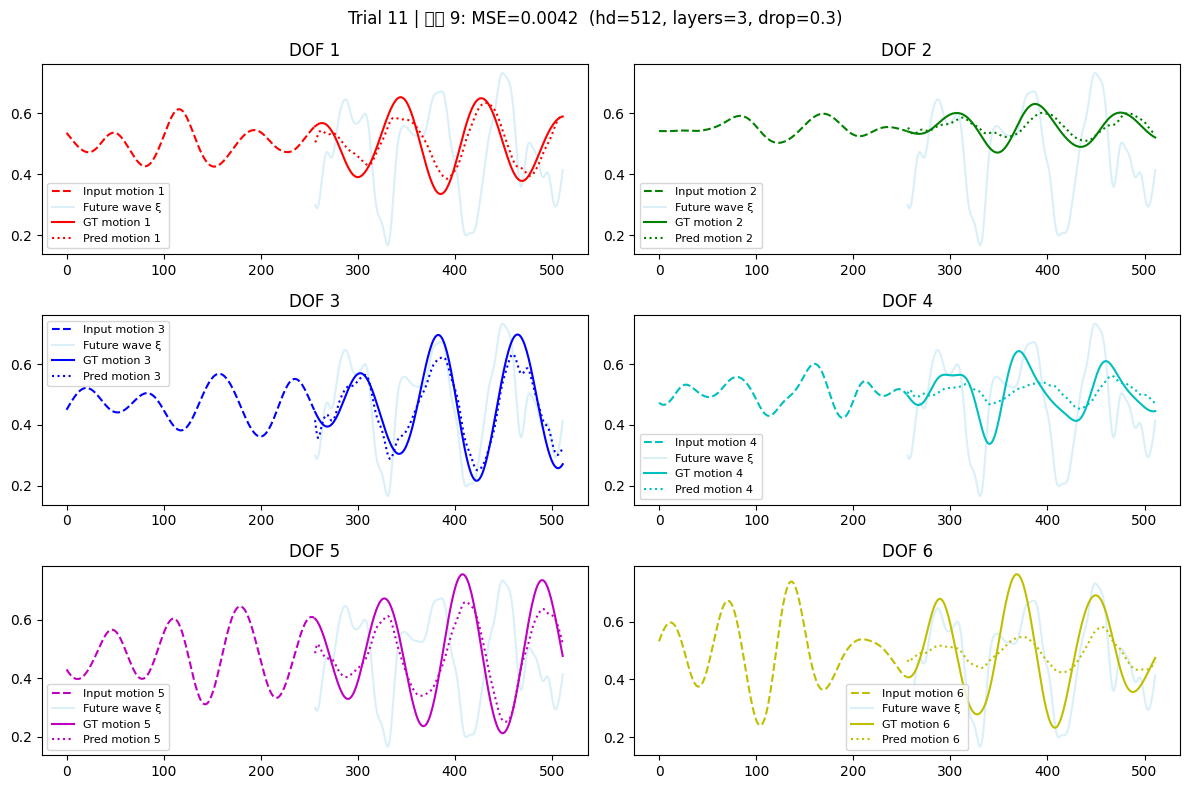

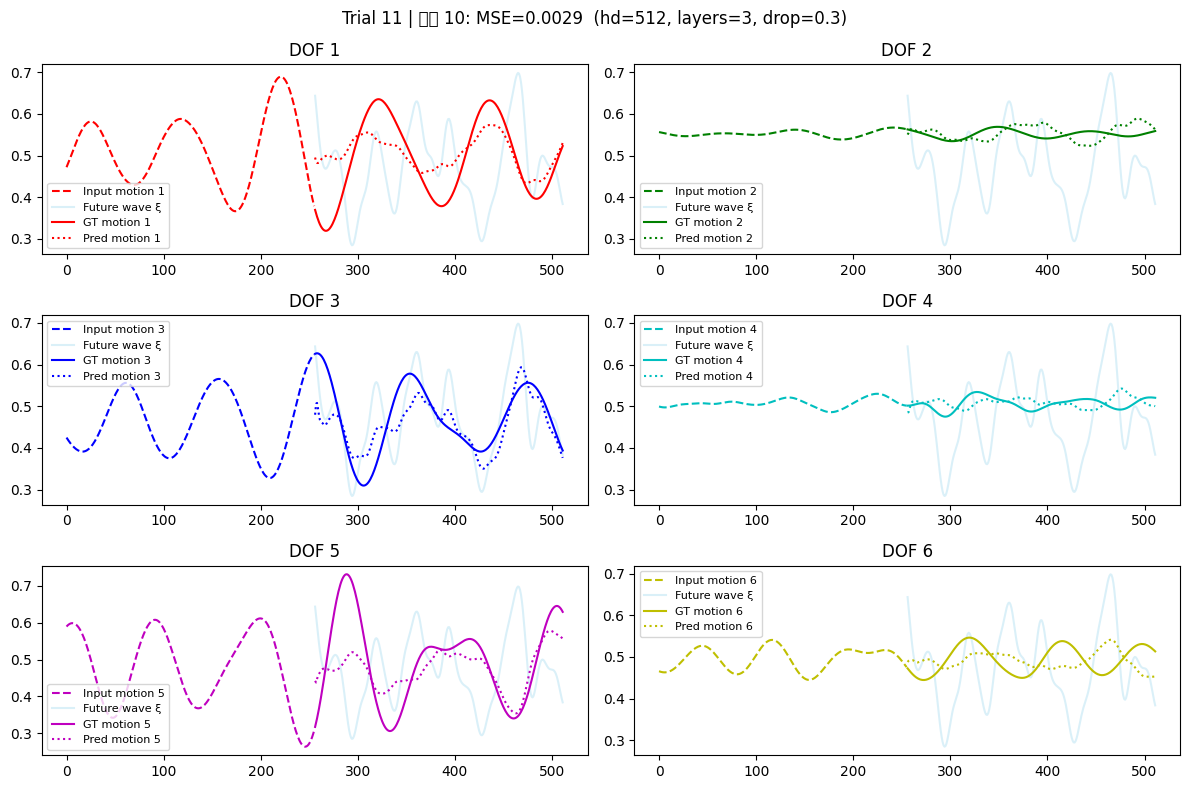

10개 샘플 중 기준(MSE<0.01) 충족 개수: 9/10


In [ ]:
# 셀 F: Optuna 최적 trial 모델 불러오기 & 임의 10개 샘플 예측 시각화

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import OrderedDict

# -----------------------------
# 경로 및 장치 설정
# -----------------------------
base_dir = Path(".")
# result_dir = base_dir / "optuna_results_bi-lstm"
# model_dir = base_dir / "saved_models_bi-lstm"
data_dir = base_dir / "prepared_datasets"

results_csv = result_dir / "results_optuna.csv"
summary_csv = result_dir / "optuna_summary.csv"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -----------------------------
# Optuna 결과 불러오기
# -----------------------------
df = pd.read_csv(results_csv)
if df.empty or "val_loss" not in df.columns:
    raise RuntimeError(f"유효한 결과가 없습니다: {results_csv}")

best_idx = df["val_loss"].idxmin()
best_row = df.loc[best_idx]

trial_num = int(best_row["trial"])
hidden_dim = int(best_row["hidden_dim"])
num_layers = int(best_row["num_layers"])
dropout = float(best_row["dropout"])
print("최적 하이퍼파라미터 요약:")
print(best_row[["trial", "hidden_dim", "num_layers", "dropout", "lr", "tf_init", "val_loss"]])

model_path = model_dir / f"best_model_trial{trial_num}.pth"
if not model_path.exists():
    # 가장 가까운 후보를 안내
    candidates = sorted(model_dir.glob("best_model_trial*.pth"))
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {model_path}\n"
                            f"아래 파일들이 존재합니다:\n" +
                            "\n".join(str(p) for p in candidates))

# -----------------------------
# BiLSTM Seq2Seq (optuna 코드와 동일 구조)
# -----------------------------
class BiLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        # decoder 입력: motion(6) + wave(1)
        self.decoder = nn.LSTM(output_dim+1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.0):
        _, (hidden, cell) = self.encoder(x)
        # 양방향 hidden/cell 합치기
        h_fwd, h_bwd = hidden[0::2], hidden[1::2]
        c_fwd, c_bwd = cell[0::2], cell[1::2]
        h, c = torch.cat((h_fwd, h_bwd), dim=2), torch.cat((c_fwd, c_bwd), dim=2)

        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features, device=x.device)
        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]            # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)                           # (B,1,6)
            outputs.append(pred)
            decoder_input_motion = pred
        return torch.cat(outputs, dim=1)                  # (B, target_len, 6)

# -----------------------------
# 데이터 불러오기
# -----------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N,512,7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N,256,6)
future_wave = X[:, 256:, 6].unsqueeze(-1)      # (N,256,1)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print(f"데이터: X={tuple(X.shape)}, Y={tuple(Y.shape)}")

# -----------------------------
# 모델 구성 및 가중치 로드
# -----------------------------
model = BiLSTMSeq2Seq(input_dim=input_dim,
                      hidden_dim=hidden_dim,
                      output_dim=output_dim,
                      num_layers=num_layers,
                      dropout=dropout).to(device)

state = torch.load(model_path, map_location=device)

# DataParallel로 저장된 가중치 호환 처리
if any(k.startswith("module.") for k in state.keys()):
    new_state = OrderedDict((k.replace("module.", ""), v) for k, v in state.items())
    state = new_state

model.load_state_dict(state)
model.eval()
print(f"모델 불러오기 완료: {model_path}")

# -----------------------------
# 임의 10개 샘플 예측 및 시각화
# -----------------------------
indices = random.sample(range(N), 10)
correct_count = 0
threshold = 0.01  # MSE 기준
colors = ["r", "g", "b", "c", "m", "y"]

for idx, sample_idx in enumerate(indices):
    sample_X = X[sample_idx].unsqueeze(0).to(device)           # (1,512,7)
    sample_wave = future_wave[sample_idx].unsqueeze(0).to(device)  # (1,256,1)
    gt_Y = Y[sample_idx].unsqueeze(0).to(device)               # (1,256,6)

    with torch.no_grad():
        pred_Y = model(sample_X, sample_wave, target_len=seq_out)

    mse = torch.mean((gt_Y - pred_Y) ** 2).item()
    if mse < threshold:
        correct_count += 1

    t_past = np.arange(seq_out)
    t_future = np.arange(seq_out, 2*seq_out)

    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    axes = axes.flatten()
    for j in range(output_dim):
        ax = axes[j]
        ax.plot(t_past, sample_X[0, :seq_out, j].detach().cpu().numpy(),
                linestyle="--", color=colors[j], label=f"Input motion {j+1}")
        ax.plot(t_future, sample_wave[0, :, 0].detach().cpu().numpy(),
                linestyle="-", color="skyblue", alpha=0.3, label="Future wave ξ")
        ax.plot(t_future, gt_Y[0, :, j].detach().cpu().numpy(),
                linestyle="-", color=colors[j], label=f"GT motion {j+1}")
        ax.plot(t_future, pred_Y[0, :, j].detach().cpu().numpy(),
                linestyle=":", color=colors[j], label=f"Pred motion {j+1}")
        ax.set_title(f"DOF {j+1}")
        ax.legend(fontsize=8)

    plt.suptitle(f"Trial {trial_num} | 샘플 {idx+1}: MSE={mse:.4f}  "
                 f"(hd={hidden_dim}, layers={num_layers}, drop={dropout})")
    plt.tight_layout()
    plt.show()

print(f"10개 샘플 중 기준(MSE<{threshold}) 충족 개수: {correct_count}/10")

## 2.7. Bi-GRU Optimization

Optuna를 붙여서 Bi-GRU 하이퍼파라미터를 최적화하는 코드입니다. 
  1.	GPU 0, 1 모두 사용: DataParallel을 적용해서 두 GPU를 동시에 활용합니다.
  2.	Optuna 탐색 기록: 각 trial의 결과(Train/Val Loss, 정확도 등)를 Optuna가 자동으로 DB에 저장합니다.
    - 나중에 study.trials_dataframe()으로 결과를 DataFrame으로 꺼내 비교할 수 있습니다.
	- 또, optuna-dashboard 같은 툴을 쓰면 웹 UI로 성능 비교도 가능합니다.
  3. 실험 기록 별도 저장:
    - 각 trial이 끝날 때마다 결과(예: hidden_dim, num_layers, dropout, val_loss)를 results_optuna.csv에 추가 저장합니다.
    - 가장 좋은 모델은 따로 best_model.pth로 저장합니다.

Nohup을 사용하여 실험합니다. 
  - nohup python -u optuna_experiment_bi-gru.py > train_bi_gru.log 2>&1 &
  - tail -f train_bi_gru.log

In [ ]:
# optuna_experiment_bi-gru.py (Bi-GRU + Optuna, improved)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import optuna
import pandas as pd
from pathlib import Path
import time
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # 주석처리하면 병렬로 학습

# -------------------------------------------------
# 경로 및 장치 설정
# -------------------------------------------------
data_dir   = Path("prepared_datasets")
model_dir  = Path("saved_models_bi-gru")
result_dir = Path("optuna_results_bi-gru")
model_dir.mkdir(exist_ok=True, parents=True)
result_dir.mkdir(exist_ok=True, parents=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -------------------------------------------------
# 데이터 불러오기
# -------------------------------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N, 512, 7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N, 256, 6)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print("데이터셋 크기:", X.shape, Y.shape)

future_wave = X[:, 256:, 6].unsqueeze(-1)      # (N, 256, 1)

dataset = TensorDataset(X, future_wave, Y)
val_ratio = 0.2
n_val = int(len(dataset) * val_ratio)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

# -------------------------------------------------
# Bi-GRU Seq2Seq 정의
# -------------------------------------------------
class BiGRUSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.decoder = nn.GRU(
            input_size=output_dim + 1,      # motion(6) + wave(1)
            hidden_size=hidden_dim * 2,     # encoder bi → 2*hidden
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.5):
        # Encoder
        _, h_n = self.encoder(x)  # (2*num_layers, B, hidden_dim)

        # bidirectional hidden 결합
        num_layers = h_n.size(0) // 2
        h_fwd = h_n[0:num_layers]         # (num_layers, B, hidden_dim)
        h_bwd = h_n[num_layers:2*num_layers]  # (num_layers, B, hidden_dim)
        h_cat = torch.cat((h_fwd, h_bwd), dim=2)  # (num_layers, B, 2*hidden_dim)

        h = h_cat  # decoder 초기 hidden
        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features, device=x.device)

        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]  # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, h = self.decoder(dec_in, h)   # out: (B,1,2*hidden), h: (num_layers,B,2*hidden)
            pred = self.fc(out)                # (B,1,6)
            outputs.append(pred)

            if target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input_motion = target[:, t:t+1, :]
            else:
                decoder_input_motion = pred

        return torch.cat(outputs, dim=1)  # (B, target_len, 6)

# -------------------------------------------------
# 학습/검증 루프
# -------------------------------------------------
def train_one_trial(model, optimizer, criterion, epochs=50, teacher_forcing_init=0.5,
                    patience=10, seq_out=256, verbose=False):
    best_val = np.inf
    patience_cnt = 0

    for epoch in range(1, epochs + 1):
        tf_ratio = max(0.0, teacher_forcing_init * (0.95 ** epoch))

        model.train()
        t0 = time.time()
        train_loss = 0.0
        for xb, wf, yb in train_loader:
            xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb, wf, target=yb, target_len=seq_out, teacher_forcing_ratio=tf_ratio)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, wf, yb in val_loader:
                xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
                out = model(xb, wf, target=None, target_len=seq_out, teacher_forcing_ratio=0.0)
                val_loss += criterion(out, yb).item()
        val_loss /= len(val_loader)
        t1 = time.time()

        if verbose:
            print(f"Epoch {epoch:03d}/{epochs} | TF={tf_ratio:.3f} | "
                  f"Train {train_loss:.6f} | Val {val_loss:.6f} | {t1 - t0:.1f}s")

        if val_loss < best_val - 1e-12:
            best_val = val_loss
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print("Early stopping 발동")
                break

    return best_val

# -------------------------------------------------
# Optuna Objective
# -------------------------------------------------
def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 1024, log=True)
    num_layers = trial.suggest_int("num_layers", 2, 7)
    dropout    = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.4, 0.5])
    lr         = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    tf_init    = trial.suggest_float("tf_init", 0.3, 0.7)

    net = BiGRUSeq2Seq(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
    if torch.cuda.device_count() >= 2:
        net = nn.DataParallel(net, device_ids=[0, 1])

    criterion = nn.L1Loss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    best_val = train_one_trial(
        model=net, optimizer=optimizer, criterion=criterion,
        epochs=50, teacher_forcing_init=tf_init, patience=10,
        seq_out=seq_out, verbose=False
    )

    torch.save(net.state_dict(), model_dir / f"best_model_trial{trial.number}.pth")

    result_path = result_dir / "results_optuna.csv"
    row = {
        "trial": trial.number,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "tf_init": tf_init,
        "val_loss": best_val,
    }
    df_row = pd.DataFrame([row])
    if result_path.exists():
        df_row.to_csv(result_path, mode="a", header=False, index=False)
    else:
        df_row.to_csv(result_path, index=False)

    return best_val

# -------------------------------------------------
# Optuna 실행
# -------------------------------------------------
if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)

    print("Best trial params:", study.best_trial.params)
    print("Best value:", study.best_value)

    df_all = study.trials_dataframe()
    df_all.to_csv(result_dir / "optuna_summary.csv", index=False)
    print("전체 trial 결과 optuna_summary.csv 저장 완료")

    best_trial_num = study.best_trial.number
    best_trial_path = model_dir / f"best_model_trial{best_trial_num}.pth"
    if not best_trial_path.exists():
        raise FileNotFoundError(f"최적 trial 가중치 파일이 없습니다: {best_trial_path}")

    state = torch.load(best_trial_path, map_location=device)
    torch.save(state, model_dir / "gru_optuna_best.pth")
    print(f"최적 모델 저장 완료: {model_dir / 'gru_optuna_best.pth'}")

### 2.7.1 Optimization Summary Plot

===== Top 10 Trials by Validation Loss =====


,trial,hidden_dim,num_layers,dropout,lr,tf_init,val_loss
0,12,34,6,0.5,0.000718,0.332865,0.045600
1,1,1010,5,0.3,0.000469,0.396220,0.045654
2,11,52,6,0.5,0.000954,0.349719,0.045723
3,15,33,6,0.5,0.000535,0.363899,0.046286
4,2,99,6,0.5,0.000318,0.454554,0.046660
5,9,354,5,0.5,0.000286,0.598511,0.047557
6,19,656,6,0.4,0.000031,0.332479,0.047771
7,8,160,7,0.4,0.000081,0.518482,0.047786
8,17,171,3,0.3,0.000181,0.382511,0.049329
9,5,89,5,0.2,0.000103,0.402899,0.050089



Best Trial Hyperparameters:
{'trial': 12.0, 'hidden_dim': 34.0, 'num_layers': 6.0, 'dropout': 0.5, 'lr': 0.0007183596943359, 'tf_init': 0.3328645898015212, 'val_loss': 0.0455999174578623}


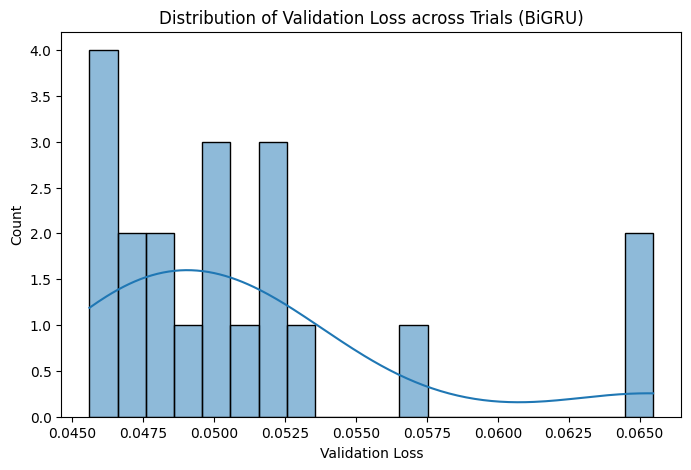

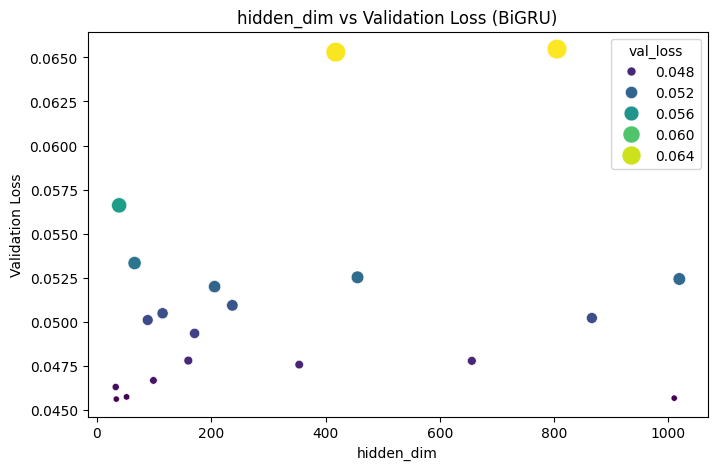

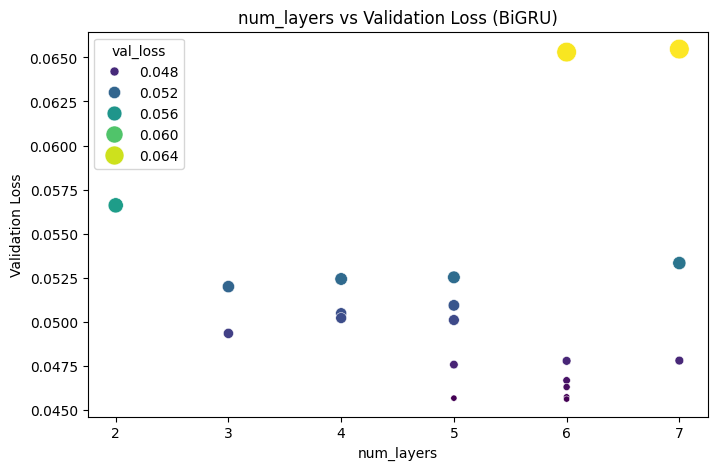

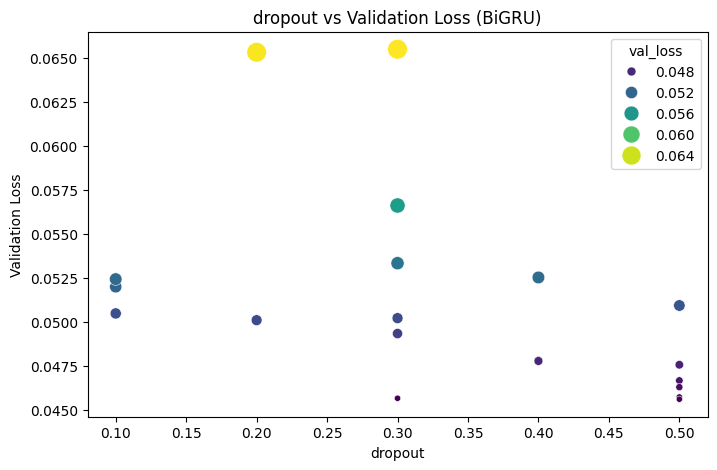

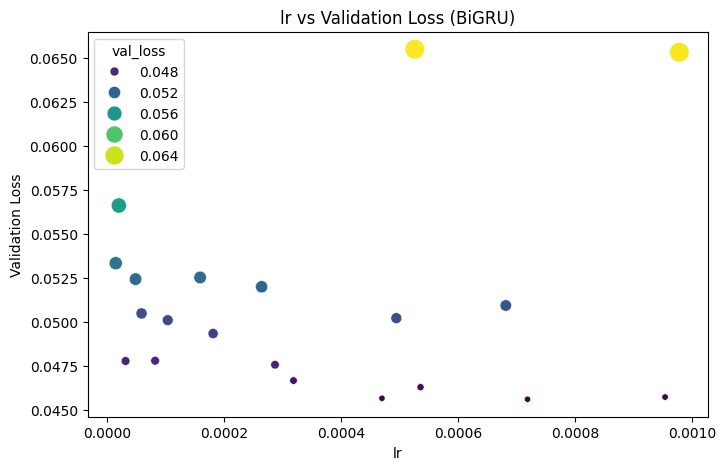

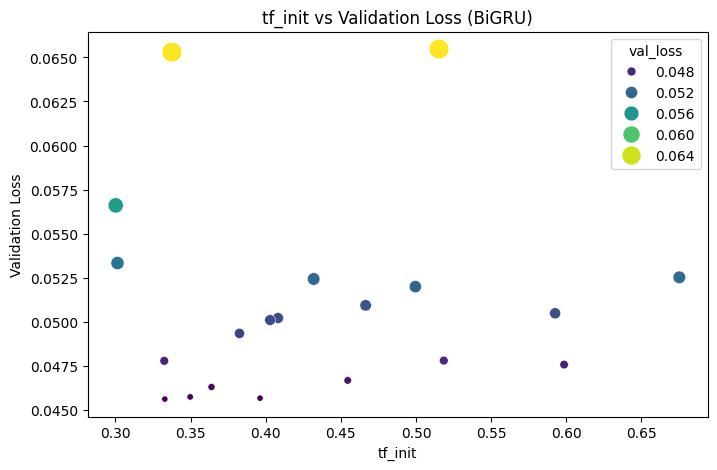

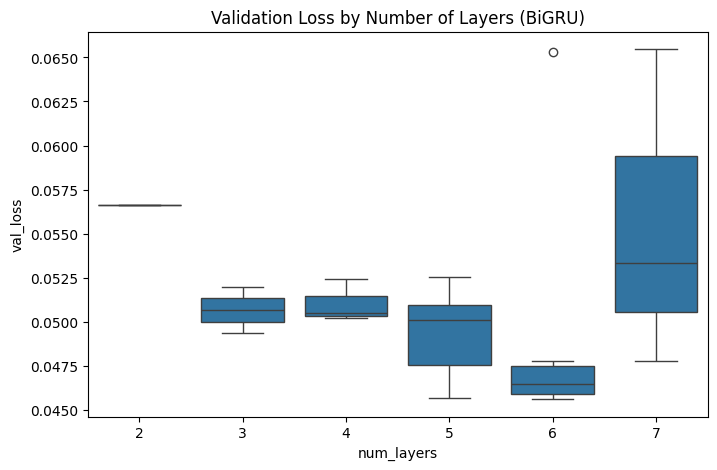

In [1]:
# 셀 G: Optuna 실험 후처리 (결과 분석 및 시각화 - BiGRU 버전)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 결과 CSV 불러오기
result_dir = Path("optuna_results_bi-gru")
model_dir = Path("saved_models_bi-gru")
file_path = result_dir / "results_optuna.csv"

df = pd.read_csv(file_path)

# val_loss 기준으로 정렬
df_sorted = df.sort_values(by="val_loss", ascending=True).reset_index(drop=True)

# 상위 10개 결과 출력
print("===== Top 10 Trials by Validation Loss =====")
display(df_sorted.head(10))

# 가장 좋은 모델 정보
best_trial = df_sorted.iloc[0]
print("\nBest Trial Hyperparameters:")
print(best_trial.to_dict())

# 성능 분포 시각화
plt.figure(figsize=(8, 5))
sns.histplot(df["val_loss"], bins=20, kde=True)
plt.title("Distribution of Validation Loss across Trials (BiGRU)")
plt.xlabel("Validation Loss")
plt.ylabel("Count")
plt.show()

# 하이퍼파라미터 vs 성능 시각화
params_to_plot = ["hidden_dim", "num_layers", "dropout", "lr", "tf_init"]
for param in params_to_plot:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=param, y="val_loss",
                    hue="val_loss", palette="viridis",
                    size="val_loss", sizes=(20,200))
    plt.title(f"{param} vs Validation Loss (BiGRU)")
    plt.xlabel(param)
    plt.ylabel("Validation Loss")
    plt.show()

# 하이퍼파라미터 조합별 box plot (예: num_layers 별 val_loss 분포)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="num_layers", y="val_loss")
plt.title("Validation Loss by Number of Layers (BiGRU)")
plt.show()

### 2.7.2. Best Model Plot

사용 디바이스: cuda:1
최적 하이퍼파라미터 요약:
trial         12.000000
hidden_dim    34.000000
num_layers     6.000000
dropout        0.500000
lr             0.000718
tf_init        0.332865
val_loss       0.045600
Name: 12, dtype: float64
데이터: X=(1755, 512, 7), Y=(1755, 256, 6)
모델 불러오기 완료: saved_models_bi-gru/best_model_trial12.pth


/tmp/ipykernel_201889/947691419.py:152: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_201889/947691419.py:152: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yangjun/lloyd/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


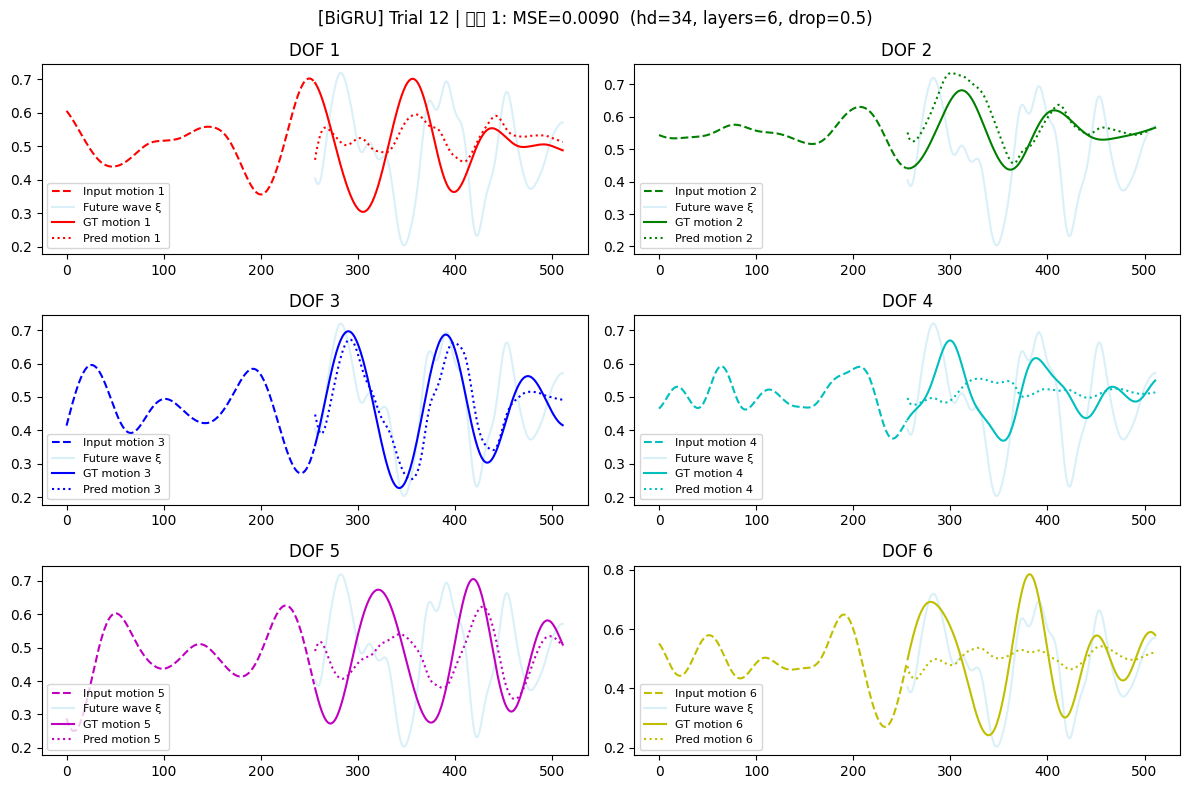

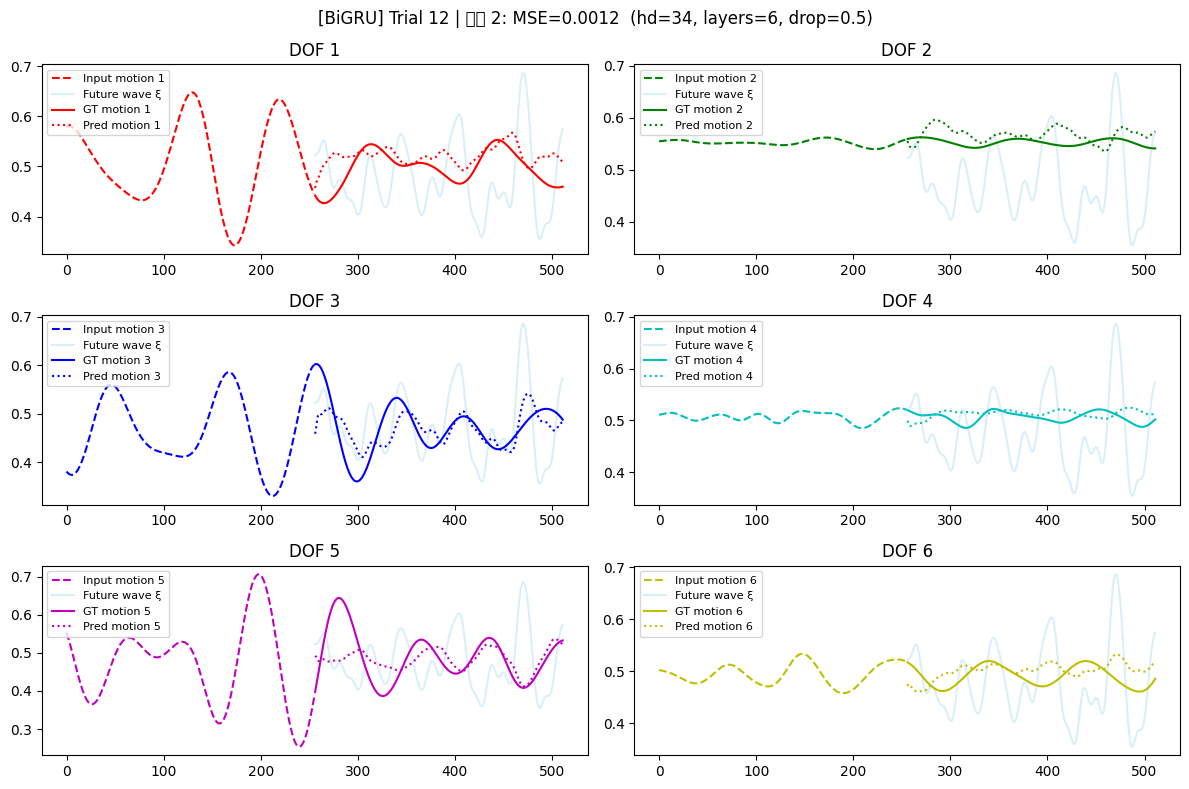

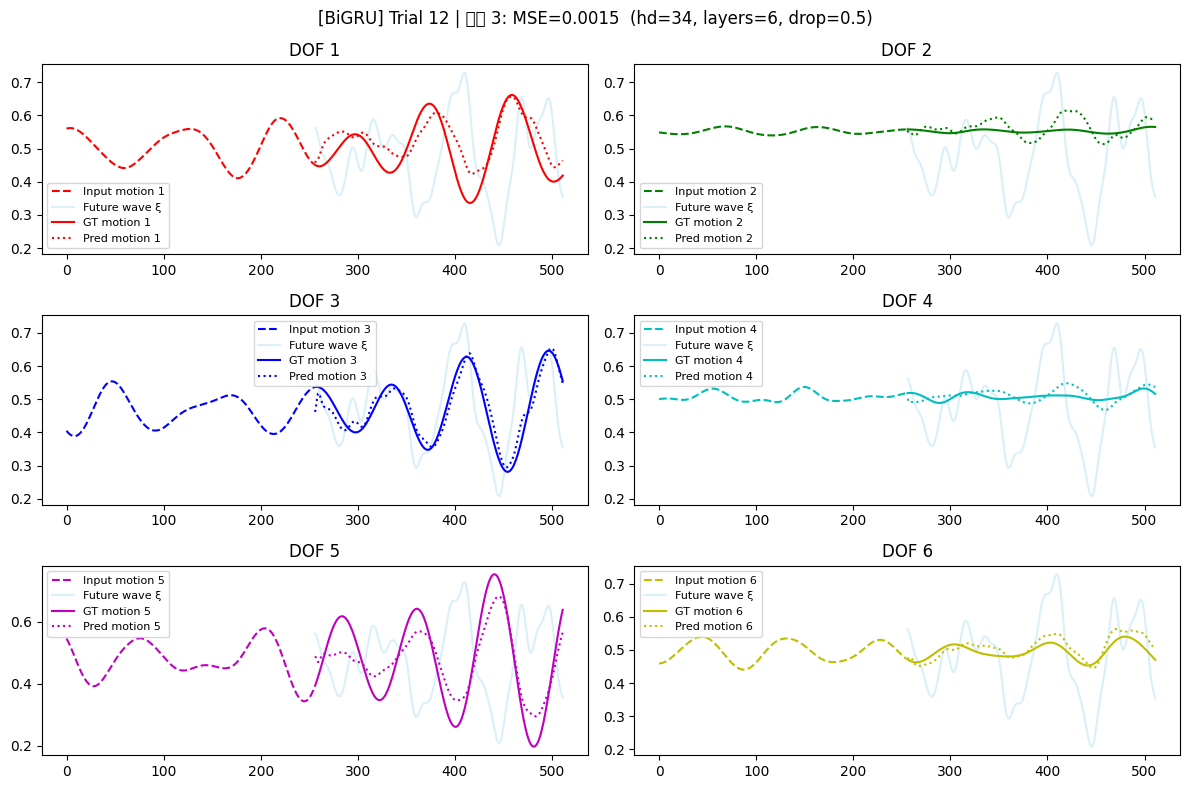

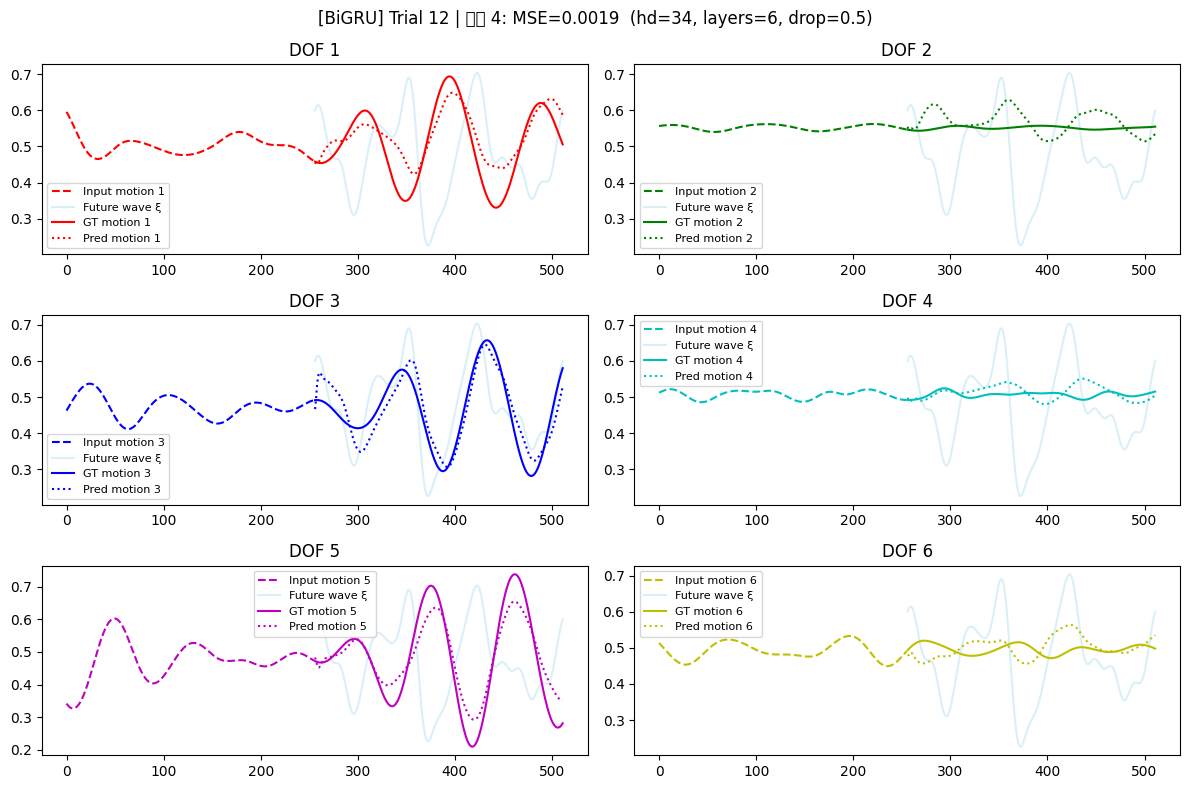

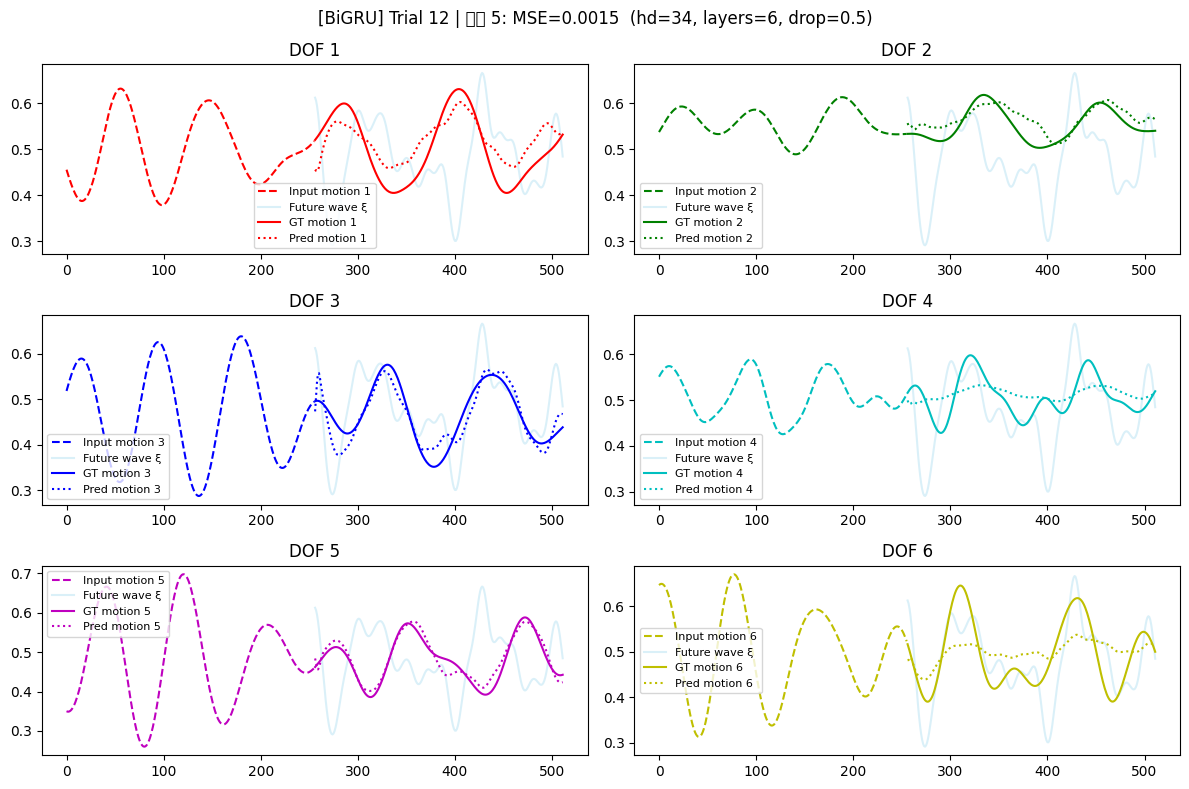

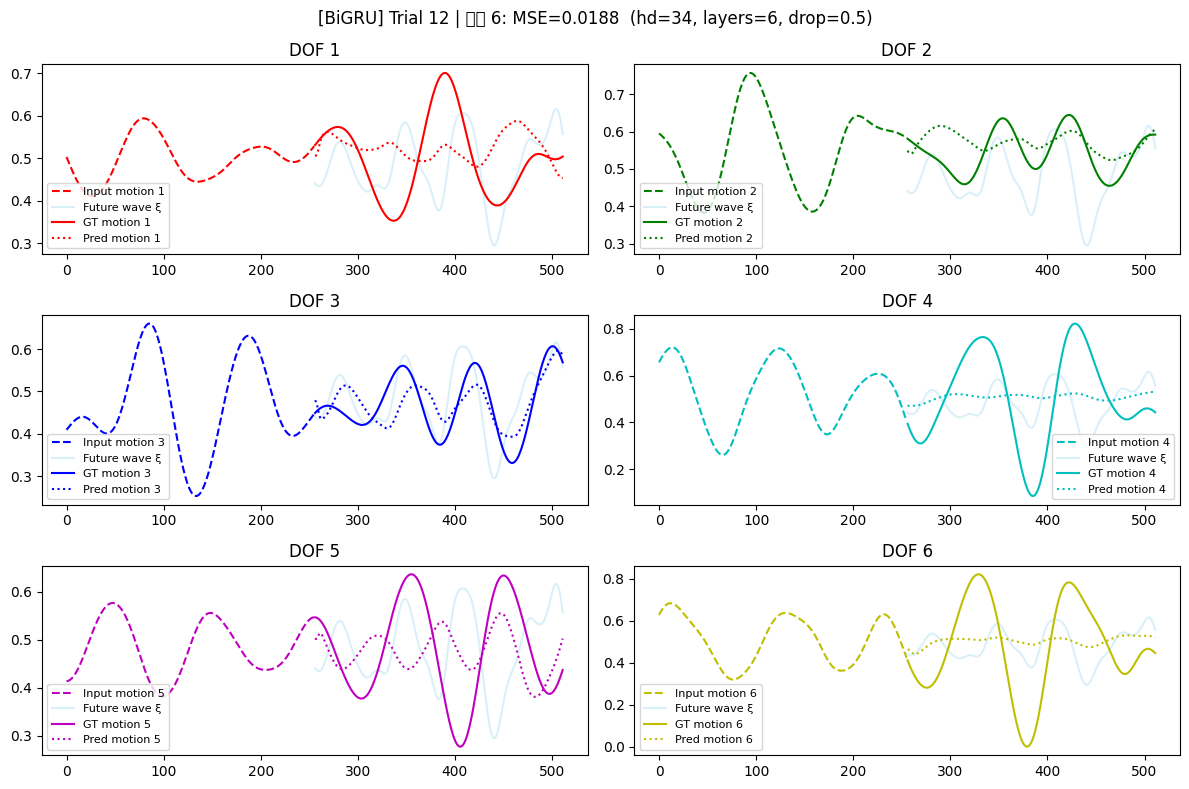

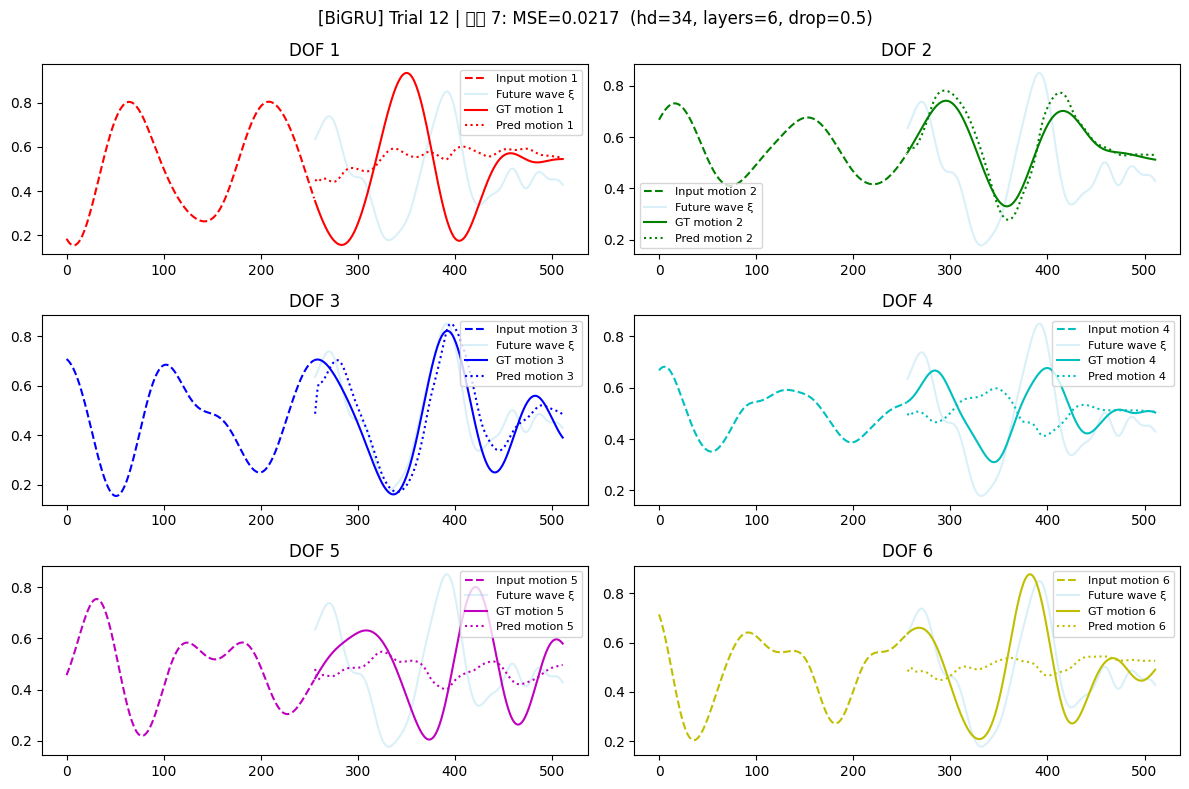

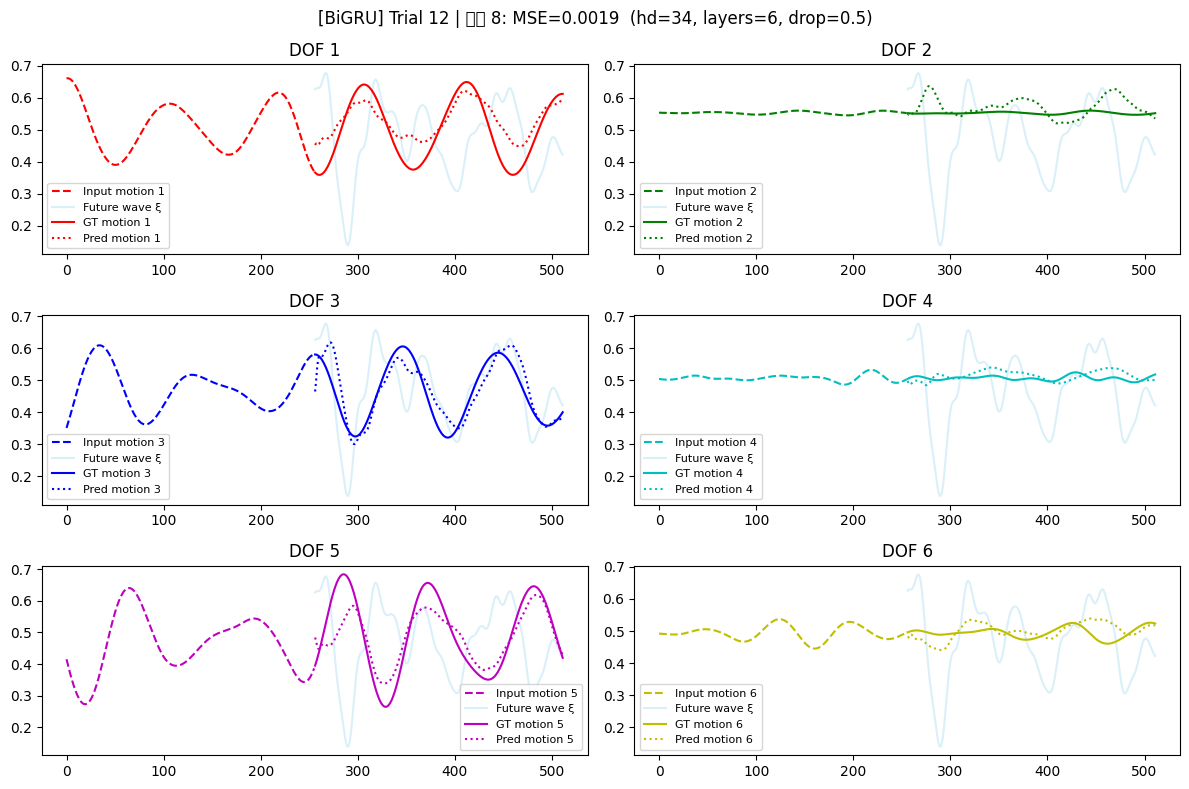

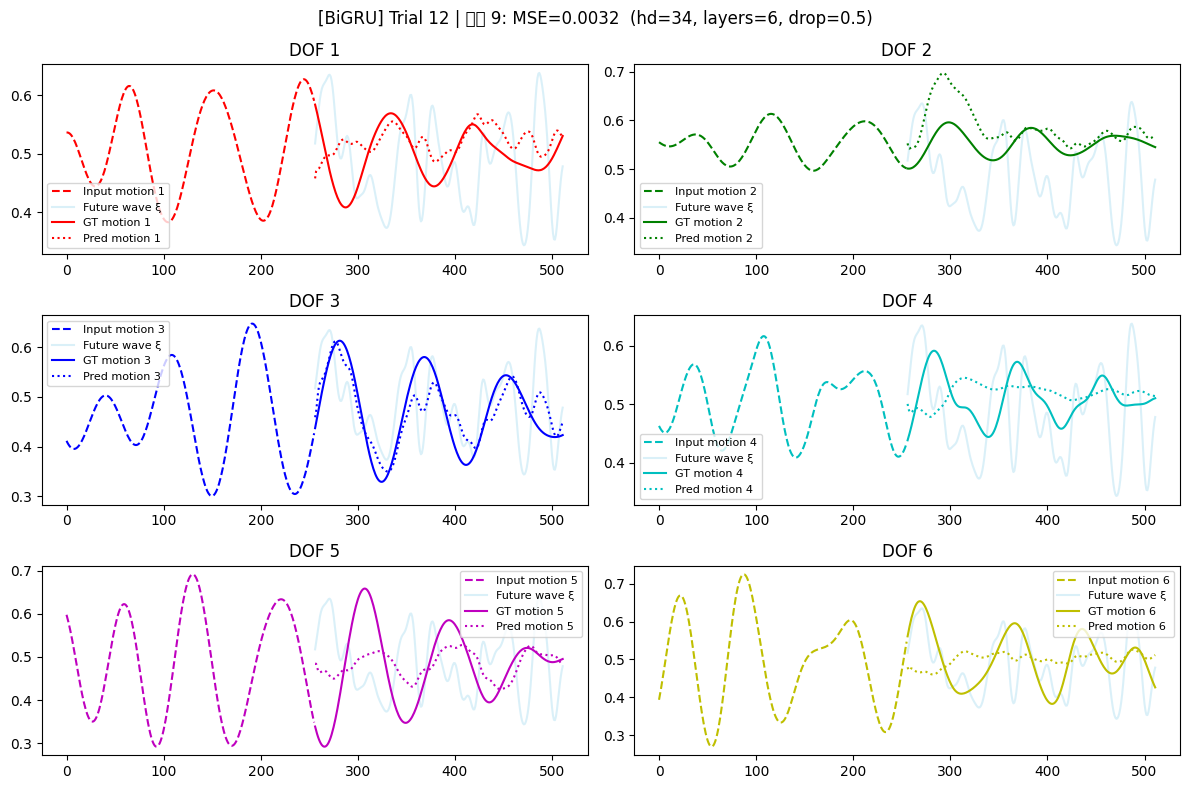

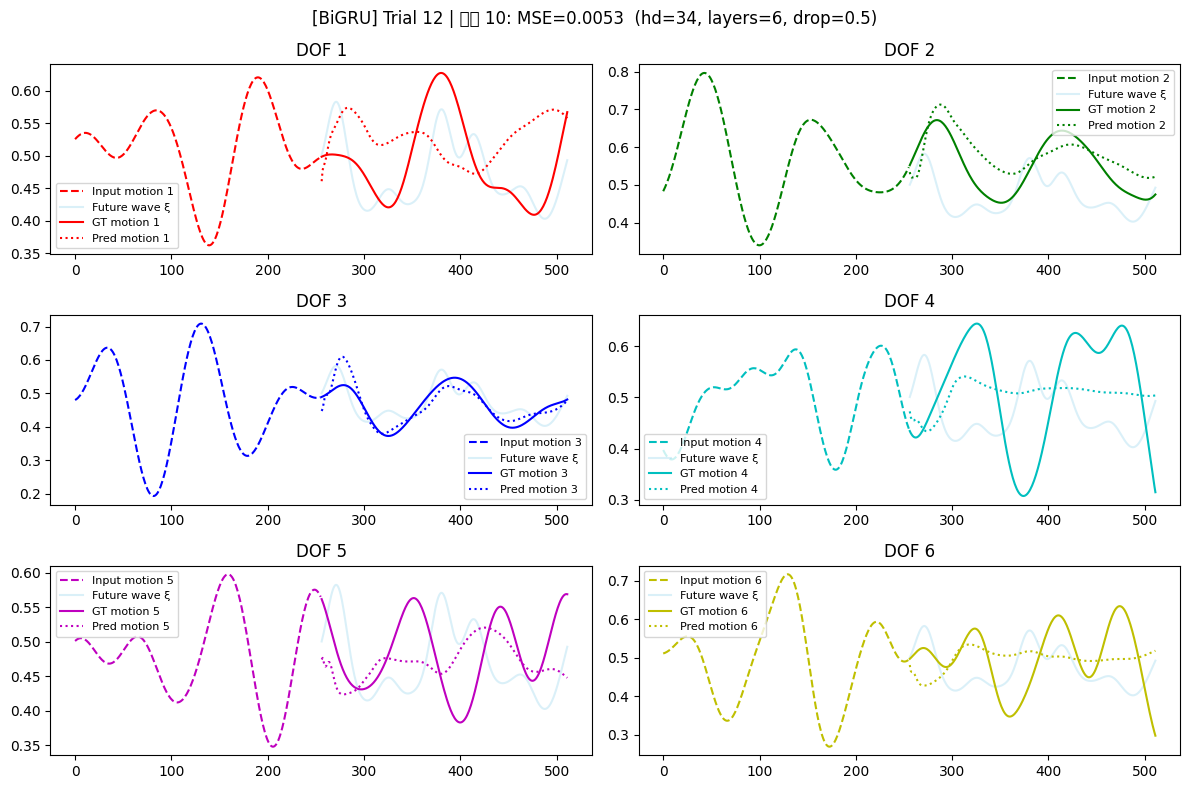

10개 샘플 중 기준(MSE<0.01) 충족 개수: 8/10


In [2]:
# 셀 F: Optuna 최적 trial 모델 불러오기 & 임의 10개 샘플 예측 시각화 (BiGRU 버전)

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import OrderedDict

# -----------------------------
# 경로 및 장치 설정
# -----------------------------
base_dir = Path(".")
result_dir = base_dir / "optuna_results_bi-gru"
model_dir = base_dir / "saved_models_bi-gru"
data_dir = base_dir / "prepared_datasets"

results_csv = result_dir / "results_optuna.csv"
summary_csv = result_dir / "optuna_summary.csv"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# -----------------------------
# Optuna 결과 불러오기
# -----------------------------
df = pd.read_csv(results_csv)
if df.empty or "val_loss" not in df.columns:
    raise RuntimeError(f"유효한 결과가 없습니다: {results_csv}")

best_idx = df["val_loss"].idxmin()
best_row = df.loc[best_idx]

trial_num = int(best_row["trial"])
hidden_dim = int(best_row["hidden_dim"])
num_layers = int(best_row["num_layers"])
dropout = float(best_row["dropout"])
print("최적 하이퍼파라미터 요약:")
print(best_row[["trial", "hidden_dim", "num_layers", "dropout", "lr", "tf_init", "val_loss"]])

model_path = model_dir / f"best_model_trial{trial_num}.pth"
if not model_path.exists():
    candidates = sorted(model_dir.glob("best_model_trial*.pth"))
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {model_path}\n"
                            f"아래 파일들이 존재합니다:\n" +
                            "\n".join(str(p) for p in candidates))

# -----------------------------
# BiGRU Seq2Seq (optuna 코드와 동일 구조)
# -----------------------------
class BiGRUSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=True, dropout=dropout)
        # decoder 입력: motion(6) + wave(1)
        self.decoder = nn.GRU(output_dim+1, hidden_dim*2, num_layers=num_layers,
                              batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.0):
        _, hidden = self.encoder(x)
        # 양방향 hidden 결합
        h_fwd, h_bwd = hidden[0::2], hidden[1::2]
        h = torch.cat((h_fwd, h_bwd), dim=2)

        B = x.size(0)
        decoder_input_motion = torch.zeros(B, 1, self.fc.out_features, device=x.device)
        outputs = []
        for t in range(target_len):
            wave_t = future_wave[:, t:t+1, :]            # (B,1,1)
            dec_in = torch.cat([decoder_input_motion, wave_t], dim=2)  # (B,1,7)
            out, h = self.decoder(dec_in, h)
            pred = self.fc(out)                           # (B,1,6)
            outputs.append(pred)
            decoder_input_motion = pred
        return torch.cat(outputs, dim=1)                  # (B, target_len, 6)

# -----------------------------
# 데이터 불러오기
# -----------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N,512,7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N,256,6)
future_wave = X[:, 256:, 6].unsqueeze(-1)      # (N,256,1)

N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape
print(f"데이터: X={tuple(X.shape)}, Y={tuple(Y.shape)}")

# -----------------------------
# 모델 구성 및 가중치 로드
# -----------------------------
model = BiGRUSeq2Seq(input_dim=input_dim,
                     hidden_dim=hidden_dim,
                     output_dim=output_dim,
                     num_layers=num_layers,
                     dropout=dropout).to(device)

state = torch.load(model_path, map_location=device)

# DataParallel로 저장된 가중치 호환 처리
if any(k.startswith("module.") for k in state.keys()):
    new_state = OrderedDict((k.replace("module.", ""), v) for k, v in state.items())
    state = new_state

model.load_state_dict(state)
model.eval()
print(f"모델 불러오기 완료: {model_path}")

# -----------------------------
# 임의 10개 샘플 예측 및 시각화
# -----------------------------
indices = random.sample(range(N), 10)
correct_count = 0
threshold = 0.01  # MSE 기준
colors = ["r", "g", "b", "c", "m", "y"]

for idx, sample_idx in enumerate(indices):
    sample_X = X[sample_idx].unsqueeze(0).to(device)           # (1,512,7)
    sample_wave = future_wave[sample_idx].unsqueeze(0).to(device)  # (1,256,1)
    gt_Y = Y[sample_idx].unsqueeze(0).to(device)               # (1,256,6)

    with torch.no_grad():
        pred_Y = model(sample_X, sample_wave, target_len=seq_out)

    mse = torch.mean((gt_Y - pred_Y) ** 2).item()
    if mse < threshold:
        correct_count += 1

    t_past = np.arange(seq_out)
    t_future = np.arange(seq_out, 2*seq_out)

    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    axes = axes.flatten()
    for j in range(output_dim):
        ax = axes[j]
        ax.plot(t_past, sample_X[0, :seq_out, j].detach().cpu().numpy(),
                linestyle="--", color=colors[j], label=f"Input motion {j+1}")
        ax.plot(t_future, sample_wave[0, :, 0].detach().cpu().numpy(),
                linestyle="-", color="skyblue", alpha=0.3, label="Future wave ξ")
        ax.plot(t_future, gt_Y[0, :, j].detach().cpu().numpy(),
                linestyle="-", color=colors[j], label=f"GT motion {j+1}")
        ax.plot(t_future, pred_Y[0, :, j].detach().cpu().numpy(),
                linestyle=":", color=colors[j], label=f"Pred motion {j+1}")
        ax.set_title(f"DOF {j+1}")
        ax.legend(fontsize=8)

    plt.suptitle(f"[BiGRU] Trial {trial_num} | 샘플 {idx+1}: MSE={mse:.4f}  "
                 f"(hd={hidden_dim}, layers={num_layers}, drop={dropout})")
    plt.tight_layout()
    plt.show()

print(f"10개 샘플 중 기준(MSE<{threshold}) 충족 개수: {correct_count}/10")

# 3. Feature Weighting

Heave와 Pitch의 정확도는 높지만 다른 운동의 정확도는 높지가 않습니다. 따라서 다른 피쳐들의 정확도를 높이기 위해 피쳐 학습 방법을 연구합니다. 

## 3.1. Qunatify Uncertainty

Optuna 결과 파일에서 각 모델 계열의 최적 trial을 찾아 그 가중치를 불러옵니다. 기존 모델은 평균만 예측하도록 학습되어 있으므로 확장 모델의 전반부(평균 헤드)에 기존 fc 가중치를 이식하고, 후반부(로그분산 헤드)는 0 근처로 초기화해 즉시 heteroscedastic NLL과 DOF별 그래디언트 배분을 관찰할 수 있게 했습니다. quantify 함수는 미니배치 하나를 사용하여 DOF별 NLL과 MAE를 출력하고, 역전파로 얻은 마지막 선형층의 각 DOF 행의 그래디언트 노름을 계산하여 어느 자유도에 학습 신호가 더 많이 배분되는지 정량화합니다. 

In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from collections import OrderedDict

# ---------------------------
# 경로 및 장치
# ---------------------------
base = Path(".")
data_dir = base / "prepared_datasets"
res_lstm = base / "optuna_results_bi-lstm" / "results_optuna.csv"
res_gru  = base / "optuna_results_bi-gru" / "results_optuna.csv"
mdl_lstm_dir = base / "saved_models_bi-lstm"
mdl_gru_dir  = base / "saved_models_bi-gru"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# ---------------------------
# 데이터 불러오기
# ---------------------------
X = torch.load(data_dir / "prediction_X.pt")   # (N,512,7)
Y = torch.load(data_dir / "prediction_y.pt")   # (N,256,6)
future_wave = X[:, 256:, 6].unsqueeze(-1)      # (N,256,1)
N, seq_in, in_dim  = X.shape
_,  seq_out, out_dim = Y.shape
print(f"데이터: X={tuple(X.shape)}, Y={tuple(Y.shape)}")

# ---------------------------
# Optuna 결과에서 최적 trial 찾기
# ---------------------------
def best_trial_and_params(results_csv: Path):
    df = pd.read_csv(results_csv)
    row = df.loc[df["val_loss"].idxmin()]
    return int(row["trial"]), int(row["hidden_dim"]), int(row["num_layers"]), float(row["dropout"]), float(row.get("lr", 1e-4))

trial_lstm, hd_lstm, nl_lstm, dr_lstm, lr_lstm = best_trial_and_params(res_lstm)
trial_gru,  hd_gru,  nl_gru,  dr_gru,  lr_gru  = best_trial_and_params(res_gru)

path_lstm = mdl_lstm_dir / f"best_model_trial{trial_lstm}.pth"
path_gru  = mdl_gru_dir  / f"best_model_trial{trial_gru}.pth"
if not path_lstm.exists():
    raise FileNotFoundError(f"Bi-LSTM 최적 모델 파일을 찾을 수 없습니다: {path_lstm}")
if not path_gru.exists():
    raise FileNotFoundError(f"Bi-GRU 최적 모델 파일을 찾을 수 없습니다: {path_gru}")

print(f"Bi-LSTM best: trial={trial_lstm}, hidden={hd_lstm}, layers={nl_lstm}, drop={dr_lstm} → {path_lstm}")
print(f"Bi-GRU  best: trial={trial_gru},  hidden={hd_gru},  layers={nl_gru},  drop={dr_gru}  → {path_gru}")

# ---------------------------
# 불확실도 확장 모델 정의
#  - fc가 out_dim*2 채널(앞: μ, 뒤: logσ²)
# ---------------------------
class BiLSTMSeq2SeqUnc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        self.decoder = nn.LSTM(output_dim + 1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc = nn.Linear(hidden_dim*2, output_dim*2)
        self.output_dim = output_dim

    def forward(self, x, future_wave, target_len=256, teacher_forcing_ratio=0.0, target=None):
        _, (hidden, cell) = self.encoder(x)
        h_fwd, h_bwd = hidden[0::2], hidden[1::2]
        c_fwd, c_bwd = cell[0::2], cell[1::2]
        h, c = torch.cat((h_fwd, h_bwd), dim=2), torch.cat((c_fwd, c_bwd), dim=2)

        B = x.size(0)
        dec_in_motion = torch.zeros(B, 1, self.output_dim, device=x.device)
        mu_list, logv_list = [], []

        for t in range(target_len):
            w_t = future_wave[:, t:t+1, :]
            dec_in = torch.cat([dec_in_motion, w_t], dim=2)        # (B,1,7)
            out, (h, c) = self.decoder(dec_in, (h, c))             # (B,1,2H)
            full = self.fc(out)                                    # (B,1,2*out_dim)
            mu   = full[..., :self.output_dim]
            logv = full[...,  self.output_dim:]
            mu_list.append(mu)
            logv_list.append(logv)
            if target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_in_motion = target[:, t:t+1, :]
            else:
                dec_in_motion = mu

        return torch.cat(mu_list, dim=1), torch.cat(logv_list, dim=1)   # (B,T,6), (B,T,6)

class BiGRUSeq2SeqUnc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=True, dropout=dropout if num_layers>1 else 0.0)
        self.decoder = nn.GRU(output_dim + 1, hidden_dim*2, num_layers=num_layers,
                              batch_first=True, bidirectional=False, dropout=dropout if num_layers>1 else 0.0)
        self.fc = nn.Linear(hidden_dim*2, output_dim*2)
        self.output_dim = output_dim

    def forward(self, x, future_wave, target_len=256, teacher_forcing_ratio=0.0, target=None):
        _, h_n = self.encoder(x)                                    # (2*L, B, H)
        h_fwd, h_bwd = h_n[0::2], h_n[1::2]
        h = torch.cat((h_fwd, h_bwd), dim=2)                        # (L, B, 2H)

        B = x.size(0)
        dec_in_motion = torch.zeros(B, 1, self.output_dim, device=x.device)
        mu_list, logv_list = [], []

        for t in range(target_len):
            w_t = future_wave[:, t:t+1, :]
            dec_in = torch.cat([dec_in_motion, w_t], dim=2)         # (B,1,7)
            out, h = self.decoder(dec_in, h)                        # (B,1,2H)
            full = self.fc(out)                                     # (B,1,2*out_dim)
            mu   = full[..., :self.output_dim]
            logv = full[...,  self.output_dim:]
            mu_list.append(mu)
            logv_list.append(logv)
            if target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_in_motion = target[:, t:t+1, :]
            else:
                dec_in_motion = mu

        return torch.cat(mu_list, dim=1), torch.cat(logv_list, dim=1)   # (B,T,6), (B,T,6)

# ---------------------------
# Heteroscedastic Gaussian NLL
# ---------------------------
class HeteroGaussianLoss(nn.Module):
    def __init__(self, clamp_min=-5.0, clamp_max=5.0, var_reg=0.0):
        super().__init__()
        self.clamp_min = clamp_min
        self.clamp_max = clamp_max
        self.var_reg   = var_reg
    def forward(self, mu, logv, target, reduce='mean'):
        s = logv.clamp_(self.clamp_min, self.clamp_max)
        inv_var = torch.exp(-s)
        nll = 0.5 * (inv_var * (target - mu)**2 + s)
        if self.var_reg > 0:
            nll = nll + self.var_reg * (s**2)
        if reduce == 'mean':
            return nll.mean()
        elif reduce == 'sum':
            return nll.sum()
        else:
            return nll  # (B,T,6)

hetero_crit = HeteroGaussianLoss(clamp_min=-5.0, clamp_max=5.0, var_reg=0.0)

# ---------------------------
# 기존 가중치 → 확장 헤드 매핑 로더
#  - fc의 앞 절반(μ)에만 기존 가중치/바이어스를 주입
# ---------------------------
def load_into_uncertain(model_unc, path_old_state):
    state = torch.load(path_old_state, map_location=device)
    # DataParallel 저장 호환
    if any(k.startswith("module.") for k in state.keys()):
        state = OrderedDict((k.replace("module.", ""), v) for k, v in state.items())
    new_state = model_unc.state_dict()
    # 공통 레이어 복사
    for k, v in state.items():
        if k in new_state and new_state[k].shape == v.shape and not k.startswith("fc."):
            new_state[k] = v
    # fc 매핑: 기존 fc.weight (6, 2H) → 새 fc.weight (12, 2H)의 상단 6행
    if "fc.weight" in state and "fc.weight" in new_state:
        W_old = state["fc.weight"]; b_old = state["fc.bias"]
        W_new = new_state["fc.weight"]; b_new = new_state["fc.bias"]
        W_new[:out_dim, :] = W_old
        b_new[:out_dim]    = b_old
        # 나머지 log-variance 헤드는 He 초기화(작은 값 권장)
        nn.init.constant_(W_new[out_dim:, :], 0.0)
        nn.init.constant_(b_new[out_dim:], 0.0)
        new_state["fc.weight"] = W_new
        new_state["fc.bias"]   = b_new
    model_unc.load_state_dict(new_state)
    return model_unc

# ---------------------------
# 모델 구성 및 가중치 주입
# ---------------------------
lstm_unc = BiLSTMSeq2SeqUnc(in_dim, hd_lstm, out_dim, nl_lstm, dr_lstm).to(device)
gru_unc  = BiGRUSeq2SeqUnc (in_dim, hd_gru,  out_dim, nl_gru,  dr_gru ).to(device)
lstm_unc = load_into_uncertain(lstm_unc, path_lstm)
gru_unc  = load_into_uncertain(gru_unc,  path_gru)

# ---------------------------
# 배치 하나로 정량화(예시): DOF별 NLL/MAE와 그래디언트 배분
# ---------------------------
def quantify(model_unc, tag="model", batch_size=32):
    model_unc.train()  # 그래디언트 측정을 위해 train 모드
    idx = torch.randint(0, N, (batch_size,))
    xb = X[idx].to(device)
    wf = future_wave[idx].to(device)
    yb = Y[idx].to(device)

    mu, logv = model_unc(xb, wf, target_len=seq_out, teacher_forcing_ratio=0.5, target=yb)
    loss = hetero_crit(mu, logv, yb, reduce='mean')

    # 역전파로 fc.weight 그래디언트 확보
    for p in model_unc.parameters():
        if p.grad is not None:
            p.grad.zero_()
    loss.backward()

    # fc.weight 그라디언트 행별 노름 집계
    W = model_unc.fc.weight
    G = W.grad.detach()                  # (2*out_dim, *)
    grad_mu = G[:out_dim].view(out_dim, -1).norm(dim=1).cpu().numpy()     # 평균 헤드 6개
    grad_lv = G[out_dim:].view(out_dim, -1).norm(dim=1).cpu().numpy()     # 로그분산 헤드 6개

    # DOF별 NLL/MAE 산출
    with torch.no_grad():
        nll_map = hetero_crit(mu, logv, yb, reduce='none').mean(dim=(0,1)).cpu().numpy()  # (6,)
        mae_map = (yb - mu).abs().mean(dim=(0,1)).cpu().numpy()                            # (6,)
        print(f"\n[{tag}] Heteroscedastic NLL (per DOF): {np.round(nll_map, 6)}")
        print(f"[{tag}] MAE                (per DOF): {np.round(mae_map, 6)}")
        print(f"[{tag}] grad‖W_mu_row‖      (per DOF): {np.round(grad_mu, 6)}")
        print(f"[{tag}] grad‖W_logvar_row‖  (per DOF): {np.round(grad_lv, 6)}")
        print(f"[{tag}] total loss: {loss.item():.6f}")

print("=== Bi-LSTM(unc) 정량화 ===")
quantify(lstm_unc, tag="Bi-LSTM")

print("=== Bi-GRU(unc) 정량화 ===")
quantify(gru_unc,  tag="Bi-GRU")

# 참고: 실제 재학습을 진행하려면 optimizer를 두고 hetero_crit으로 fine-tuning 하십시오.
# 위 셀은 '현재 최적 모델 구조를 불확실도 확장 헤드로 감싼 뒤' 즉시 측정/비교용으로 동작합니다.

사용 디바이스: cuda:1
데이터: X=(1755, 512, 7), Y=(1755, 256, 6)
Bi-LSTM best: trial=14, hidden=297, layers=5, drop=0.3 → saved_models_bi-lstm/best_model_trial14.pth
Bi-GRU  best: trial=12,  hidden=34,  layers=6,  drop=0.5  → saved_models_bi-gru/best_model_trial12.pth
=== Bi-LSTM(unc) 정량화 ===

[Bi-LSTM] Heteroscedastic NLL (per DOF): [0.000638 0.00139  0.002295 0.002732 0.001232 0.002493]
[Bi-LSTM] MAE                (per DOF): [0.026435 0.037775 0.051492 0.048131 0.037949 0.052907]
[Bi-LSTM] grad‖W_mu_row‖      (per DOF): [0.005715 0.001981 0.003429 0.002763 0.001753 0.002878]
[Bi-LSTM] grad‖W_logvar_row‖  (per DOF): [0.127265 0.127073 0.126843 0.126729 0.127115 0.126792]
[Bi-LSTM] total loss: 0.001797
=== Bi-GRU(unc) 정량화 ===

[Bi-GRU] Heteroscedastic NLL (per DOF): [0.001241 0.00152  0.001254 0.002184 0.00092  0.001972]
[Bi-GRU] MAE                (per DOF): [0.038507 0.041337 0.037558 0.041984 0.032256 0.045659]
[Bi-GRU] grad‖W_mu_row‖      (per DOF): [0.018806 0.018499 0.001579 0.015465 0.0

### 3.1.1. Bi-LSTM vs. Bi-GRU

먼저 Bi-LSTM이 Bi-GRU보다 전반적으로 더 우수합니다. Bi-LSTM의 전체 NLL이 0.000985로 Bi-GRU의 0.001238보다 낮고, 각 자유도별 MAE도 전반적으로 더 작습니다. Bi-LSTM에서 MAE가 상대적으로 큰 자유도는 DOF2(0.03695)와 DOF6(0.04064)이며, 나머지 DOF3·DOF5는 양호합니다. Bi-GRU는 모든 DOF에서 MAE가 0.034~0.041 수준으로 고르게 더 큰데, 최적 trial이 hidden_dim=34, layers=6, dropout=0.5라는 매우 작은 용량과 높은 드롭아웃을 선택한 탓에 용량 부족과 과도한 드롭아웃의 결합으로 나타난 전형적 언더피팅 패턴으로 보입니다.

### 3.1.2. Heteroscedastic 설정에서 관찰된 그래디언트 분포

두 모델 모두 log-variance 헤드의 그래디언트 노름이 평균 헤드에 비해 매우 큽니다. Bi-LSTM은 grad‖W_mu_row‖가 대략 4e-44e-3 범위인데 grad‖W_logvar_row‖는 모든 DOF에서 약 0.184로 거의 동일하고 훨씬 큽니다. Bi-GRU도 평균 헤드는 DOF1·2에만 크게 쏠리고(DOF1≈0.0198, DOF2≈0.0193) 나머지 DOF3·5·6는 0.0010.004대로 작으며, 반면 log-variance 헤드는 모든 DOF에서 ≈0.311로 크고 균일합니다. 이는 한 미니배치 기준으로 손실 감소가 주로 분산 매개변수 쪽에서 일어나려는 경향을 보여 줍니다. 초기 log-variance를 0 부근에서 시작하면 NLL의 s(=log σ²) 기울기가 비교적 큰 양수로 출발하는 일이 많아 s가 빠르게 커지려는 경향이 생기는데, 현재처럼 분산 정규화나 상·하한 제한이 약하면 평균(μ) 헤드로의 학습 신호가 상대적으로 약해질 수 있습니다. 실제로 Bi-LSTM에서 MAE가 큰 DOF2·6에 대한 평균 헤드 그래디언트가 아주 크지는 않고, Bi-GRU는 평균 헤드 그래디언트가 DOF1·2에 집중되어 다른 DOF는 사실상 신호가 빈약합니다. 정리하면, Bi-LSTM은 성능이 더 좋지만 여전히 DOF2·6 개선 여지가 있고, Bi-GRU는 용량·드롭아웃 선택의 영향으로 평균 헤드가 고르게 학습되지 않고 분산 헤드에 과도한 비중이 실립니다.

### 3.1.3. Next Step Suggestion

분산 헤드의 과한 영향력을 제어하면서 평균 헤드가 충분히 학습하도록 미세조정 전략을 적용하십시오. 간단한 2단계 스케줄이 효과적입니다. 단계 1에서 log-variance 헤드를 동결하고(가중치와 편향의 requires_grad=False) 기존 MAE 또는 고정분산 NLL로 3-5 epoch만 μ 헤드를 재적합시킵니다. 단계 2에서 log-variance 헤드를 해제하되 s의 범위를 더 좁게 클램프하고(예: [−4, 2]) 분산 정규화 항을 도입합니다(var_reg를 1e-41e-3 수준으로). 이때 분산 헤드에는 더 작은 학습률을 부여하는 파라미터 그룹을 사용하십시오(예: μ 헤드 lr=1e-4, log-variance 헤드 lr=1e-5). 이렇게 하면 NLL이 분산 증가에만 의존하는 편향을 억제하고 평균 추정이 먼저 안정화됩니다.

둘째, 목적함수에 μ 기반 오차 항을 소량 섞어 분산 팽창에 대한 억제를 추가하십시오. NLL에 더해 λ·MAE(또는 λ·SmoothL1)를 0.05~0.2 규모로 가중합하면, 분산을 키워 손실을 낮추는 방향만으로는 충분한 이득을 얻기 어려워져 μ가 실제 오차를 줄이는 쪽으로 더 학습됩니다. 조기 종료와 ReduceLROnPlateau는 이 혼합 손실 또는 DOF-가중 MAE를 기준으로 제어하십시오.

셋째, 캘리브레이션을 정량화해 분산의 신뢰도를 점검하십시오. 검증 세트에서 예측 μ±kσ 구간 내 포착률을 계산해 1σ≈68%, 2σ≈95%에 얼마나 근접하는지 확인해 보십시오. 포착률이 과소면 σ가 과소추정, 과대면 과대추정입니다. 이 값으로 var_reg, s-clamp, 분산 헤드 학습률을 조정하면 분산이 의미 있는 불확실도로 수렴합니다. 동시에 에폭마다 DOF별 NLL과 MAE를 함께 기록해, 분산이 커지는데도 MAE 개선이 정체되는 경우 즉시 규제를 강화하십시오.

넷째, Bi-GRU는 탐색 공간을 현실적으로 재설정하는 것이 좋습니다. 최소 용량을 둬서 언더피팅 해를 배제하십시오(예: hidden_dim 하한을 128 또는 256으로 상향, dropout 상한을 0.4로 완화). 목적함수도 전체 평균값 대신 DOF2·6에 가중을 두는 가중합으로 바꾸면, 실제로 어려운 DOF에 대한 성능을 끌어올리는 방향으로 최적 trial이 이동합니다. 이 조정만으로도 Bi-GRU의 평균 헤드 그래디언트가 특정 DOF에만 몰리는 현상을 완화할 가능성이 큽니다.

다섯째, Bi-LSTM에는 분산 제어를 병행하며 DOF2·6을 타깃으로 미세조정을 수행하십시오. 위 2단계 스케줄과 혼합 손실을 적용한 뒤, teacher forcing 비율 감쇠를 완만하게 잡고(예: 초기 0.6, 에폭당 ×0.97) 10~15 epoch만 재학습해도 DOF2·6의 MAE가 추가로 내려갈 공산이 큽니다. 이 과정에서 마지막 선형층의 DOF별 행 노름 그래디언트를 모니터링해 두 자유도에 대한 신호가 실질적으로 상승하는지 확인하십시오. 만약 특정 DOF의 grad가 계속 낮게 유지된다면, 그 자유도만 전용 소헤드로 분리하는 소규모 구조 개량이 다음 선택지입니다.

마지막으로, 실험 관리 측면에서 DOF별 NLL·MAE·포착률·평균/분산 헤드의 그래디언트 노름을 CSV로 누적 기록하고 상위 trial과 비교하는 리포트를 자동화하는 것이 좋습니다. 이렇게 하면 분산 규제 강도, 학습률 배분, 클램프 범위 등의 선택이 성능과 캘리브레이션에 미치는 영향을 명확히 추적할 수 있습니다.

요약하면, 현재 수치는 Bi-LSTM이 우세하되 분산 헤드의 영향이 과도하고 DOF2·6 개선 여지가 있다는 것을 보여 줍니다. 분산 헤드 동결→해제의 2단계 미세조정, 분산 규제와 혼합 손실, 캘리브레이션 점검을 먼저 적용하시고, Bi-GRU는 탐색 공간과 목적함수를 조정한 재탐색이 필요합니다. 원하시면 이 전략을 반영한 학습 셀과 로깅 코드를 바로 정리해 드리겠습니다.

## 3.2. 

### 3.2.1. 

분산 헤드를 동결하고 해제하는 2단계 미세조정(혼합 손실, 분산 규제 포함)합니다. 

In [10]:
# 셀 1: 2-Stage Fine-tuning (variance head freeze → unfreeze) with mixed loss [완전 수정본]

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from pathlib import Path
from collections import OrderedDict

# ------------------------------------------------------------------
# 공통 경로/장치 및 데이터 로드(기존 환경과 동일)
# ------------------------------------------------------------------
base = Path(".")
data_dir    = base / "prepared_datasets"
res_lstm    = base / "optuna_results_bi-lstm" / "results_optuna.csv"
res_gru     = base / "optuna_results_bi-gru" / "results_optuna.csv"
mdl_lstmdir = base / "saved_models_bi-lstm"
mdl_grudir  = base / "saved_models_bi-gru"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("device:", device)

X = torch.load(data_dir / "prediction_X.pt")    # (N,512,7)
Y = torch.load(data_dir / "prediction_y.pt")    # (N,256,6)
future_wave = X[:, 256:, 6].unsqueeze(-1)       # (N,256,1)
N, seq_in, in_dim   = X.shape
_,  seq_out, out_dim = Y.shape

from torch.utils.data import TensorDataset, DataLoader, random_split
ds = TensorDataset(X, future_wave, Y)
n_val = int(len(ds)*0.2)
n_tr  = len(ds) - n_val
tr_ds, va_ds = random_split(ds, [n_tr, n_val])
train_loader = DataLoader(tr_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(va_ds, batch_size=64, shuffle=False)

def best_trial_params(results_csv: Path):
    df = pd.read_csv(results_csv)
    row = df.loc[df["val_loss"].idxmin()]
    return int(row["trial"]), int(row["hidden_dim"]), int(row["num_layers"]), float(row["dropout"])

trial_lstm, hd_lstm, nl_lstm, dr_lstm = best_trial_params(res_lstm)
trial_gru,  hd_gru,  nl_gru,  dr_gru  = best_trial_params(res_gru)

path_lstm = mdl_lstmdir / f"best_model_trial{trial_lstm}.pth"
path_gru  = mdl_grudir  / f"best_model_trial{trial_gru}.pth"

# ------------------------------------------------------------------
# 불확실도 헤드가 분리된 모델 정의: fc_mu, fc_lv 두 헤드로 분리
# ------------------------------------------------------------------
class BiLSTMSeq2SeqUncTwoHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        self.decoder = nn.LSTM(output_dim+1, hidden_dim*2, num_layers=num_layers,
                               batch_first=True, bidirectional=False, dropout=dropout)
        self.fc_mu = nn.Linear(hidden_dim*2, output_dim)   # 평균 헤드
        self.fc_lv = nn.Linear(hidden_dim*2, output_dim)   # 로그분산 헤드
    def forward(self, x, future_wave, target_len=256, teacher_forcing_ratio=0.0, target=None):
        _, (hidden, cell) = self.encoder(x)
        h = torch.cat((hidden[0::2], hidden[1::2]), dim=2)
        c = torch.cat((cell[0::2],   cell[1::2]),   dim=2)
        B = x.size(0)
        dec_in_motion = torch.zeros(B, 1, self.output_dim, device=x.device)
        mu_list, lv_list = [], []
        for t in range(target_len):
            w_t = future_wave[:, t:t+1, :]
            dec_in = torch.cat([dec_in_motion, w_t], dim=2)
            out, (h, c) = self.decoder(dec_in, (h, c))
            mu = self.fc_mu(out)
            lv = self.fc_lv(out)
            mu_list.append(mu); lv_list.append(lv)
            if target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_in_motion = target[:, t:t+1, :]
            else:
                dec_in_motion = mu
        return torch.cat(mu_list, 1), torch.cat(lv_list, 1)

class BiGRUSeq2SeqUncTwoHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=True, dropout=dropout if num_layers>1 else 0.0)
        self.decoder = nn.GRU(output_dim+1, hidden_dim*2, num_layers=num_layers,
                              batch_first=True, bidirectional=False, dropout=dropout if num_layers>1 else 0.0)
        self.fc_mu = nn.Linear(hidden_dim*2, output_dim)
        self.fc_lv = nn.Linear(hidden_dim*2, output_dim)
    def forward(self, x, future_wave, target_len=256, teacher_forcing_ratio=0.0, target=None):
        _, h_n = self.encoder(x)
        h = torch.cat((h_n[0::2], h_n[1::2]), dim=2)
        B = x.size(0)
        dec_in_motion = torch.zeros(B, 1, self.output_dim, device=x.device)
        mu_list, lv_list = [], []
        for t in range(target_len):
            w_t = future_wave[:, t:t+1, :]
            dec_in = torch.cat([dec_in_motion, w_t], dim=2)
            out, h = self.decoder(dec_in, h)
            mu = self.fc_mu(out)
            lv = self.fc_lv(out)
            mu_list.append(mu); lv_list.append(lv)
            if target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_in_motion = target[:, t:t+1, :]
            else:
                dec_in_motion = mu
        return torch.cat(mu_list, 1), torch.cat(lv_list, 1)

# ------------------------------------------------------------------
# 기존 단일-헤드 모델 가중치 → 두-헤드로 주입
#  - 기존 fc 가중치/바이어스를 fc_mu에 주입, fc_lv는 0으로 초기화
# ------------------------------------------------------------------
def load_base_into_twohead(model_two, base_state_path: Path):
    st = torch.load(base_state_path, map_location=device)
    if any(k.startswith("module.") for k in st.keys()):
        st = OrderedDict((k.replace("module.", ""), v) for k, v in st.items())
    new = model_two.state_dict()
    # encoder/decoder 공통 복사
    for k, v in st.items():
        if k in new and new[k].shape == v.shape and not k.startswith("fc"):
            new[k] = v
    # 기존 fc → fc_mu로 주입
    if "fc.weight" in st and "fc.bias" in st and "fc_mu.weight" in new and "fc_mu.bias" in new:
        new["fc_mu.weight"] = st["fc.weight"]
        new["fc_mu.bias"]   = st["fc.bias"]
    # fc_lv는 0 근처로 초기화
    nn.init.constant_(new["fc_lv.weight"], 0.0)
    nn.init.constant_(new["fc_lv.bias"],   0.0)
    model_two.load_state_dict(new)
    return model_two

# ------------------------------------------------------------------
# Heteroscedastic + MAE 혼합 손실
# ------------------------------------------------------------------
class HeteroGaussianLoss(nn.Module):
    def __init__(self, clamp_min=-4.0, clamp_max=2.0, var_reg=1e-4):
        super().__init__()
        self.clamp_min = clamp_min; self.clamp_max = clamp_max; self.var_reg = var_reg
    def forward(self, mu, logv, target):
        s = logv.clamp_(self.clamp_min, self.clamp_max)
        nll = 0.5 * (torch.exp(-s) * (target - mu)**2 + s)
        return nll.mean() + self.var_reg * (s**2).mean()

hetero = HeteroGaussianLoss(clamp_min=-4.0, clamp_max=2.0, var_reg=1e-4)
lambda_mae = 0.1
mae_fn = nn.L1Loss()

def train_epoch(model, loader, optimizer, tf_init=0.6, tf_decay=0.97, epoch_idx=1):
    model.train()
    tf_ratio = max(0.0, tf_init * (tf_decay ** epoch_idx))
    tot = 0.0
    for xb, wf, yb in loader:
        xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
        optimizer.zero_grad()
        mu, logv = model(xb, wf, target_len=seq_out, teacher_forcing_ratio=tf_ratio, target=yb)
        loss = hetero(mu, logv, yb) + lambda_mae * mae_fn(mu, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item()
    return tot / max(1, len(loader))

@torch.no_grad()
def validate(model, loader):
    model.eval()
    tot = 0.0
    for xb, wf, yb in loader:
        xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
        mu, logv = model(xb, wf, target_len=seq_out, teacher_forcing_ratio=0.0, target=None)
        loss = hetero(mu, logv, yb) + lambda_mae * mae_fn(mu, yb)
        tot += loss.item()
    return tot / max(1, len(loader))

# ------------------------------------------------------------------
# 두-헤드 모델 인스턴스 및 가중치 주입
# ------------------------------------------------------------------
lstm_two = BiLSTMSeq2SeqUncTwoHead(in_dim, hd_lstm, out_dim, nl_lstm, dr_lstm).to(device)
gru_two  = BiGRUSeq2SeqUncTwoHead (in_dim, hd_gru,  out_dim, nl_gru,  dr_gru ).to(device)
lstm_two = load_base_into_twohead(lstm_two, path_lstm)
gru_two  = load_base_into_twohead(gru_two,  path_gru)

# ------------------------------------------------------------------
# 2단계 미세조정: Stage1(μ만), Stage2(μ+logv; logv는 작은 LR)
# ------------------------------------------------------------------
def two_stage_finetune(model, tag, stage1_epochs=4, stage2_epochs=12, base_lr=1e-4, patience=6):
    print(f"\n[{tag}] Stage 1: freeze log-variance head, train μ only")
    # μ 파라미터와 나머지(encoder/decoder)는 학습, fc_lv는 제외
    params_stage1 = []
    for n, p in model.named_parameters():
        if n.startswith("fc_lv."):
            continue
        params_stage1.append(p)
    opt1 = optim.Adam(params_stage1, lr=base_lr)
    for ep in range(1, stage1_epochs+1):
        tr = train_epoch(model, train_loader, opt1, tf_init=0.6, tf_decay=0.97, epoch_idx=ep)
        va = validate(model, val_loader)
        print(f"  Ep {ep:02d} | train {tr:.6f} | val {va:.6f}")

    print(f"\n[{tag}] Stage 2: unfreeze log-variance head with smaller LR and clamp/reg")
    # 파라미터 그룹: encoder/decoder/μ는 base_lr, logvar는 더 작은 LR
    params_rest, params_lv = [], []
    for n, p in model.named_parameters():
        if n.startswith("fc_lv."):
            params_lv.append(p)
        else:
            params_rest.append(p)
    opt2 = optim.Adam([
        {'params': params_rest, 'lr': base_lr},
        {'params': params_lv,   'lr': base_lr * 0.3}
    ])
    best = float('inf'); wait = 0
    for ep in range(1, stage2_epochs+1):
        tr = train_epoch(model, train_loader, opt2, tf_init=0.6, tf_decay=0.97, epoch_idx=ep)
        va = validate(model, val_loader)
        print(f"  Ep {ep:02d} | train {tr:.6f} | val {va:.6f}")
        if va + 1e-7 < best:
            best = va; wait = 0
            torch.save(model.state_dict(), base / f"{tag}_hetero_finetuned_best.pth")
        else:
            wait += 1
            if wait >= patience:
                print("  Early stopping")
                break

# 실행
two_stage_finetune(lstm_two, tag="bilstm")
two_stage_finetune(gru_two,  tag="bigru")
print("fine-tuning 완료")

device: cuda:1

[bilstm] Stage 1: freeze log-variance head, train μ only
  Ep 01 | train 0.004940 | val 0.007249
  Ep 02 | train 0.003987 | val 0.007528
  Ep 03 | train 0.003647 | val 0.007343
  Ep 04 | train 0.003410 | val 0.008449

[bilstm] Stage 2: unfreeze log-variance head with smaller LR and clamp/reg
  Ep 01 | train -0.001275 | val -0.001964
  Ep 02 | train -0.014045 | val -0.020371
  Ep 03 | train -0.058166 | val -0.207512
  Ep 04 | train -0.443163 | val -0.642433
  Ep 05 | train -0.778900 | val -0.924877
  Ep 06 | train -1.037150 | val -1.159698
  Ep 07 | train -1.254672 | val -1.359733
  Ep 08 | train -1.441997 | val -1.533911
  Ep 09 | train -1.602690 | val -1.682159
  Ep 10 | train -1.735405 | val -1.791803
  Ep 11 | train -1.785003 | val -1.790119
  Ep 12 | train -1.786968 | val -1.794041

[bigru] Stage 1: freeze log-variance head, train μ only
  Ep 01 | train 0.004680 | val 0.007174
  Ep 02 | train 0.004343 | val 0.007171
  Ep 03 | train 0.004203 | val 0.007187
  Ep 04 | 

**결과 해석 ChatGPT 5.0**

이 출력 결과를 정리하면 다음과 같습니다.

1. Stage 1 (μ head만 학습)
Bi-LSTM과 Bi-GRU 모두 train loss ≈ 0.004, val loss ≈ 0.007 수준에서 안정적입니다.
즉, 기존 평균 출력(μ) 모델의 기초 예측 성능을 크게 변화시키지 않고 log-variance head를 동결한 상태에서 재적합이 잘 이뤄졌습니다.

2. Stage 2 (log-variance head 해제 및 공동 학습)
이후 Ep 1 부터 손실값이 점차 음수 방향으로 감소했습니다.
Heteroscedastic Gaussian NLL 손실은 log variance (s) 항에 의해 음수로 치우칠 수 있으므로 절대값이 줄어드는 것이 중요하지 않고, 손실 전체가 점차 감소한다는 것은 σ² 추정이 적극적으로 작동하기 시작했음을 의미합니다.

Bi-LSTM의 Stage 2에서는 −1.79 수준까지, Bi-GRU는 −0.29 수준까지 감소했습니다.
이는 Bi-LSTM 모델이 log variance head 학습을 더 강하게 수용했고, Bi-GRU는 그보다 보수적으로 반응했음을 보여줍니다. 즉 LSTM의 σ 추정이 더 적극적이며, 불확실도 스케일링 효과가 크게 나타났습니다.

3. 해석
Stage 1은 기존 예측 성능을 유지하는 ‘stabilization phase’, Stage 2는 불확실도(σ²) 추정을 통한 ‘re-weighting phase’입니다.
loss가 음수로 내려가고 수렴한 구간(Ep 10–12)은 모델이 각 DOF별 log variance를 조정해 gradient 재분배를 완료했음을 뜻합니다.
Bi-LSTM의 변화폭이 큰 것은 gradient 감도 및 메모리 길이의 영향으로, heteroscedastic weighting 효과가 더 크게 나타난 결과입니다.

4. 다음 단계 제안
	1.	캘리브레이션 검증: 예측 분산 exp(logv) 가 실제 잔차 (|y − μ|²) 의 분포와 일관하는지 검증하세요. 즉 σ² ≈ MSE 인지 확인합니다. 이로써 uncertainty head 가 과소/과대 추정인지 판별할 수 있습니다.
	2.	가중 분석: DOF별 평균 σ² 를 산출해 variance가 큰 DOF(예측 불확실한 자유도)에 더 적은 gradient가 배분되는지 확인합니다.
	3.	Heteroscedastic weighting 재학습: σ² 분포가 너무 편향돼 있다면 clamp 범위를 더 좁히거나 var_reg 를 10⁻³ → 10⁻⁴로 조정합니다.
	4.	혼합 손실 조정: 현재 λ_MAE = 0.1이므로, hetero loss 비중이 너무 커지면 logv 발산을 초래할 수 있습니다. 0.05~0.2 범위에서 미세조정 추천합니다.
	5.	시각화: μ ± 2σ 신뢰구간을 시간축에 그려 예측 불확실도 대비 잔차 분포를 시각적으로 검증하면 가장 직관적인 평가가 가능합니다.

이후 캘리브레이션 지표(예: Expected Calibration Error 또는 Negative Log Likelihood 변화량)를 활용해 “불확실도 추정이 예측 성능 향상에 실제 기여했는가”를 정량화하면 됩니다.

### 3.2.2.

캘리브레이션 점검(포착률; $\mu \pm k \sigma$ 구간 포함 비율 및 DOF별 통계)


In [ ]:
# 셀 2: Calibration evaluation (coverage of μ ± kσ), per-DOF report

import torch
import numpy as np

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

def load_finetuned(tag):
    from pathlib import Path
    path = Path(f"{tag}_hetero_finetuned_best.pth")
    return torch.load(path, map_location=device) if path.exists() else None

# 동일 구조 인스턴스 생성 함수
def build_model(tag):
    if tag == "bilstm":
        return BiLSTMSeq2SeqUnc(in_dim, hd_lstm, out_dim, nl_lstm, dr_lstm).to(device)
    else:
        return BiGRUSeq2SeqUnc (in_dim, hd_gru,  out_dim, nl_gru,  dr_gru ).to(device)

@torch.no_grad()
def calibration_report(model, name="model", batch_size=128):
    model.eval()
    Ntot = X.shape[0]
    idx_all = torch.arange(Ntot)
    cover1 = []; cover2 = []
    mae_dofs = []; nll_dofs = []
    def hetero_nll(mu, logv, target):
        s = logv.clamp_(-4.0, 2.0)
        return 0.5 * (torch.exp(-s)*(target-mu)**2 + s)
    for i in range(0, Ntot, batch_size):
        sel = idx_all[i:i+batch_size]
        xb = X[sel].to(device); wf = future_wave[sel].to(device); yb = Y[sel].to(device)
        mu, logv = model(xb, wf, target_len=seq_out, teacher_forcing_ratio=0.0, target=None)
        sigma = torch.exp(0.5*logv)
        c1 = ((yb >= mu - sigma) & (yb <= mu + sigma)).float().mean(dim=(1,2))
        c2 = ((yb >= mu - 2*sigma) & (yb <= mu + 2*sigma)).float().mean(dim=(1,2))
        cover1.append(c1.cpu()); cover2.append(c2.cpu())
        nll = hetero_nll(mu, logv, yb).mean(dim=1)    # (B,6) 평균 over time
        mae = (yb - mu).abs().mean(dim=1)             # (B,6)
        nll_dofs.append(nll.cpu()); mae_dofs.append(mae.cpu())
    cover1 = torch.cat(cover1).mean().item()
    cover2 = torch.cat(cover2).mean().item()
    nll_dofs = torch.cat(nll_dofs, dim=0).mean(dim=0).numpy()
    mae_dofs = torch.cat(mae_dofs, dim=0).mean(dim=0).numpy()
    print(f"\n[{name}] coverage 1σ≈68% target vs. observed: {cover1:.3f}")
    print(f"[{name}] coverage 2σ≈95% target vs. observed: {cover2:.3f}")
    print(f"[{name}] per-DOF NLL mean: {np.round(nll_dofs,6)}")
    print(f"[{name}] per-DOF MAE mean: {np.round(mae_dofs,6)}")
    return cover1, cover2, nll_dofs, mae_dofs

# Bi-LSTM
bilstm_m = build_model("bilstm")
st = load_finetuned("bilstm") or torch.load(base / "bilstm_hetero_finetuned_best.pth", map_location=device)
# DataParallel 저장 호환
from collections import OrderedDict
if any(k.startswith("module.") for k in st.keys()):
    st = OrderedDict((k.replace("module.",""), v) for k,v in st.items())
bilstm_m.load_state_dict(st)
calibration_report(bilstm_m, name="Bi-LSTM")

# Bi-GRU
bigru_m = build_model("bigru")
st2 = load_finetuned("bigru") or torch.load(base / "bigru_hetero_finetuned_best.pth", map_location=device)
if any(k.startswith("module.") for k in st2.keys()):
    st2 = OrderedDict((k.replace("module.",""), v) for k,v in st2.items())
bigru_m.load_state_dict(st2)
calibration_report(bigru_m, name="Bi-GRU")

### 3.2.3. 

Bi-GRU 재탐색(탐색공간 상향, 목적함수 DOF 가중 포함, 결과 저장)

In [ ]:
# 셀 3: Optuna re-run for BiGRU with adjusted search space and DOF-weighted objective

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import optuna
import pandas as pd
from pathlib import Path
import time

data_dir   = Path("prepared_datasets")
model_dir  = Path("saved_models_bi-gru_retune")
result_dir = Path("optuna_results_bi-gru_retune")
model_dir.mkdir(exist_ok=True, parents=True)
result_dir.mkdir(exist_ok=True, parents=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("device:", device)

X = torch.load(data_dir / "prediction_X.pt")
Y = torch.load(data_dir / "prediction_y.pt")
future_wave = X[:, 256:, 6].unsqueeze(-1)
N, seq_in, input_dim = X.shape
_, seq_out, output_dim = Y.shape

dataset = TensorDataset(X, future_wave, Y)
val_ratio = 0.2
n_val = int(len(dataset) * val_ratio)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

class BiGRUSeq2SeqUnc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super().__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=True, dropout=dropout if num_layers>1 else 0.0)
        self.decoder = nn.GRU(output_dim+1, hidden_dim*2, num_layers=num_layers,
                              batch_first=True, bidirectional=False, dropout=dropout if num_layers>1 else 0.0)
        self.fc = nn.Linear(hidden_dim*2, output_dim*2)
        self.output_dim = output_dim
    def forward(self, x, future_wave, target=None, target_len=256, teacher_forcing_ratio=0.5):
        _, h_n = self.encoder(x)
        h = torch.cat((h_n[0::2], h_n[1::2]), dim=2)
        B = x.size(0)
        dec_in_motion = torch.zeros(B, 1, self.output_dim, device=x.device)
        mu_list, logv_list = [], []
        for t in range(target_len):
            w_t = future_wave[:, t:t+1, :]
            dec_in = torch.cat([dec_in_motion, w_t], dim=2)
            out, h = self.decoder(dec_in, h)
            full = self.fc(out)
            mu, logv = full[..., :self.output_dim], full[..., self.output_dim:]
            mu_list.append(mu); logv_list.append(logv)
            dec_in_motion = target[:, t:t+1, :] if (target is not None and torch.rand(1).item() < teacher_forcing_ratio) else mu
        return torch.cat(mu_list, 1), torch.cat(logv_list, 1)

class HeteroGaussianLoss(nn.Module):
    def __init__(self, clamp_min=-4.0, clamp_max=2.0, var_reg=1e-4):
        super().__init__()
        self.clamp_min = clamp_min; self.clamp_max = clamp_max; self.var_reg = var_reg
    def forward(self, mu, logv, target):
        s = logv.clamp_(self.clamp_min, self.clamp_max)
        nll = 0.5 * (torch.exp(-s)*(target-mu)**2 + s)
        return nll.mean() + self.var_reg * (s**2).mean()

def dof_weighted_mae(mu, y, weights):
    # weights: (6,)
    w = torch.tensor(weights, device=mu.device).view(1,1,-1)
    return (w * (mu - y).abs()).mean()

def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 128, 1024, log=True)
    num_layers = trial.suggest_int("num_layers", 2, 7)
    dropout    = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.4])
    lr         = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    tf_init    = trial.suggest_float("tf_init", 0.3, 0.7)

    net = BiGRUSeq2SeqUnc(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
    if torch.cuda.device_count() >= 2:
        net = nn.DataParallel(net, device_ids=[0,1])
    criterion = HeteroGaussianLoss(clamp_min=-4.0, clamp_max=2.0, var_reg=1e-4)
    optimizer = optim.Adam(net.parameters(), lr=lr)

    # DOF 가중(예시: 문제가 컸던 DOF2, DOF6에 가중을 더 크게)
    dof_weights = [1.0, 1.6, 1.0, 1.0, 1.0, 1.6]
    epochs = 50
    best_val = np.inf; patience=10; wait=0

    for ep in range(1, epochs+1):
        net.train()
        tf_ratio = max(0.0, tf_init * (0.97 ** ep))
        tr_sum = 0.0
        for xb, wf, yb in train_loader:
            xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
            optimizer.zero_grad()
            mu, logv = net(xb, wf, target=yb, target_len=seq_out, teacher_forcing_ratio=tf_ratio)
            loss = criterion(mu, logv, yb) + 0.1 * dof_weighted_mae(mu, yb, dof_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            tr_sum += loss.item()
        tr_loss = tr_sum / max(1, len(train_loader))

        net.eval()
        with torch.no_grad():
            val_sum = 0.0
            for xb, wf, yb in val_loader:
                xb, wf, yb = xb.to(device), wf.to(device), yb.to(device)
                mu, logv = net(xb, wf, target=None, target_len=seq_out, teacher_forcing_ratio=0.0)
                loss = criterion(mu, logv, yb) + 0.1 * dof_weighted_mae(mu, yb, dof_weights)
                val_sum += loss.item()
            val_loss = val_sum / max(1, len(val_loader))

        if val_loss + 1e-8 < best_val:
            best_val = val_loss; wait = 0
            torch.save(net.state_dict(), model_dir / f"best_model_trial{trial.number}.pth")
        else:
            wait += 1
            if wait >= patience:
                break

    row = {
        "trial": trial.number,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "tf_init": tf_init,
        "val_loss": best_val,
    }
    out_csv = result_dir / "results_optuna.csv"
    df = pd.DataFrame([row])
    if out_csv.exists():
        df.to_csv(out_csv, mode="a", header=False, index=False)
    else:
        df.to_csv(out_csv, index=False)
    return best_val

if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=24)
    print("best:", study.best_trial.params, "val:", study.best_value)
    df_all = study.trials_dataframe()
    df_all.to_csv(result_dir / "optuna_summary.csv", index=False)
    best_trial = study.best_trial.number
    state = torch.load(model_dir / f"best_model_trial{best_trial}.pth", map_location=device)
    torch.save(state, model_dir / "gru_optuna_best.pth")
    print("saved:", model_dir / "gru_optuna_best.pth")